# Validacion Nacional vs Regional - Modelo OSeMOSYS SAND

Este notebook compara dos archivos Excel del modelo energetico:

| Archivo | Descripcion | Filas aprox. |
|---------|-------------|--------------|
| **Nacional** | Vista agregada de todo el pais | ~69,600 |
| **Regional** | Vista desagregada por 7 regiones | ~27,700 |

**Regiones del modelo regional:** `AN` (Andina), `CA` (Caribe), `IN` (Interconectada), `NE` (Nororiental), `OR` (Orinoquia), `SE` (Santanderes), `SO` (Suroccidente).

**Objetivos del analisis:**
1. Identificar que **parametros** existen en un archivo y no en el otro.
2. Identificar que **TECHNOLOGY** y **FUEL** difieren entre ambos.
3. Verificar si la **suma de valores regionales** coincide con el valor nacional.


In [11]:
# Configuracion y utilidades (autocontenido)
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10

BASE_DIR = Path(".").resolve()
NACIONAL_FILE = BASE_DIR / "Nacional" / "01-04-2026 SAND BASE v10 - copia.xlsx"
REGIONAL_FILE = BASE_DIR / "Regional" / "Escenario_SAND_Regional.xlsx"
OUTPUT_DIR = BASE_DIR / "output"
SHEET_NAME = "Parameters"
REGIONES = ["AN", "CA", "IN", "NE", "OR", "SE", "SO"]
TOLERANCE = 0.01
TIME_INDEP_COL = "Time indipendent variables"
DIMENSION_COLS = [
    "Parameter", "REGION", "TECHNOLOGY", "EMISSION", "MODE_OF_OPERATION",
    "FUEL", "TIMESLICE", "STORAGE", "REGION2",
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def get_value_cols(df: pd.DataFrame) -> list[str]:
    year_cols = [c for c in df.columns if isinstance(c, int) or (isinstance(c, str) and str(c).isdigit())]
    cols = [TIME_INDEP_COL] if TIME_INDEP_COL in df.columns else []
    return cols + [str(c) for c in year_cols]

def load_parameters(path) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=SHEET_NAME)
    value_cols = get_value_cols(df)
    for col in DIMENSION_COLS + value_cols:
        if col not in df.columns:
            raise ValueError(f"Columna faltante en {path}: {col}")
    return df

def normalize_text(value: Any) -> str | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    if pd.isna(value):
        return None
    text = str(value).strip()
    return text if text else None

def split_regional_name(name: Any) -> tuple[str | None, str | None]:
    normalized = normalize_text(name)
    if normalized is None:
        return None, None
    parts = normalized.split("_", 1)
    if len(parts) == 2 and parts[0] in REGIONES:
        return parts[0], parts[1]
    return None, normalized

def is_trade_technology(name: Any) -> bool:
    normalized = normalize_text(name)
    return bool(normalized and normalized.startswith("TRN"))

def add_base_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    tech_region, tech_base, fuel_region, fuel_base = [], [], [], []
    for _, row in out.iterrows():
        tr, tb = split_regional_name(row["TECHNOLOGY"])
        fr, fb = split_regional_name(row["FUEL"])
        tech_region.append(tr)
        tech_base.append(tb)
        fuel_region.append(fr)
        fuel_base.append(fb)
    out["TECH_REGION"] = tech_region
    out["TECH_BASE"] = tech_base
    out["FUEL_REGION"] = fuel_region
    out["FUEL_BASE"] = fuel_base
    return out

def build_match_key(row: pd.Series) -> tuple:
    return (
        normalize_text(row["Parameter"]),
        normalize_text(row["TECH_BASE"]),
        normalize_text(row["EMISSION"]),
        normalize_text(row["MODE_OF_OPERATION"]),
        normalize_text(row["FUEL_BASE"]),
        normalize_text(row["TIMESLICE"]),
        normalize_text(row["STORAGE"]),
        normalize_text(row["REGION2"]),
    )

def values_close(a, b, tol=TOLERANCE) -> bool:
    if a is None and b is None:
        return True
    if a is None or b is None:
        return False
    if np.isnan(a) and np.isnan(b):
        return True
    if np.isnan(a) or np.isnan(b):
        return False
    return abs(float(a) - float(b)) <= tol

def safe_float(value: Any) -> float | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    if pd.isna(value):
        return None
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

def format_key(key: tuple) -> str:
    labels = ["Parameter", "TECHNOLOGY", "EMISSION", "MODE_OF_OPERATION", "FUEL", "TIMESLICE", "STORAGE", "REGION2"]
    return " | ".join(f"{l}={v}" for l, v in zip(labels, key))

def show_df(df: pd.DataFrame, title: str = "", max_rows: int = 30):
    if title:
        display(Markdown(f"**{title}**"))
    if df.empty:
        display(Markdown("_Sin registros._"))
        return
    display(df.head(max_rows).style.hide(axis="index"))

print("Configuracion cargada.")
print(f"Nacional: {NACIONAL_FILE.name}")
print(f"Regional: {REGIONAL_FILE.name}")


Configuracion cargada.
Nacional: 01-04-2026 SAND BASE v10 - copia.xlsx
Regional: Escenario_SAND_Regional.xlsx


## 1. Carga de datos

Ambos archivos comparten la misma estructura de columnas:
- **Dimensiones:** Parameter, REGION, TECHNOLOGY, FUEL, TIMESLICE, etc.
- **Valores temporales:** columnas 2022 a 2055 (34 anos)


In [12]:
df_nac = load_parameters(NACIONAL_FILE)
df_reg = load_parameters(REGIONAL_FILE)

resumen_carga = pd.DataFrame([
    {"Archivo": "Nacional", "Filas": len(df_nac), "Parametros": df_nac["Parameter"].nunique(),
     "TECHNOLOGY": df_nac["TECHNOLOGY"].nunique(), "FUEL": df_nac["FUEL"].nunique()},
    {"Archivo": "Regional", "Filas": len(df_reg), "Parametros": df_reg["Parameter"].nunique(),
     "TECHNOLOGY": df_reg["TECHNOLOGY"].nunique(), "FUEL": df_reg["FUEL"].nunique()},
])
show_df(resumen_carga, "Resumen de archivos cargados")


**Resumen de archivos cargados**

Archivo,Filas,Parametros,TECHNOLOGY,FUEL
Nacional,69644,38,394,113
Regional,27740,25,2347,541


---
## 2. Comparacion de Parametros

En OSeMOSYS, cada fila del Excel corresponde a un **Parameter** (tipo de dato del modelo):
capacidades, costos, factores, demandas, limites de emision, etc.

A continuacion se listan los parametros que existen solo en un archivo, y los que comparten ambos.


### Parametros solo en Nacional (14)

Estos parametros definen restricciones o datos que **no se modelan a nivel regional** (ej. margenes de reserva nacionales, rutas de comercio).

Categoria,Parameter,Descripcion,Filas_Nacional
Solo Nacional,CapacityOfOneTechnologyUnit,Capacidad de una unidad tecnologica,390
Solo Nacional,EmissionsPenalty,Penalizacion por emisiones,13
Solo Nacional,REMinProductionTarget,Meta minima de produccion renovable,1
Solo Nacional,RETagFuel,Etiqueta de combustible renovable,48
Solo Nacional,RETagTechnology,Etiqueta de tecnologia renovable,390
Solo Nacional,ReserveMargin,Margen de reserva del sistema,1
Solo Nacional,ReserveMarginTagFuel,Etiqueta de combustible para margen de reserva,83
Solo Nacional,ReserveMarginTagTechnology,Etiqueta de tecnologia para margen de reserva,390
Solo Nacional,SpecifiedAnnualDemand,Demanda anual especificada,83
Solo Nacional,SpecifiedDemandProfile,Perfil de demanda especificada,7968


### Parametros solo en Regional (1)

Categoria,Parameter,Descripcion,Filas_Regional
Solo Regional,DiscountRateIdv,Tasa de descuento por tecnologia (solo regional),2343


### Parametros en ambos archivos (24)

Parameter,Descripcion,Filas_Nacional,Filas_Regional
CapacityFactor,Factor de capacidad por timeslice,37728,46
OutputActivityRatio,Ratio de salida (tecnologia -> producto),10877,2361
EmissionActivityRatio,Ratio de emision por actividad,5070,1795
AvailabilityFactor,Factor de disponibilidad de tecnologia,393,44
FixedCost,Costo fijo anual,393,1663
OperationalLife,Vida operativa de la tecnologia (anos),393,2343
CapacityToActivityUnit,Factor de conversion capacidad-actividad,393,2343
CapitalCost,Costo de capital ($/kW),393,2198
TotalTechnologyModelPeriodActivityLowerLimit,Limite inferior de actividad del periodo,393,2343
TotalTechnologyModelPeriodActivityUpperLimit,Limite superior de actividad del periodo,393,2343


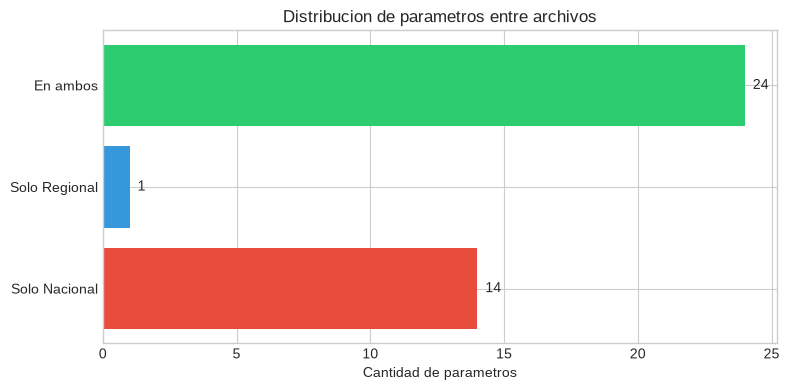

Excel exportado: /home/jchavez/Documentos/UPME/Datos Simulacion/output/01_comparacion_parametros.xlsx


In [13]:
PARAM_DESCRIPCIONES = {
    "AccumulatedAnnualDemand": "Demanda acumulada anual por combustible",
    "AnnualEmissionLimit": "Limite anual de emisiones",
    "AnnualExogenousEmission": "Emisiones exogenas anuales",
    "AvailabilityFactor": "Factor de disponibilidad de tecnologia",
    "CapacityFactor": "Factor de capacidad por timeslice",
    "CapacityOfOneTechnologyUnit": "Capacidad de una unidad tecnologica",
    "CapacityToActivityUnit": "Factor de conversion capacidad-actividad",
    "CapitalCost": "Costo de capital ($/kW)",
    "DepreciationMethod": "Metodo de depreciacion",
    "DiscountRate": "Tasa de descuento global",
    "DiscountRateIdv": "Tasa de descuento por tecnologia (solo regional)",
    "EmissionActivityRatio": "Ratio de emision por actividad",
    "EmissionsPenalty": "Penalizacion por emisiones",
    "FixedCost": "Costo fijo anual",
    "InputActivityRatio": "Ratio de entrada (combustible -> tecnologia)",
    "ModelPeriodEmissionLimit": "Limite de emision del periodo del modelo",
    "ModelPeriodExogenousEmission": "Emision exogena del periodo del modelo",
    "OperationalLife": "Vida operativa de la tecnologia (anos)",
    "OutputActivityRatio": "Ratio de salida (tecnologia -> producto)",
    "REMinProductionTarget": "Meta minima de produccion renovable",
    "RETagFuel": "Etiqueta de combustible renovable",
    "RETagTechnology": "Etiqueta de tecnologia renovable",
    "ReserveMargin": "Margen de reserva del sistema",
    "ReserveMarginTagFuel": "Etiqueta de combustible para margen de reserva",
    "ReserveMarginTagTechnology": "Etiqueta de tecnologia para margen de reserva",
    "ResidualCapacity": "Capacidad residual instalada (MW)",
    "SpecifiedAnnualDemand": "Demanda anual especificada",
    "SpecifiedDemandProfile": "Perfil de demanda especificada",
    "TotalAnnualMaxCapacity": "Capacidad maxima anual total",
    "TotalAnnualMaxCapacityInvestment": "Limite maximo de inversion anual",
    "TotalAnnualMinCapacity": "Capacidad minima anual total",
    "TotalAnnualMinCapacityInvestment": "Limite minimo de inversion anual",
    "TotalTechnologyAnnualActivityLowerLimit": "Limite inferior de actividad anual",
    "TotalTechnologyAnnualActivityUpperLimit": "Limite superior de actividad anual",
    "TotalTechnologyModelPeriodActivityLowerLimit": "Limite inferior de actividad del periodo",
    "TotalTechnologyModelPeriodActivityUpperLimit": "Limite superior de actividad del periodo",
    "TradeRoute": "Ruta de comercio entre regiones",
    "VariableCost": "Costo variable ($/GWh)",
    "YearSplit": "Distribucion temporal del ano (timeslices)",
}

params_nac = set(df_nac["Parameter"].dropna().unique())
params_reg = set(df_reg["Parameter"].dropna().unique())
only_nac = sorted(params_nac - params_reg)
only_reg = sorted(params_reg - params_nac)
common = sorted(params_nac & params_reg)

def build_param_table(param_list, categoria, df_ref=None, col_count="Filas_Nacional"):
    rows = []
    for p in param_list:
        row = {"Categoria": categoria, "Parameter": p,
               "Descripcion": PARAM_DESCRIPCIONES.get(p, "Sin descripcion disponible")}
        if df_ref is not None:
            row[col_count] = int((df_ref["Parameter"] == p).sum())
        rows.append(row)
    return pd.DataFrame(rows)

df_solo_nac = build_param_table(only_nac, "Solo Nacional", df_nac)
df_solo_reg = build_param_table(only_reg, "Solo Regional", df_reg, "Filas_Regional")
df_comunes = pd.DataFrame([
    {"Parameter": p, "Descripcion": PARAM_DESCRIPCIONES.get(p, ""),
     "Filas_Nacional": int((df_nac["Parameter"] == p).sum()),
     "Filas_Regional": int((df_reg["Parameter"] == p).sum())}
    for p in common
])

display(Markdown(f"### Parametros solo en Nacional ({len(only_nac)})"))
display(Markdown("Estos parametros definen restricciones o datos que **no se modelan a nivel regional** (ej. margenes de reserva nacionales, rutas de comercio)."))
show_df(df_solo_nac)

display(Markdown(f"### Parametros solo en Regional ({len(only_reg)})"))
show_df(df_solo_reg)

display(Markdown(f"### Parametros en ambos archivos ({len(common)})"))
show_df(df_comunes.sort_values("Filas_Nacional", ascending=False))

# Grafica
fig, ax = plt.subplots(figsize=(8, 4))
cats = ["Solo Nacional", "Solo Regional", "En ambos"]
vals = [len(only_nac), len(only_reg), len(common)]
colors = ["#e74c3c", "#3498db", "#2ecc71"]
bars = ax.barh(cats, vals, color=colors)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(v), va="center")
ax.set_xlabel("Cantidad de parametros")
ax.set_title("Distribucion de parametros entre archivos")
plt.tight_layout()
plt.show()

# Exportar Excel
output_file = OUTPUT_DIR / "01_comparacion_parametros.xlsx"
with pd.ExcelWriter(output_file, engine="openpyxl") as w:
    pd.DataFrame([{"Metrica": "Solo Nacional", "Cantidad": len(only_nac)},
                  {"Metrica": "Solo Regional", "Cantidad": len(only_reg)},
                  {"Metrica": "En ambos", "Cantidad": len(common)}]).to_excel(w, sheet_name="Resumen", index=False)
    pd.concat([df_solo_nac, df_solo_reg, df_comunes.assign(Categoria="En ambos")]).to_excel(w, sheet_name="Detalle", index=False)
print(f"Excel exportado: {output_file}")


---
## 3. Comparacion de TECHNOLOGY y FUEL

### Convencion de nombres regionales

En el archivo **Regional**, las tecnologias y combustibles llevan un prefijo de 2 letras que indica la region:

| Prefijo | Region | Ejemplo TECHNOLOGY | Ejemplo FUEL |
|---------|--------|--------------------|--------------|
| `AN_` | Andina | `AN_PWRCOA` | `AN_AGFELC` |
| `CA_` | Caribe | `CA_PWRBGS` | `CA_INDCLIM` |
| `IN_` | Interconectada | `IN_PWRSTD` | `IN_TERDHT` |
| `NE_` | Nororiental | `NE_PWRCOA` | `NE_RESCLIM_RUR` |
| `OR_` | Orinoquia | `OR_PWRAFR` | `OR_TRAAVI` |
| `SE_` | Santanderes | `SE_PWRSTD` | `SE_TERMPW` |
| `SO_` | Suroccidente | `SO_PWRDSL` | `SO_INDDHT` |

**Excepciones:**
- Tecnologias `TRN*` (comercio/transporte entre regiones): `TRNELC_AN_NE`, `TRNOIL_SO_AN_1LIV`
- Algunos FUEL sin prefijo: `FOL`, `URN`, `BDL001`


### Resumen TECHNOLOGY

Dimension,Total_Nacional,Total_Regional_Raw,Total_Regional_Base,Solo_Nacional,Solo_Regional_Base,Solo_Regional_SinPrefijo,Solo_Regional_TRN,En_Ambos
TECHNOLOGY,394,2347,481,28,115,0,34,366


**Solo en Nacional (28):** tecnologias del modelo agregado que no tienen equivalente regional desagregado (ej. `BACKSTOP_1`, plantas de generacion nacional `MINCSP`).

Categoria,Variable,Regiones,Num_Regiones
Solo Nacional,BACKSTOP_1,,0
Solo Nacional,BACKSTOP_2,,0
Solo Nacional,BBGDST,,0
Solo Nacional,DEMRESZNIBGSCKN_MID,,0
Solo Nacional,DEMRESZNIELCCKN_LOW,,0
Solo Nacional,DEMRESZNIELC_LOW,,0
Solo Nacional,DEMRESZNILPGCKN_MID,,0
Solo Nacional,DEMRESZNIWOOCKN_LOW,,0
Solo Nacional,EXPOIL,,0
Solo Nacional,GRDCOADST,,0


**Solo en Regional - bases nuevas (115):** tecnologias desagregadas por region que no existen en el nacional (ej. `BACKSTOP_AGFELC`, `PWRSTD`).

...

Categoria,Variable,Regiones,Num_Regiones
Solo Regional (base),BDL002,"AN, CA, NE, OR, SO",5
Solo Regional (base),BET002,"AN, CA, NE, OR, SO",5
Solo Regional (base),COA001,"AN, NE, OR, SO",4
Solo Regional (base),DSL003,"AN, CA, NE, OR, SO",5
Solo Regional (base),ELC001,"AN, CA, NE, OR, SO",5
Solo Regional (base),ELCEV001,"AN, CA, IN, NE, OR, SE, SO",7
Solo Regional (base),ELCEV002,"AN, CA, IN, NE, OR, SE, SO",7
Solo Regional (base),GSL003,"AN, CA, NE, OR, SO",5
Solo Regional (base),HDG001,"AN, CA, NE, OR, SO",5
Solo Regional (base),JET002,"AN, CA, IN, NE, OR, SE, SO",7


### Cobertura regional de variables

Muestra cuantas de las 7 regiones tiene cada variable base. `Cubre_Todas=True` significa que aparece en las 7 regiones.

**TECHNOLOGY con cobertura incompleta (top 15)**

Variable_Base,Regiones,Num_Regiones,Cubre_Todas
TRNOIL_AN_CA_3PES,SIN_PREFIJO,1,False
TRNOIL_NE_AN_3PES,SIN_PREFIJO,1,False
TRNOIL_NE_AN_2MED,SIN_PREFIJO,1,False
TRNOIL_NE_AN_1LIV,SIN_PREFIJO,1,False
TRNOIL_NE_CA_1LIV,SIN_PREFIJO,1,False
TRNOIL_OR_NE_1LIV,SIN_PREFIJO,1,False
TRNOIL_NE_CA_3PES,SIN_PREFIJO,1,False
TRNOIL_NE_CA_2MED,SIN_PREFIJO,1,False
TRNOIL_OR_NE_3PES,SIN_PREFIJO,1,False
TRNOIL_SO_AN_1LIV,SIN_PREFIJO,1,False


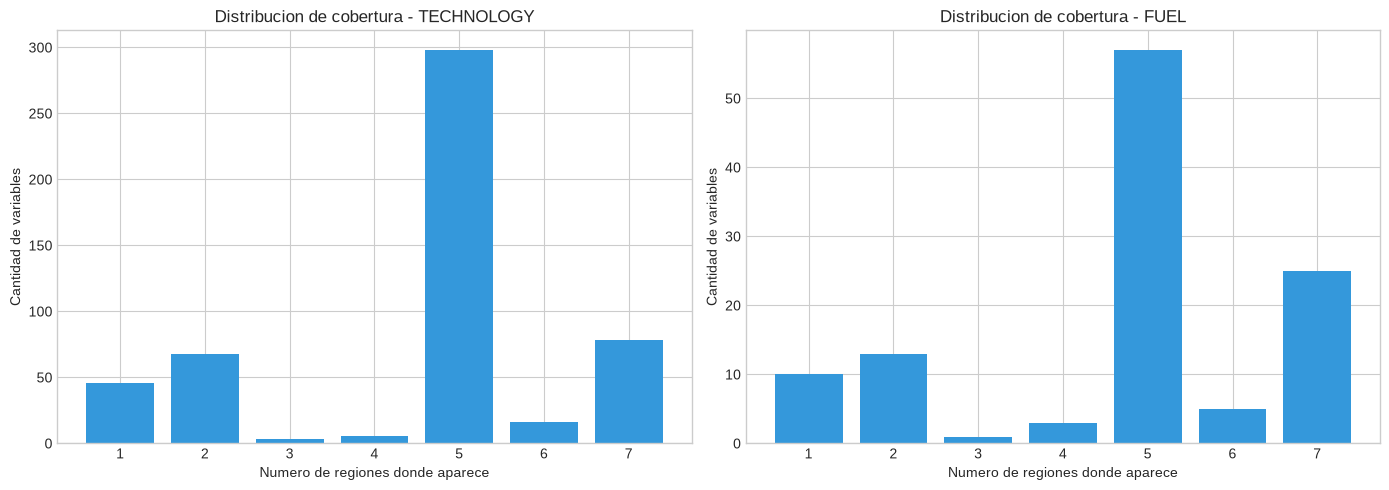

Excel exportado: /home/jchavez/Documentos/UPME/Datos Simulacion/output/02_comparacion_variables.xlsx


In [14]:
def compare_dimension(df_nac, df_reg, dimension):
    nac_values = {normalize_text(v) for v in df_nac[dimension].dropna().unique()}
    reg_raw = {normalize_text(v) for v in df_reg[dimension].dropna().unique()}
    reg_base, reg_trade, reg_no_prefix = set(), set(), set()
    for value in reg_raw:
        if dimension == "TECHNOLOGY" and is_trade_technology(value):
            reg_trade.add(value)
            continue
        region, base = split_regional_name(value)
        if region:
            reg_base.add(base)
        else:
            reg_no_prefix.add(base)
    reg_all = reg_base | reg_no_prefix
    only_nac = sorted(nac_values - reg_all)
    only_reg_base = sorted(reg_base - nac_values)
    only_reg_no_prefix = sorted(reg_no_prefix - nac_values)
    only_reg_trade = sorted(reg_trade)
    common = sorted(nac_values & reg_all)

    presence = defaultdict(set)
    for value in df_reg[dimension].dropna().unique():
        region, base = split_regional_name(value)
        if base is None:
            continue
        presence[base].add(region if region else "SIN_PREFIJO")

    def make_detail(items, cat):
        return pd.DataFrame([
            {"Categoria": cat, "Variable": item,
             "Regiones": ", ".join(sorted(presence.get(item, []))),
             "Num_Regiones": len(presence.get(item, []))}
            for item in items
        ])

    summary = pd.DataFrame([{
        "Dimension": dimension, "Total_Nacional": len(nac_values),
        "Total_Regional_Raw": len(reg_raw), "Total_Regional_Base": len(reg_base),
        "Solo_Nacional": len(only_nac), "Solo_Regional_Base": len(only_reg_base),
        "Solo_Regional_SinPrefijo": len(only_reg_no_prefix),
        "Solo_Regional_TRN": len(only_reg_trade), "En_Ambos": len(common),
    }])
    detail = pd.concat([
        make_detail(only_nac, f"Solo Nacional"),
        make_detail(only_reg_base, "Solo Regional (base)"),
        make_detail(only_reg_no_prefix, "Solo Regional (sin prefijo)"),
        make_detail(only_reg_trade, "Solo Regional (TRN)"),
        make_detail(common, "En ambos"),
    ], ignore_index=True)
    presence_df = pd.DataFrame([
        {"Variable_Base": b, "Regiones": ", ".join(sorted(r)),
         "Num_Regiones": len(r), "Cubre_Todas": len(r & set(REGIONES)) == len(REGIONES)}
        for b, r in sorted(presence.items())
    ])
    return summary, detail, presence_df

tech_sum, tech_det, tech_pres = compare_dimension(df_nac, df_reg, "TECHNOLOGY")
fuel_sum, fuel_det, fuel_pres = compare_dimension(df_nac, df_reg, "FUEL")

display(Markdown("### Resumen TECHNOLOGY"))
show_df(tech_sum)
display(Markdown(f"**Solo en Nacional ({tech_sum['Solo_Nacional'].iloc[0]}):** tecnologias del modelo agregado que no tienen equivalente regional desagregado (ej. `BACKSTOP_1`, plantas de generacion nacional `MINCSP`)."))
show_df(tech_det[tech_det["Categoria"] == "Solo Nacional"])
display(Markdown(f"**Solo en Regional - bases nuevas ({tech_sum['Solo_Regional_Base'].iloc[0]}):** tecnologias desagregadas por region que no existen en el nacional (ej. `BACKSTOP_AGFELC`, `PWRSTD`)."))
show_df(tech_det[tech_det["Categoria"] == "Solo Regional (base)"].head(20))
display(Markdown(f"**Solo en Regional - TRN ({tech_sum['Solo_Regional_TRN'].iloc[0]}):** rutas de comercio de energia/combustible entre regiones."))
show_df(tech_det[tech_det["Categoria"] == "Solo Regional (TRN)"])

display(Markdown("### Resumen FUEL"))
show_df(fuel_sum)
display(Markdown(f"**Solo en Nacional ({fuel_sum['Solo_Nacional'].iloc[0]}):** combustibles agregados sin desagregacion regional (ej. `COA`, `ELC`, `WND`)."))
show_df(fuel_det[fuel_det["Categoria"] == "Solo Nacional"])
display(Markdown(f"**Solo en Regional ({fuel_sum['Solo_Regional_Base'].iloc[0]} bases + {fuel_sum['Solo_Regional_SinPrefijo'].iloc[0]} sin prefijo):** incluye renombramientos como `ELC001`, `DSL003`, y categorias nuevas como `OTHDSL`."))
show_df(fuel_det[fuel_det["Categoria"].str.contains("Solo Regional")].head(20))

# Cobertura regional
display(Markdown("### Cobertura regional de variables"))
display(Markdown("Muestra cuantas de las 7 regiones tiene cada variable base. `Cubre_Todas=True` significa que aparece en las 7 regiones."))
incompletas_tech = tech_pres[~tech_pres["Cubre_Todas"]].sort_values("Num_Regiones")
show_df(incompletas_tech.head(15), "TECHNOLOGY con cobertura incompleta (top 15)")

# Grafica distribucion de regiones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pres, title in zip(axes, [tech_pres, fuel_pres], ["TECHNOLOGY", "FUEL"]):
    counts = pres["Num_Regiones"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="#3498db")
    ax.set_xlabel("Numero de regiones donde aparece")
    ax.set_ylabel("Cantidad de variables")
    ax.set_title(f"Distribucion de cobertura - {title}")
plt.tight_layout()
plt.show()

output_file = OUTPUT_DIR / "02_comparacion_variables.xlsx"
with pd.ExcelWriter(output_file, engine="openpyxl") as w:
    pd.concat([tech_sum, fuel_sum]).to_excel(w, sheet_name="Resumen", index=False)
    tech_det.to_excel(w, sheet_name="TECHNOLOGY_Detalle", index=False)
    fuel_det.to_excel(w, sheet_name="FUEL_Detalle", index=False)
    tech_pres.to_excel(w, sheet_name="TECHNOLOGY_Presencia", index=False)
    fuel_pres.to_excel(w, sheet_name="FUEL_Presencia", index=False)
print(f"Excel exportado: {output_file}")


---
## 4. Validacion de Sumas: Regional vs Nacional

### Que significa "aditivo" y "no aditivo"?

Estos terminos describen **como debe relacionarse el valor nacional con los valores regionales**.

#### Aditivo (se suman)

El valor **nacional deberia ser la suma** de los valores de las 7 regiones. Tiene sentido cuando el parametro representa un **total** que se reparte entre regiones.

**Ejemplo: `ResidualCapacity` para `DEMAGFDSL` (ano 2022)**

| Fuente | Valor (MW) |
|--------|------------|
| Nacional | 21.39 |
| AN + CA + IN + NE + OR + SE + SO | 3.05 + 2.78 + 0.01 + 4.27 + 3.93 + 0.12 + 7.24 = **21.39** |

La capacidad total del pais es la suma de las capacidades por region. Si la suma regional no coincide con el nacional, hay una **discrepancia aditiva**.

Parametros que suelen ser aditivos: `ResidualCapacity`, `AccumulatedAnnualDemand`, limites de actividad cuando representan totales.

#### No aditivo (deben ser iguales)

El valor **no se suma**: cada region deberia tener **el mismo valor** que el nacional. Son parametros **unitarios o de configuracion** que se replican en cada region.

**Ejemplo: `CapitalCost` para `PWRCOA`**

| Fuente | Valor ($/kW) |
|--------|--------------|
| Nacional | 57.1 |
| AN_PWRCOA, CA_PWRCOA, NE_PWRCOA, ... | 57.1 en cada una |

No tiene sentido sumar 57.1 + 57.1 + ... El costo de capital por kW es el **mismo parametro** en cada region. Si una region tiene un valor distinto al nacional, hay una **discrepancia no aditiva**.

Parametros que suelen ser no aditivos: `CapitalCost`, `FixedCost`, `VariableCost`, `AvailabilityFactor`, `CapacityFactor`, `InputActivityRatio`, `OutputActivityRatio`, `OperationalLife`.

#### Resumen rapido

| Tipo | Pregunta que responde | Regla de validacion |
|------|----------------------|---------------------|
| **Aditivo** | El nacional es un total? | `suma(regiones) = valor_nacional` |
| **No aditivo** | El nacional es un parametro comun? | `cada_region = valor_nacional` |

### Logica de validacion (como lo hace el codigo)

1. Emparejamos filas del nacional con sus equivalentes regionales (quitando el prefijo `AN_`, `CA_`, etc.).
2. Para cada par emparejado y cada ano (2022-2055), el script **detecta automaticamente** el tipo:
   - Si los valores regionales son **distintos entre si** -> valida como **aditivo** (compara la suma).
   - Si los valores regionales son **iguales entre si** -> valida como **no aditivo** (compara uno a uno con el nacional).

**Tolerancia:** diferencia absoluta < 0.01

**Nota:** Muchas discrepancias provienen de renombramientos (ej. `ELC` nacional -> `ELC001` regional) que impiden el emparejamiento automatico.


### Resumen por parametro


- **Tipo_Predominante**: si el parametro se comporta mas como aditivo (sumas) o no aditivo (igualdad).
- **Discrepancias_Aditivas**: casos donde `suma(regiones) != valor_nacional`.
- **Discrepancias_No_Aditivas**: casos donde `valor_region != valor_nacional` en al menos una region.
- **Pct_Coincidencia**: porcentaje de comparaciones (por ano) donde regional y nacional coinciden.


Parameter,Tipo_Predominante,Claves_Emparejadas,Claves_Solo_Nacional,Claves_Solo_Regional,Coincidencias,Discrepancias_Aditivas,Discrepancias_No_Aditivas,Pct_Coincidencia
ResidualCapacity,no_aditivo,286,107,32,25600,2889,5106,76.200000
AccumulatedAnnualDemand,aditivo,44,61,7,679,817,0,45.400000
FixedCost,no_aditivo,310,83,35,49266,227,2817,94.200000
TotalTechnologyAnnualActivityLowerLimit,no_aditivo,52,341,0,2604,214,1082,66.800000
CapitalCost,no_aditivo,349,44,101,49313,197,8556,84.900000
AnnualEmissionLimit,aditivo,2,11,1,0,68,0,0.000000
VariableCost,no_aditivo,353,40,464,57714,44,2116,96.400000
TotalTechnologyAnnualActivityUpperLimit,aditivo,3,390,0,330,34,10,88.200000
TotalTechnologyModelPeriodActivityUpperLimit,no_aditivo,366,27,115,0,12,1812,0.000000
EmissionActivityRatio,no_aditivo,260,4810,122,39937,6,1197,97.100000


### Top 15 discrepancias ADITIVAS (suma regional != nacional)

Parameter,TECHNOLOGY,FUEL,Columna_Valor,Valor_Nacional,Suma_Regional,Diferencia
ModelPeriodEmissionLimit,nan,nan,Time indipendent variables,9999999999999989514240.000000,99999999.000000,-9999999999999888850944.000000
ModelPeriodEmissionLimit,nan,nan,Time indipendent variables,9999999999999989514240.000000,99999999.000000,-9999999999999888850944.000000
AnnualEmissionLimit,nan,nan,2022,99999999999999904.000000,99999999.000000,-99999999899999904.000000
AnnualEmissionLimit,nan,nan,2023,99999999999999904.000000,99999999.000000,-99999999899999904.000000
AnnualEmissionLimit,nan,nan,2024,99999999999999904.000000,99999999.000000,-99999999899999904.000000
AnnualEmissionLimit,nan,nan,2025,99999999999999904.000000,99999999.000000,-99999999899999904.000000
AnnualEmissionLimit,nan,nan,2026,99999999999999904.000000,99999999.000000,-99999999899999904.000000
AnnualEmissionLimit,nan,nan,2027,99999999999999904.000000,99999999.000000,-99999999899999904.000000
AnnualEmissionLimit,nan,nan,2028,99999999999999904.000000,99999999.000000,-99999999899999904.000000
AnnualEmissionLimit,nan,nan,2029,99999999999999904.000000,99999999.000000,-99999999899999904.000000


...

- **55413 claves** del nacional sin equivalente regional

- **1678 claves** del regional sin equivalente nacional

Causas comunes: renombramiento de FUEL (`ELC`->`ELC001`), tecnologias nuevas en regional (`BACKSTOP_*`), o estructura distinta (`CapacityFactor` tiene 37,728 filas nacional vs 46 regional).

**Parametros con mas claves sin emparejar (nacional)**

Parameter,Claves_Sin_Emparejo
CapacityFactor,37728
OutputActivityRatio,10554
EmissionActivityRatio,4810
TotalAnnualMaxCapacityInvestment,391
TotalTechnologyAnnualActivityUpperLimit,390
AvailabilityFactor,381
TotalTechnologyAnnualActivityLowerLimit,341
InputActivityRatio,235
ResidualCapacity,107
YearSplit,96


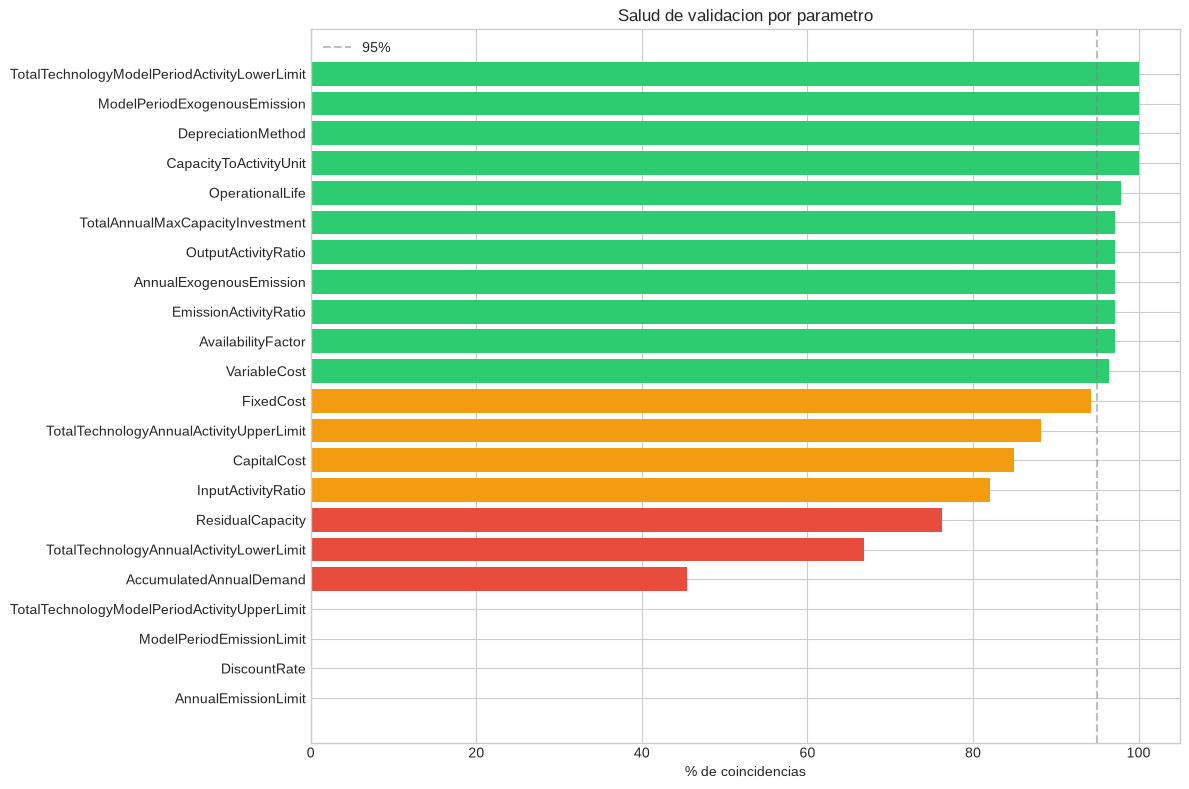

Excel exportado: /home/jchavez/Documentos/UPME/Datos Simulacion/output/03_validacion_sumas.xlsx


In [15]:
def get_row_region(row):
    region = row.get("TECH_REGION") or row.get("FUEL_REGION")
    normalized = normalize_text(region)
    return normalized if normalized else "SIN_REGION"

def prepare_nacional(df):
    out = df.copy()
    out["TECH_BASE"] = out["TECHNOLOGY"].apply(normalize_text)
    out["FUEL_BASE"] = out["FUEL"].apply(normalize_text)
    out["MATCH_KEY"] = out.apply(build_match_key, axis=1)
    return out

def prepare_regional(df):
    out = add_base_columns(df)
    out["IS_TRN"] = out["TECHNOLOGY"].apply(is_trade_technology)
    out["MATCH_KEY"] = out.apply(build_match_key, axis=1)
    return out

def aggregate_regional(rows, value_cols):
    by_region = defaultdict(lambda: {c: 0.0 for c in value_cols})
    has_val = defaultdict(lambda: {c: False for c in value_cols})
    for _, row in rows.iterrows():
        region = get_row_region(row)
        for col in value_cols:
            val = safe_float(row[col])
            if val is None:
                continue
            by_region[region][col] += val
            has_val[region][col] = True
    return {r: {c: (by_region[r][c] if has_val[r][c] else None) for c in value_cols} for r in by_region}

def detect_behavior(values):
    valid = [v for v in values if v is not None and not np.isnan(v)]
    if len(valid) <= 1:
        return "sin_comparacion"
    if all(values_close(valid[0], v) for v in valid[1:]):
        return "no_aditivo"
    return "aditivo"

def validate_key(nac_row, reg_rows, value_cols):
    summary = {"coincidencias": 0, "discrepancias_aditivas": 0, "discrepancias_no_aditivas": 0}
    additive, non_additive = [], []
    regional_by_region = aggregate_regional(reg_rows, value_cols)
    match_key = nac_row["MATCH_KEY"]

    for col in value_cols:
        nac_val = safe_float(nac_row[col])
        regional_vals = {r: v[col] for r, v in regional_by_region.items()}
        valid_regional = [v for v in regional_vals.values() if v is not None and not np.isnan(v)]
        if nac_val is None and not valid_regional:
            continue
        if not valid_regional:
            continue
        behavior = detect_behavior(list(regional_vals.values()))
        base = {"Parameter": match_key[0], "TECHNOLOGY": match_key[1], "FUEL": match_key[4],
                "Columna_Valor": col, "Valor_Nacional": nac_val, "Match_Key": format_key(match_key)}

        if behavior == "no_aditivo":
            for region, reg_val in regional_vals.items():
                if reg_val is None:
                    continue
                if values_close(nac_val, reg_val):
                    summary["coincidencias"] += 1
                else:
                    summary["discrepancias_no_aditivas"] += 1
                    non_additive.append({**base, "Tipo": "no_aditivo", "Region": region,
                                         "Valor_Regional": reg_val, "Suma_Regional": None,
                                         "Diferencia": reg_val - nac_val if nac_val is not None else None})
        else:
            reg_sum = float(np.nansum(valid_regional))
            if values_close(nac_val, reg_sum):
                summary["coincidencias"] += 1
            else:
                summary["discrepancias_aditivas"] += 1
                additive.append({**base, "Tipo": "aditivo",
                                 "Region": ", ".join(sorted(regional_vals.keys())),
                                 "Valor_Regional": None, "Suma_Regional": reg_sum,
                                 "Diferencia": reg_sum - nac_val if nac_val is not None else None})
    return additive, non_additive, summary

# Ejecutar validacion
df_nac_prep = prepare_nacional(df_nac)
df_reg_prep = prepare_regional(df_reg)
value_cols = get_value_cols(df_nac)
common_params = sorted(set(df_nac_prep["Parameter"].dropna().unique()) & set(df_reg_prep["Parameter"].dropna().unique()))
df_nac_f = df_nac_prep[df_nac_prep["Parameter"].isin(common_params)]
df_reg_f = df_reg_prep[df_reg_prep["Parameter"].isin(common_params) & ~df_reg_prep["IS_TRN"]]

nac_by_key = {k: g for k, g in df_nac_f.groupby("MATCH_KEY", dropna=False)}
reg_by_key = {k: g for k, g in df_reg_f.groupby("MATCH_KEY", dropna=False)}

all_add, all_nonadd = [], []
unmatched_nac, unmatched_reg = [], []
param_stats = defaultdict(lambda: {"emparejadas": 0, "solo_nac": 0, "solo_reg": 0,
                                    "coincidencias": 0, "disc_adit": 0, "disc_no_adit": 0})

for key, nac_group in nac_by_key.items():
    param = key[0]
    if key not in reg_by_key:
        param_stats[param]["solo_nac"] += 1
        unmatched_nac.append({"Parameter": key[0], "TECHNOLOGY": key[1], "FUEL": key[4], "Match_Key": format_key(key)})
        continue
    if len(nac_group) != 1:
        unmatched_nac.append({"Parameter": key[0], "TECHNOLOGY": key[1], "FUEL": key[4],
                               "Match_Key": format_key(key), "Nota": "Clave duplicada"})
        continue
    param_stats[param]["emparejadas"] += 1
    add, nonadd, summ = validate_key(nac_group.iloc[0], reg_by_key[key], value_cols)
    all_add.extend(add)
    all_nonadd.extend(nonadd)
    for m in ("coincidencias", "disc_adit", "disc_no_adit"):
        param_stats[param][m] += summ[{"coincidencias": "coincidencias", "disc_adit": "discrepancias_aditivas",
                                        "disc_no_adit": "discrepancias_no_aditivas"}[m]]

for key, reg_group in reg_by_key.items():
    if key not in nac_by_key:
        param_stats[key[0]]["solo_reg"] += 1
        unmatched_reg.append({"Parameter": key[0], "TECHNOLOGY": key[1], "FUEL": key[4], "Match_Key": format_key(key)})

resumen_rows = []
for param in common_params:
    s = param_stats[param]
    da, dna = s["disc_adit"], s["disc_no_adit"]
    tipo = "aditivo" if da > dna else ("no_aditivo" if dna > da else ("sin_discrepancias" if da == 0 else "mixto"))
    total_checks = s["coincidencias"] + da + dna
    pct_ok = round(100 * s["coincidencias"] / total_checks, 1) if total_checks > 0 else 100.0
    resumen_rows.append({
        "Parameter": param, "Tipo_Predominante": tipo,
        "Claves_Emparejadas": s["emparejadas"], "Claves_Solo_Nacional": s["solo_nac"],
        "Claves_Solo_Regional": s["solo_reg"], "Coincidencias": s["coincidencias"],
        "Discrepancias_Aditivas": da, "Discrepancias_No_Aditivas": dna,
        "Pct_Coincidencia": pct_ok,
    })

df_resumen = pd.DataFrame(resumen_rows).sort_values("Discrepancias_Aditivas", ascending=False)
df_disc_adit = pd.DataFrame(all_add)
df_disc_no_adit = pd.DataFrame(all_nonadd)
df_unmatched_nac = pd.DataFrame(unmatched_nac)
df_unmatched_reg = pd.DataFrame(unmatched_reg)

display(Markdown("### Resumen por parametro"))
display(Markdown("""
- **Tipo_Predominante**: si el parametro se comporta mas como aditivo (sumas) o no aditivo (igualdad).
- **Discrepancias_Aditivas**: casos donde `suma(regiones) != valor_nacional`.
- **Discrepancias_No_Aditivas**: casos donde `valor_region != valor_nacional` en al menos una region.
- **Pct_Coincidencia**: porcentaje de comparaciones (por ano) donde regional y nacional coinciden.
"""))
show_df(df_resumen, max_rows=30)

# Top discrepancias
if not df_disc_adit.empty:
    df_disc_adit["Abs_Diferencia"] = df_disc_adit["Diferencia"].abs()
    display(Markdown("### Top 15 discrepancias ADITIVAS (suma regional != nacional)"))
    show_df(df_disc_adit.nlargest(15, "Abs_Diferencia")[["Parameter","TECHNOLOGY","FUEL","Columna_Valor","Valor_Nacional","Suma_Regional","Diferencia"]])

if not df_disc_no_adit.empty:
    df_disc_no_adit["Abs_Diferencia"] = df_disc_no_adit["Diferencia"].abs()
    display(Markdown("### Top 15 discrepancias NO ADITIVAS (valor regional != nacional)"))
    show_df(df_disc_no_adit.nlargest(15, "Abs_Diferencia")[["Parameter","TECHNOLOGY","FUEL","Region","Columna_Valor","Valor_Nacional","Valor_Regional","Diferencia"]])

display(Markdown(f"### Claves sin emparejamiento"))
display(Markdown(f"- **{len(df_unmatched_nac)} claves** del nacional sin equivalente regional"))
display(Markdown(f"- **{len(df_unmatched_reg)} claves** del regional sin equivalente nacional"))
display(Markdown("Causas comunes: renombramiento de FUEL (`ELC`->`ELC001`), tecnologias nuevas en regional (`BACKSTOP_*`), o estructura distinta (`CapacityFactor` tiene 37,728 filas nacional vs 46 regional)."))

if not df_unmatched_nac.empty:
    causa = df_unmatched_nac.groupby("Parameter").size().reset_index(name="Claves_Sin_Emparejo").sort_values("Claves_Sin_Emparejo", ascending=False)
    show_df(causa.head(10), "Parametros con mas claves sin emparejar (nacional)")

# Grafica salud por parametro
fig, ax = plt.subplots(figsize=(12, 8))
df_plot = df_resumen[df_resumen["Coincidencias"] + df_resumen["Discrepancias_Aditivas"] + df_resumen["Discrepancias_No_Aditivas"] > 0].copy()
df_plot = df_plot.sort_values("Pct_Coincidencia")
colors = df_plot["Pct_Coincidencia"].apply(lambda x: "#2ecc71" if x >= 95 else ("#f39c12" if x >= 80 else "#e74c3c"))
ax.barh(df_plot["Parameter"], df_plot["Pct_Coincidencia"], color=colors)
ax.set_xlabel("% de coincidencias")
ax.set_title("Salud de validacion por parametro")
ax.axvline(95, color="gray", linestyle="--", alpha=0.5, label="95%")
ax.legend()
plt.tight_layout()
plt.show()

output_file = OUTPUT_DIR / "03_validacion_sumas.xlsx"
with pd.ExcelWriter(output_file, engine="openpyxl") as w:
    df_resumen.to_excel(w, sheet_name="Resumen", index=False)
    df_disc_adit.to_excel(w, sheet_name="Discrepancias_Aditivos", index=False)
    df_disc_no_adit.to_excel(w, sheet_name="Discrepancias_NoAditivos", index=False)
    df_unmatched_nac.to_excel(w, sheet_name="Sin_Emparejo_Nacional", index=False)
    df_unmatched_reg.to_excel(w, sheet_name="Sin_Emparejo_Regional", index=False)
print(f"Excel exportado: {output_file}")


---
## 5. Analisis del Sector Transporte (TRA*)

En el modelo OSeMOSYS, el sector transporte se identifica con el prefijo **TRA** en las variables FUEL y TECHNOLOGY.

### Modos de transporte (FUEL TRA*)

Cada FUEL `TRA*` representa un **modo de transporte** (demanda energetica del sector):

| Codigo | Modo | Descripcion |
|--------|------|-------------|
| `TRAAVI` | Aviacion | Transporte aereo |
| `TRABUS` | Buses | Transporte publico en bus |
| `TRAFWD` | 4x4 / FWD | Vehiculos todo terreno |
| `TRALDV` | Vehiculos livianos | Automoviles particulares |
| `TRAMIC` | Motocicletas | Transporte en moto |
| `TRAMRT` | Metro / MRT | Transporte masivo (metro) |
| `TRAMTC` | MTC | Transporte colectivo urbano |
| `TRAMET` | Metro (electrico) | Metro electrico |
| `TRARVT` | Tren ligero / RVT | Transporte ferroviario ligero |
| `TRASTT` | Barcos / STT | Transporte maritimo/fluvial |
| `TRATAX` | Taxis | Transporte en taxi |
| `TRATCK` | Camiones / TCK | Transporte de carga pesada |
| `TRAMAS` | MAS | Transporte masivo adicional |

### Tecnologias de transporte (TECHNOLOGY DEMTRA*)

Las tecnologias siguen el patron `DEMTRA{combustible}{modo}`:

| Combustible | Descripcion |
|-------------|-------------|
| `DSL` | Diesel |
| `ELC` | Electrico |
| `GSL` | Gasolina |
| `HDG` | Hidrogeno |
| `NGS` | Gas natural |
| `FOL` | Fuel oil |
| `JET` | Jet fuel (aviacion) |
| `HEV` | Hibrido electrico |
| `PHE` | Plug-in hibrido |

**Ejemplo:** `DEMTRADSLBUS_URB` = demanda de transporte en bus urbano con diesel.

En el archivo **Regional**, cada variable lleva prefijo de region: `AN_TRABUS`, `CA_TRAAVI`, etc.

### 5.1 Demanda acumulada anual por modo de transporte (Nacional)

FUEL,Modo,2022,2030,2040,2050
TRAAVI,Aviacion,64.000970,84.560470,107.179900,132.275900
TRASTT,Barcos/STT,32.073555,32.032268,38.353128,46.367410
TRATCK,Camiones,20.531511,21.063825,25.958030,30.269821
TRAFWD,4x4/FWD,18.240750,20.963867,33.484384,51.394939
TRABUS,Buses,17.840074,29.532860,55.452242,82.756552
TRALDV,Veh. livianos,17.334276,16.665624,18.325742,17.254150
TRAMTC,MTC,17.180138,18.240063,13.954260,9.261036
TRATAX,Taxis,10.663269,9.803110,9.893152,9.680693
TRAMRT,Metro/MRT,7.298877,9.549269,12.846560,17.242217
TRAMIC,Motocicletas,2.968527,3.396990,3.554275,5.462718


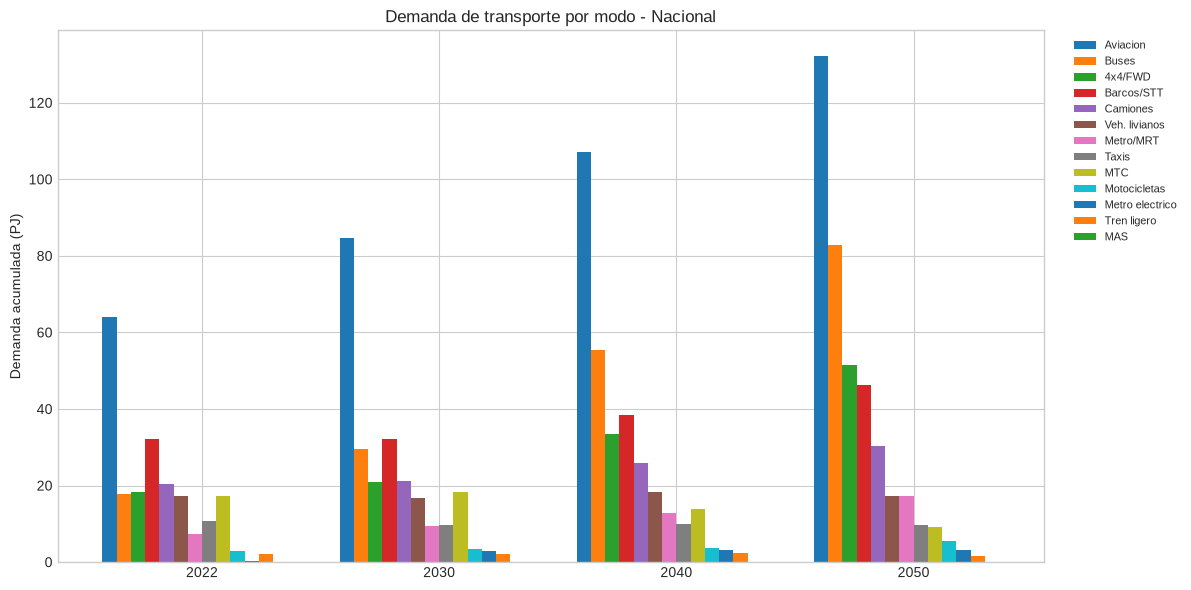

**Demanda total transporte:** 210.6 PJ (2022) -> 406.6 PJ (2050) | Crecimiento: 93.1%

In [16]:
# --- 5.1 Demanda por modo de transporte (Nacional) ---
MODOS_TRA = {
    "TRAAVI": "Aviacion", "TRABUS": "Buses", "TRAFWD": "4x4/FWD",
    "TRALDV": "Veh. livianos", "TRAMIC": "Motocicletas", "TRAMRT": "Metro/MRT",
    "TRAMTC": "MTC", "TRAMET": "Metro electrico", "TRARVT": "Tren ligero",
    "TRASTT": "Barcos/STT", "TRATAX": "Taxis", "TRATCK": "Camiones",
    "TRAMAS": "MAS",
}

anos_demanda = ["2022", "2030", "2040", "2050"]

nac_aad_tra = df_nac[
    (df_nac["Parameter"] == "AccumulatedAnnualDemand")
    & (df_nac["FUEL"].str.contains("TRA", na=False))
].copy()

nac_aad_tra["Modo"] = nac_aad_tra["FUEL"].map(MODOS_TRA).fillna(nac_aad_tra["FUEL"])
demanda_modo = nac_aad_tra[["FUEL", "Modo"] + anos_demanda].sort_values("2022", ascending=False)

display(Markdown("### 5.1 Demanda acumulada anual por modo de transporte (Nacional)"))
show_df(demanda_modo, max_rows=20)

# Grafica de evolucion temporal
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(anos_demanda))
width = 0.06
modos_ordenados = demanda_modo.sort_values("2050", ascending=False)["FUEL"].tolist()
for i, fuel in enumerate(modos_ordenados):
    row = demanda_modo[demanda_modo["FUEL"] == fuel].iloc[0]
    vals = [safe_float(row[a]) or 0 for a in anos_demanda]
    ax.bar(x + i * width, vals, width, label=MODOS_TRA.get(fuel, fuel))

ax.set_xticks(x + width * len(modos_ordenados) / 2)
ax.set_xticklabels(anos_demanda)
ax.set_ylabel("Demanda acumulada (PJ)")
ax.set_title("Demanda de transporte por modo - Nacional")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

total_2022 = demanda_modo["2022"].sum()
total_2050 = demanda_modo["2050"].sum()
display(Markdown(f"**Demanda total transporte:** {total_2022:.1f} PJ (2022) -> {total_2050:.1f} PJ (2050) | Crecimiento: {100*(total_2050/total_2022 - 1):.1f}%"))

### 5.2 Comparacion Nacional vs Regional - Sector Transporte

- Filas Nacional (TRA*): **10,461** | Filas Regional (TRA*): **5,546**

**FUEL TRA (modos):** 13 en ambos | 0 solo nacional | 0 solo regional

**Cobertura regional por modo de transporte**

Modo,Descripcion,Regiones,Num_Regiones,Cubre_Todas
TRAAVI,Aviacion,"AN, CA, IN, NE, OR, SE, SO",7,True
TRABUS,Buses,"AN, CA, NE, OR, SO",5,False
TRAFWD,4x4/FWD,"AN, CA, IN, NE, OR, SE, SO",7,True
TRALDV,Veh. livianos,"AN, CA, IN, NE, OR, SE, SO",7,True
TRAMAS,MAS,"AN, CA, NE, OR, SO",5,False
TRAMET,Metro electrico,"AN, OR, SO",3,False
TRAMIC,Motocicletas,"AN, CA, IN, NE, OR, SE, SO",7,True
TRAMRT,Metro/MRT,"AN, CA, IN, SO",4,False
TRAMTC,MTC,"AN, CA, IN, NE, OR, SE, SO",7,True
TRARVT,Tren ligero,"AN, CA, NE, OR, SE, SO",6,False


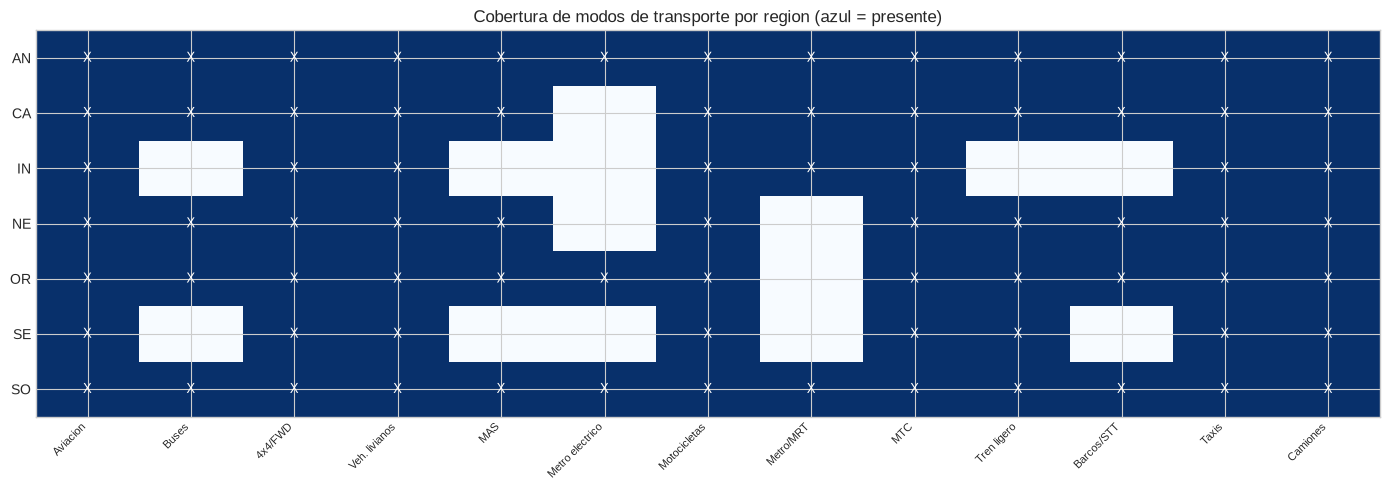

**Parametros con datos de transporte:**

Parameter,Filas_Nacional,Filas_Regional
CapacityFactor,6048,0
SpecifiedDemandProfile,1248,0
OutputActivityRatio,1083,448
EmissionActivityRatio,819,553
InputActivityRatio,66,392
OperationalLife,63,448
CapacityToActivityUnit,63,448
AvailabilityFactor,63,0
CapitalCost,63,439
FixedCost,63,313


In [17]:
# --- 5.2 Comparacion Nacional vs Regional (solo transporte TRA*) ---
def is_transport(row):
    tech = normalize_text(row.get("TECHNOLOGY")) or ""
    fuel = normalize_text(row.get("FUEL")) or ""
    return ("TRA" in tech) or ("TRA" in fuel)

mask_nac_tra = df_nac.apply(is_transport, axis=1).astype(bool)
mask_reg_tra = df_reg.apply(is_transport, axis=1).astype(bool)
nac_tra = df_nac[mask_nac_tra].copy()
reg_tra = df_reg[mask_reg_tra].copy()

display(Markdown("### 5.2 Comparacion Nacional vs Regional - Sector Transporte"))
display(Markdown(f"- Filas Nacional (TRA*): **{len(nac_tra):,}** | Filas Regional (TRA*): **{len(reg_tra):,}**"))

# Comparar FUEL TRA (modos)
nac_fuels_tra = {normalize_text(f) for f in nac_tra["FUEL"].dropna().unique() if "TRA" in str(f)}
reg_fuels_tra_raw = {normalize_text(f) for f in reg_tra["FUEL"].dropna().unique() if "TRA" in str(f)}
reg_fuels_base = set()
fuel_presence = defaultdict(set)
for f in reg_fuels_tra_raw:
    region, base = split_regional_name(f)
    if base:
        reg_fuels_base.add(base)
        if region:
            fuel_presence[base].add(region)

solo_nac_fuel = sorted(nac_fuels_tra - reg_fuels_base)
solo_reg_fuel = sorted(reg_fuels_base - nac_fuels_tra)
comunes_fuel = sorted(nac_fuels_tra & reg_fuels_base)

display(Markdown(f"**FUEL TRA (modos):** {len(comunes_fuel)} en ambos | {len(solo_nac_fuel)} solo nacional | {len(solo_reg_fuel)} solo regional"))

# Tabla de cobertura regional por modo
cobertura_rows = []
for modo in sorted(reg_fuels_base):
    regiones = sorted(fuel_presence.get(modo, []))
    cobertura_rows.append({
        "Modo": modo,
        "Descripcion": MODOS_TRA.get(modo, modo),
        "Regiones": ", ".join(regiones),
        "Num_Regiones": len(regiones),
        "Cubre_Todas": len(set(regiones) & set(REGIONES)) == len(REGIONES),
    })
df_cobertura = pd.DataFrame(cobertura_rows)
show_df(df_cobertura, "Cobertura regional por modo de transporte")

# Heatmap region x modo
modos_list = sorted(reg_fuels_base)
heatmap_data = pd.DataFrame(0, index=REGIONES, columns=modos_list)
for modo in modos_list:
    for reg in fuel_presence.get(modo, []):
        if reg in REGIONES:
            heatmap_data.loc[reg, modo] = 1

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(modos_list)))
ax.set_xticklabels([MODOS_TRA.get(m, m) for m in modos_list], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(REGIONES)))
ax.set_yticklabels(REGIONES)
ax.set_title("Cobertura de modos de transporte por region (azul = presente)")
for i in range(len(REGIONES)):
    for j in range(len(modos_list)):
        val = heatmap_data.iloc[i, j]
        ax.text(j, i, "X" if val else "", ha="center", va="center", color="white" if val else "gray", fontsize=9)
plt.tight_layout()
plt.show()

# Parametros del transporte
display(Markdown("**Parametros con datos de transporte:**"))
param_comp = pd.DataFrame({
    "Parameter": sorted(set(nac_tra["Parameter"].unique()) | set(reg_tra["Parameter"].unique())),
})
param_comp["Filas_Nacional"] = param_comp["Parameter"].apply(lambda p: int((nac_tra["Parameter"] == p).sum()))
param_comp["Filas_Regional"] = param_comp["Parameter"].apply(lambda p: int((reg_tra["Parameter"] == p).sum()))
show_df(param_comp.sort_values("Filas_Nacional", ascending=False), max_rows=15)

### 5.3 Analisis profundo: Regional vs Nacional (Transporte)

Validacion de **8 parametros** de transporte con emparejamiento por dimension correcta y reporte de variables sin equivalente en el otro archivo.

| Parametro | Dimension | Tipo |
|-----------|-----------|------|
| AccumulatedAnnualDemand | FUEL | aditivo |
| ResidualCapacity | TECHNOLOGY | aditivo |
| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |
| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |
| CapitalCost | TECHNOLOGY | no aditivo |
| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |
| InputActivityRatio | TECH+FUEL+MODE | no aditivo |
| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |

**Resultado global:** 7309 coincidencias | 749 discrepancias | 1275 variables sin emparejar | **90.7% coincidencia**

**Resumen por parametro:**

Parameter,Dimension,Tipo_Validacion,Coincidencias,Discrepancias,Sin_Emparejar,Pct_Coincidencia
AccumulatedAnnualDemand,FUEL,aditivo,264,76,3,77.600000
ResidualCapacity,TECHNOLOGY,aditivo,1948,194,1,90.900000
TotalAnnualMaxCapacityInvestment,TECHNOLOGY,aditivo,0,0,63,0.000000
TotalTechnologyAnnualActivityUpperLimit,TECHNOLOGY,aditivo,0,0,63,0.000000
CapitalCost,TECHNOLOGY,no_aditivo,1764,378,16,82.400000
TotalTechnologyModelPeriodActivityUpperLimit,TECHNOLOGY,no_aditivo,0,0,16,0.000000
InputActivityRatio,TECH+FUEL+MODE,no_aditivo,1254,38,77,97.100000
OutputActivityRatio,TECH+FUEL+MODE,no_aditivo,2079,63,1036,97.100000


...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2054,141.937700,98.738699,-43.199001,aditivo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2053,139.522200,98.738699,-40.783501,aditivo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2052,137.106800,98.738699,-38.368101,aditivo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2051,134.691300,98.738699,-35.952601,aditivo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2050,132.275900,98.738699,-33.537201,aditivo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2049,129.860500,99.188666,-30.671834,aditivo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2048,127.445000,97.262557,-30.182443,aditivo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2045,120.198700,93.939124,-26.259576,aditivo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2047,125.029600,98.870900,-26.158700,aditivo
AccumulatedAnnualDemand,TRAAVI,Aviacion,2046,122.614200,96.693724,-25.920476,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
TRALDV,Solo Nacional,FUEL
TRAMAS,Solo Nacional,FUEL
TRARVT,Solo Nacional,FUEL


**Comparacion 2050 (grafica):**

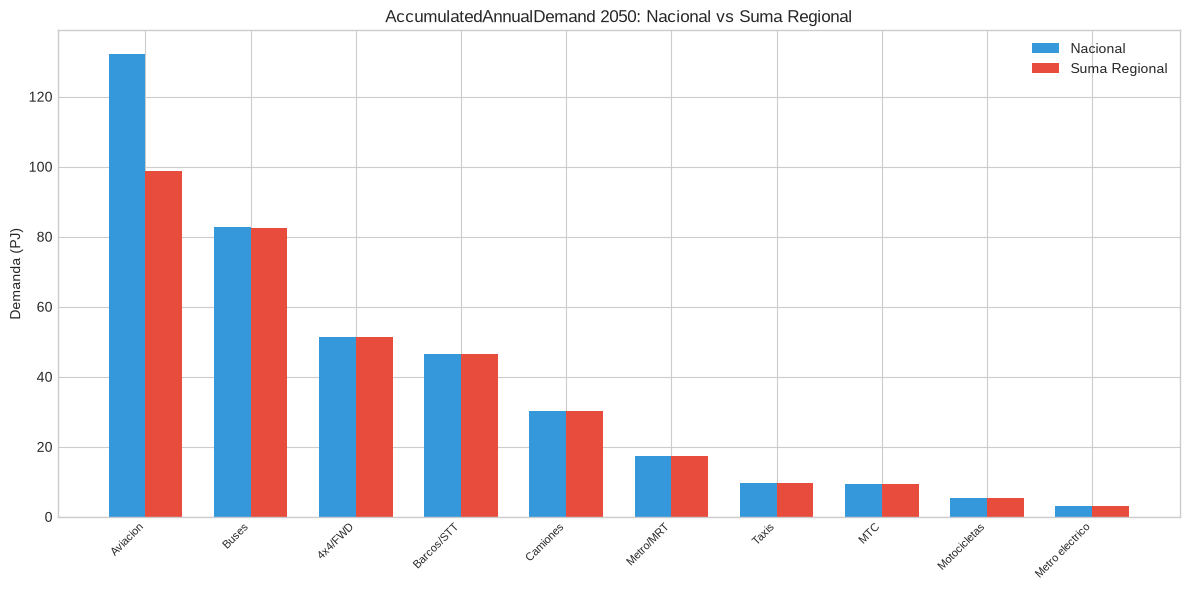

#### ResidualCapacity

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

1948 coincidencias | 194 discrepancias (63 modos/variables) | 1 sin emparejar | **90.9% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2022,17.174014,0.000000,-17.174014,aditivo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2023,16.358638,0.000000,-16.358638,aditivo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2024,15.167437,0.000000,-15.167437,aditivo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2025,15.105148,0.000000,-15.105148,aditivo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2026,14.978145,0.000000,-14.978145,aditivo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2027,14.700784,0.000000,-14.700784,aditivo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2028,14.176806,0.000000,-14.176806,aditivo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2029,13.296005,0.000000,-13.296005,aditivo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2030,11.963330,0.000000,-11.963330,aditivo
ResidualCapacity,DEMTRAGSLMOT,DEMTRAGSLMOT,2031,10.147966,0.000000,-10.147966,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMTRAGSLBUS_URB,Solo Regional,TECHNOLOGY


**Comparacion 2050 (grafica):**

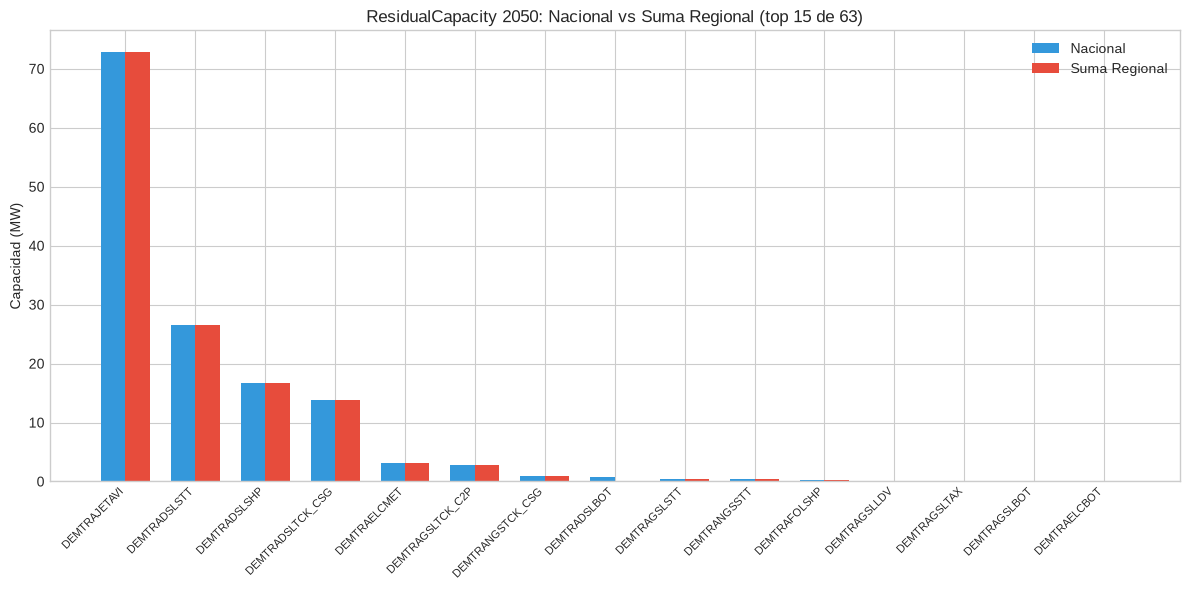

#### TotalAnnualMaxCapacityInvestment

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

0 coincidencias | 0 discrepancias (0 modos/variables) | 63 sin emparejar | **0% coincidencia**

_Sin discrepancias en comparaciones emparejadas._

**Variables sin emparejar:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2054,28721.539000,11522.836000,-17198.703000,no_aditivo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2053,27616.905000,11079.602000,-16537.303000,no_aditivo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2052,26554.560000,10653.532000,-15901.028000,no_aditivo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2051,25533.265000,10243.740000,-15289.525000,no_aditivo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2050,24551.250000,9849.872000,-14701.378000,no_aditivo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2049,23606.924000,9470.868000,-14136.056000,no_aditivo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2048,22699.047000,9106.726000,-13592.321000,no_aditivo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2047,21826.027000,8756.386000,-13069.641000,no_aditivo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2046,20986.449000,8419.670000,-12566.779000,no_aditivo
CapitalCost,DEMTRADSLLDV,DEMTRADSLLDV,2045,20179.427000,8095.870000,-12083.557000,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
BACKSTOP_TRAAVI,Solo Regional,TECHNOLOGY
BACKSTOP_TRABUS,Solo Regional,TECHNOLOGY
BACKSTOP_TRAFWD,Solo Regional,TECHNOLOGY
BACKSTOP_TRALDV,Solo Regional,TECHNOLOGY
BACKSTOP_TRAMAS,Solo Regional,TECHNOLOGY
BACKSTOP_TRAMET,Solo Regional,TECHNOLOGY
BACKSTOP_TRAMIC,Solo Regional,TECHNOLOGY
BACKSTOP_TRAMRT,Solo Regional,TECHNOLOGY
BACKSTOP_TRAMTC,Solo Regional,TECHNOLOGY
BACKSTOP_TRARVT,Solo Regional,TECHNOLOGY


**Comparacion 2050 (grafica):**

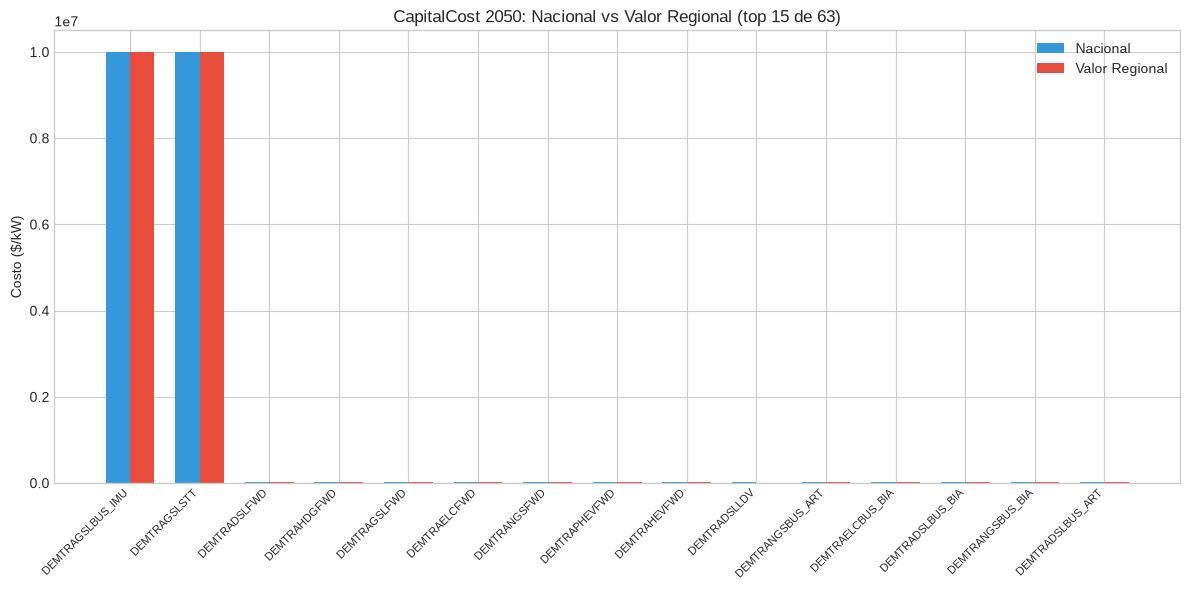

#### TotalTechnologyModelPeriodActivityUpperLimit

Dimension: **TECHNOLOGY** | Tipo: **no_aditivo**

0 coincidencias | 0 discrepancias (0 modos/variables) | 16 sin emparejar | **0% coincidencia**

_Sin discrepancias en comparaciones emparejadas._

**Variables sin emparejar:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
InputActivityRatio,DEMTRADSLFWD|DSL002|1.0,DEMTRADSLFWD,2055,nan,3.636000,nan,no_aditivo
InputActivityRatio,DEMTRADSLLDV|DSL002|1.0,DEMTRADSLLDV,2055,nan,3.636000,nan,no_aditivo
InputActivityRatio,DEMTRADSLMIC|DSL002|1.0,DEMTRADSLMIC,2055,nan,3.636000,nan,no_aditivo
InputActivityRatio,DEMTRADSLTAX|DSL002|1.0,DEMTRADSLTAX,2055,nan,3.636000,nan,no_aditivo
InputActivityRatio,DEMTRADSLTCK_C2P|DSL002|1.0,DEMTRADSLTCK_C2P,2055,nan,3.636000,nan,no_aditivo
InputActivityRatio,DEMTRADSLTCK_CSG|DSL002|1.0,DEMTRADSLTCK_CSG,2055,nan,3.636000,nan,no_aditivo
InputActivityRatio,DEMTRAELCMET|ELC002|1.0,DEMTRAELCMET,2055,nan,1.000000,nan,no_aditivo
InputActivityRatio,DEMTRAFOLSHP|FOL|1.0,DEMTRAFOLSHP,2055,nan,1.000000,nan,no_aditivo
InputActivityRatio,DEMTRAGSLBOT|GSL002|1.0,DEMTRAGSLBOT,2055,nan,1.000000,nan,no_aditivo
InputActivityRatio,DEMTRAGSLFWD|GSL002|1.0,DEMTRAGSLFWD,2055,nan,4.484000,nan,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMTRADSLBOT|DSL002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLBUS_ART|DSL002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLBUS_BIA|DSL002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLBUS_IMU|DSL002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLBUS_URB|DSL002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLSHP|DSL|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLSTT|DSL002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRAELCBOT|ELC003|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRAELCBUS_ART|ELC004|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRAELCBUS_BIA|ELC004|1.0,Solo Nacional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

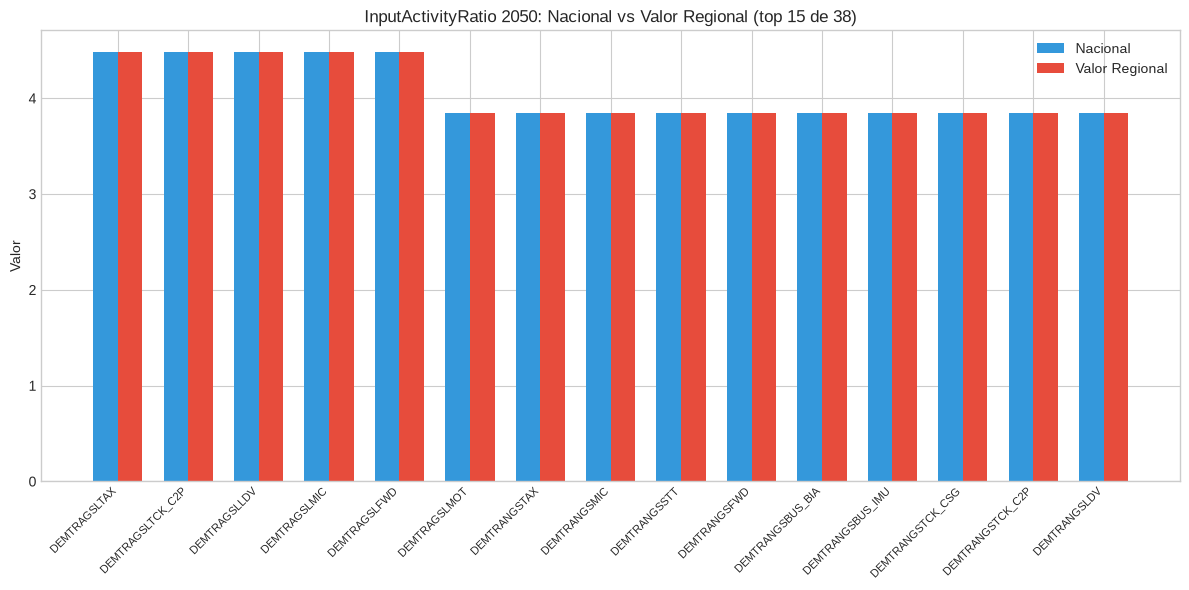

#### OutputActivityRatio

Dimension: **TECH+FUEL+MODE** | Tipo: **no_aditivo**

2079 coincidencias | 63 discrepancias (63 modos/variables) | 1036 sin emparejar | **97.1% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
OutputActivityRatio,DEMTRADSLBOT|TRARVT|1.0,DEMTRADSLBOT,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTRADSLBUS_ART|TRAMAS|1.0,DEMTRADSLBUS_ART,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTRADSLBUS_BIA|TRAMAS|1.0,DEMTRADSLBUS_BIA,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTRADSLBUS_IMU|TRABUS|1.0,DEMTRADSLBUS_IMU,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTRADSLBUS_URB|TRABUS|1.0,DEMTRADSLBUS_URB,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTRADSLFWD|TRAFWD|1.0,DEMTRADSLFWD,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTRADSLLDV|TRALDV|1.0,DEMTRADSLLDV,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTRADSLMIC|TRAMIC|1.0,DEMTRADSLMIC,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTRADSLSHP|TRAMRT|1.0,DEMTRADSLSHP,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTRADSLSTT|TRASTT|1.0,DEMTRADSLSTT,2055,nan,1.000000,nan,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMRESELCOTH_HIG_RUR|TRAMIC|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCOTH_HIG_RUR|TRASTT|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCOTH_LOW_RUR|TRAMIC|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCOTH_LOW_RUR|TRASTT|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCOTH_MID_RUR|TRAMIC|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCOTH_MID_RUR|TRASTT|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLBOT|AGFELC|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLBOT|AGFHEA|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLBOT|BAG|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTRADSLBOT|BDL|1.0,Solo Nacional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

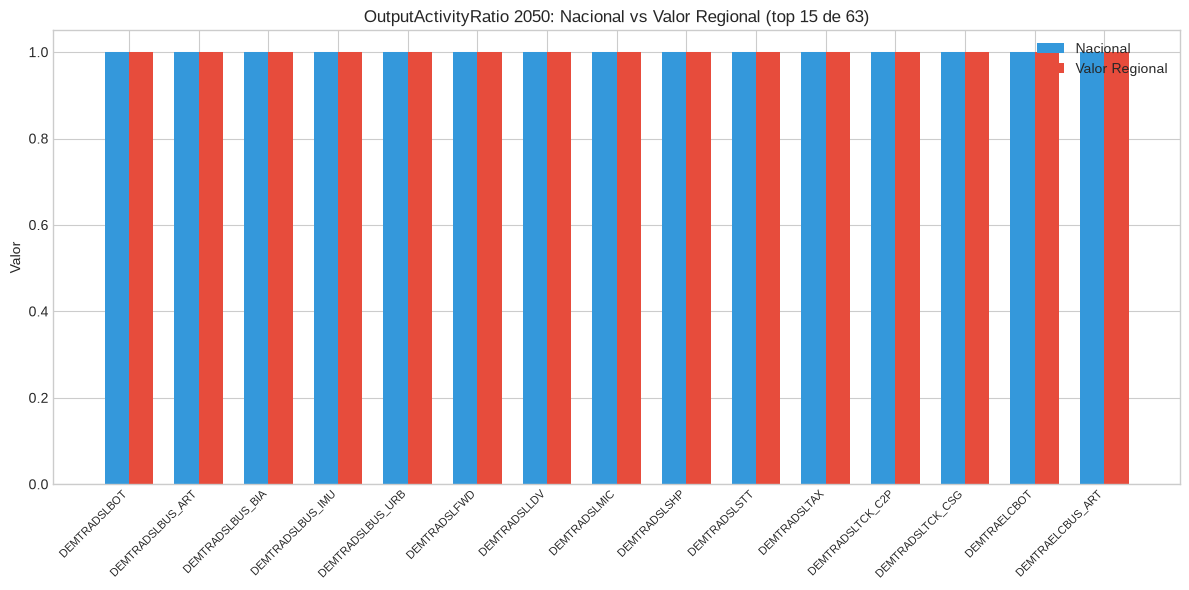

Excel validacion profunda exportado: /home/jchavez/Documentos/UPME/Datos Simulacion/output/05_validacion_profunda_transporte.xlsx


In [18]:
# --- 5.3 Analisis profundo: Validacion Regional vs Nacional (Transporte) ---
display(Markdown("### 5.3 Analisis profundo: Regional vs Nacional (Transporte)"))
display(Markdown(
    "Validacion de **8 parametros** de transporte con emparejamiento por dimension correcta "
    "y reporte de variables sin equivalente en el otro archivo.\n\n"
    "| Parametro | Dimension | Tipo |\n"
    "|-----------|-----------|------|\n"
    "| AccumulatedAnnualDemand | FUEL | aditivo |\n"
    "| ResidualCapacity | TECHNOLOGY | aditivo |\n"
    "| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |\n"
    "| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |\n"
    "| CapitalCost | TECHNOLOGY | no aditivo |\n"
    "| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |\n"
    "| InputActivityRatio | TECH+FUEL+MODE | no aditivo |\n"
    "| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |"
))

PARAMS_TRANSPORTE = {
    "AccumulatedAnnualDemand": {"dim": "fuel", "tipo": "aditivo", "dim_label": "FUEL"},
    "ResidualCapacity": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalAnnualMaxCapacityInvestment": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyAnnualActivityUpperLimit": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "CapitalCost": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyModelPeriodActivityUpperLimit": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "InputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
    "OutputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
}

anos_validar = [c for c in get_value_cols(nac_tra) if c != TIME_INDEP_COL]
disc_tra_rows = []
coinc_tra_rows = []
sin_emparejar_rows = []


def _fuel_base(val):
    _, base = split_regional_name(val)
    return base


def _tech_base(val):
    _, base = split_regional_name(val)
    return base


def _mode_base(val):
    return normalize_text(val)


def _make_tfm_key(row):
    return (_tech_base(row["TECHNOLOGY"]), _fuel_base(row["FUEL"]), _mode_base(row["MODE_OF_OPERATION"]))


for param, cfg in PARAMS_TRANSPORTE.items():
    dim = cfg["dim"]
    tipo = cfg["tipo"]
    nac_p = nac_tra[nac_tra["Parameter"] == param].copy()
    reg_p = reg_tra[reg_tra["Parameter"] == param].copy()

    if dim == "fuel":
        nac_vars = sorted(nac_fuels_tra)
        reg_vars = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for fuel in nac_vars:
            nac_rows = nac_p[nac_p["FUEL"].apply(_fuel_base) == fuel]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["FUEL"].apply(_fuel_base) == fuel]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_sum = reg_rows[anio].apply(safe_float).sum()
                diff = reg_sum - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": fuel,
                    "Descripcion": MODOS_TRA.get(fuel, fuel),
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_sum,
                    "Diferencia": diff,
                    "Coincide": values_close(nac_val, reg_sum),
                    "Tipo": tipo,
                }
                (coinc_tra_rows if row["Coincide"] else disc_tra_rows).append(row)

    elif dim == "tech":
        nac_vars = sorted({_tech_base(t) for t in nac_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})
        reg_vars = sorted({_tech_base(t) for t in reg_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for tech in nac_vars:
            nac_rows = nac_p[nac_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                if tipo == "no_aditivo":
                    all_match = all(values_close(nac_val, v) for v in reg_vals)
                    reg_ref = reg_vals.iloc[0]
                    diff = reg_ref - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_ref,
                        "Diferencia": diff,
                        "Coincide": all_match,
                        "Tipo": tipo,
                        "Num_Regiones": len(reg_vals),
                    }
                else:
                    reg_sum = reg_vals.sum()
                    diff = reg_sum - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_sum,
                        "Diferencia": diff,
                        "Coincide": values_close(nac_val, reg_sum),
                        "Tipo": tipo,
                    }
                (coinc_tra_rows if row["Coincide"] else disc_tra_rows).append(row)

    elif dim == "tech_fuel_mode":
        nac_keys = {_make_tfm_key(r): r for _, r in nac_p.iterrows()}
        reg_keys = {}
        for _, r in reg_p.iterrows():
            key = _make_tfm_key(r)
            reg_keys.setdefault(key, []).append(r)

        nac_key_set = set(nac_keys)
        reg_key_set = set(reg_keys)

        for key in sorted(nac_key_set - reg_key_set):
            sin_emparejar_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Nacional",
                "Dimension": cfg["dim_label"],
            })
        for key in sorted(reg_key_set - nac_key_set):
            sin_emparejar_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Regional",
                "Dimension": cfg["dim_label"],
            })

        for key in sorted(nac_key_set & reg_key_set):
            nac_row = nac_keys[key]
            reg_rows = pd.DataFrame(reg_keys[key])
            tech, fuel, mode = key

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                all_match = all(values_close(nac_val, v) for v in reg_vals)
                reg_ref = reg_vals.iloc[0]
                diff = reg_ref - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": f"{tech}|{fuel}|{mode}",
                    "Descripcion": tech,
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_ref,
                    "Diferencia": diff,
                    "Coincide": all_match,
                    "Tipo": tipo,
                    "Num_Regiones": len(reg_vals),
                }
                (coinc_tra_rows if row["Coincide"] else disc_tra_rows).append(row)

# DataFrames de resultados
df_disc_tra = pd.DataFrame(disc_tra_rows)
df_coinc_tra = pd.DataFrame(coinc_tra_rows)
df_sin_emparejar = pd.DataFrame(sin_emparejar_rows)

if not df_disc_tra.empty:
    df_disc_tra["Abs_Diff"] = df_disc_tra["Diferencia"].abs()
    df_disc_tra["Suma_Regional"] = df_disc_tra["Valor_Regional"]


def _resumir_discrepancias(df_p_disc: pd.DataFrame, df_p_coinc: pd.DataFrame) -> pd.DataFrame:
    """Agrupa discrepancias por Parameter+Modo e indica cuantos anos fallan (o 'todos')."""
    if df_p_disc.empty:
        return pd.DataFrame()

    resumen_rows = []
    for (param, modo), group in df_p_disc.groupby(["Parameter", "Modo"], sort=True):
        disc_anios = {str(a) for a in group["Anio"].dropna().unique()}
        if not df_p_coinc.empty:
            coinc_group = df_p_coinc[
                (df_p_coinc["Parameter"] == param) & (df_p_coinc["Modo"] == modo)
            ]
            coinc_anios = {str(a) for a in coinc_group["Anio"].dropna().unique()}
            total_anios = len(disc_anios | coinc_anios)
        else:
            total_anios = len(disc_anios)

        n_disc_anios = len(disc_anios)
        anios_label = "todos" if n_disc_anios == total_anios and total_anios > 0 else str(n_disc_anios)

        resumen_rows.append({
            "Parameter": param,
            "Modo": modo,
            "Descripcion": group["Descripcion"].iloc[0],
            "Tipo": group["Tipo"].iloc[0] if "Tipo" in group.columns else "",
            "Anios_Discrepancia": anios_label,
            "Total_Anios": total_anios,
            "Max_Diferencia": group["Abs_Diff"].max(),
        })

    return pd.DataFrame(resumen_rows).sort_values("Max_Diferencia", ascending=False)


def _plot_comparacion_2050(
    df_p_disc: pd.DataFrame,
    df_p_coinc: pd.DataFrame,
    param: str,
    cfg: dict,
    max_bars: int = 15,
) -> None:
    """Grafica de barras 2050: Nacional vs Regional (suma o valor segun tipo)."""
    frames = [f for f in [df_p_disc, df_p_coinc] if not f.empty]
    if not frames:
        return

    all_data = pd.concat(frames, ignore_index=True)
    data_2050 = all_data[all_data["Anio"] == "2050"].copy()
    if data_2050.empty:
        return

    data_2050 = data_2050.drop_duplicates(subset=["Modo"], keep="first")
    n_total = len(data_2050)

    if not df_p_disc.empty:
        disc_2050 = df_p_disc[df_p_disc["Anio"] == "2050"].copy()
        if not disc_2050.empty:
            disc_2050["Abs_Diff"] = disc_2050["Diferencia"].abs()
            disc_modos = disc_2050.sort_values("Abs_Diff", ascending=False)["Modo"].tolist()
            priority = data_2050[data_2050["Modo"].isin(disc_modos)].set_index("Modo").loc[disc_modos].reset_index()
            rest = data_2050[~data_2050["Modo"].isin(disc_modos)]
            data_2050 = pd.concat([priority, rest], ignore_index=True)

    data_2050 = data_2050.sort_values("Nacional", ascending=False, na_position="last")
    data_plot = data_2050.head(max_bars)

    tipo = cfg["tipo"]
    reg_label = "Suma Regional" if tipo == "aditivo" else "Valor Regional"
    ylabels = {
        "AccumulatedAnnualDemand": "Demanda (PJ)",
        "ResidualCapacity": "Capacidad (MW)",
        "CapitalCost": "Costo ($/kW)",
    }
    ylabel = ylabels.get(param, "Valor")

    labels = []
    for _, row in data_plot.iterrows():
        modo = row["Modo"]
        if param == "AccumulatedAnnualDemand":
            labels.append(MODOS_TRA.get(modo, modo))
        else:
            desc = row.get("Descripcion", modo)
            text = str(desc if pd.notna(desc) else modo)
            labels.append(text if len(text) <= 28 else text[:25] + "...")

    fig_w = max(12, len(data_plot) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    x = np.arange(len(data_plot))
    w = 0.35
    ax.bar(x - w / 2, data_plot["Nacional"].fillna(0), w, label="Nacional", color="#3498db")
    ax.bar(x + w / 2, data_plot["Valor_Regional"].fillna(0), w, label=reg_label, color="#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    suffix = f" (top {len(data_plot)} de {n_total})" if n_total > max_bars else ""
    ax.set_title(f"{param} 2050: Nacional vs {reg_label}{suffix}")
    ax.legend()
    plt.tight_layout()
    plt.show()


cols_disc_resumen = ["Parameter", "Modo", "Descripcion", "Tipo", "Anios_Discrepancia", "Total_Anios", "Max_Diferencia"]
cols_disc = ["Parameter", "Modo", "Descripcion", "Anio", "Nacional", "Valor_Regional", "Diferencia", "Tipo"]

# --- Resumen global ---
n_coinc = len(coinc_tra_rows)
n_disc = len(disc_tra_rows)
n_sin = len(sin_emparejar_rows)
pct_global = round(100 * n_coinc / (n_coinc + n_disc), 1) if (n_coinc + n_disc) > 0 else 100

display(Markdown(
    f"**Resultado global:** {n_coinc} coincidencias | {n_disc} discrepancias | "
    f"{n_sin} variables sin emparejar | **{pct_global}% coincidencia**"
))

resumen_param_rows = []
for param, cfg in PARAMS_TRANSPORTE.items():
    n_c = sum(1 for r in coinc_tra_rows if r["Parameter"] == param)
    n_d = sum(1 for r in disc_tra_rows if r["Parameter"] == param)
    n_s = sum(1 for r in sin_emparejar_rows if r["Parameter"] == param)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)
    resumen_param_rows.append({
        "Parameter": param,
        "Dimension": cfg["dim_label"],
        "Tipo_Validacion": cfg["tipo"],
        "Coincidencias": n_c,
        "Discrepancias": n_d,
        "Sin_Emparejar": n_s,
        "Pct_Coincidencia": pct_p,
    })

df_resumen_param_tra = pd.DataFrame(resumen_param_rows)
display(Markdown("**Resumen por parametro:**"))
show_df(df_resumen_param_tra)

# Resumen global de discrepancias por Parameter + Modo
if not df_disc_tra.empty:
    df_disc_resumen_global = _resumir_discrepancias(df_disc_tra, df_coinc_tra)
    display(Markdown("**Resumen global de discrepancias (por variable):**"))
    display(Markdown(
        "Cada fila indica cuantos años tienen discrepancia para ese Parameter+Modo. "
        "Si falla en todos los años comparados, muestra **todos**."
    ))
    show_df(df_disc_resumen_global[cols_disc_resumen], max_rows=100)

# --- Reporte de FUELs renombrados (InputActivityRatio / OutputActivityRatio) ---
display(Markdown("#### FUELs sin equivalencia exacta (InputActivityRatio / OutputActivityRatio)"))
display(Markdown(
    "Combustibles que existen en un archivo pero no en el otro (sin mapeo manual). "
    "Esto explica parte de las variables sin emparejar."
))

for param_report in ["InputActivityRatio", "OutputActivityRatio"]:
    nac_p = nac_tra[nac_tra["Parameter"] == param_report]
    reg_p = reg_tra[reg_tra["Parameter"] == param_report]
    nac_fuels = sorted({_fuel_base(f) for f in nac_p["FUEL"].dropna().unique() if _fuel_base(f)})
    reg_fuels = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})
    solo_nac = sorted(set(nac_fuels) - set(reg_fuels))
    solo_reg = sorted(set(reg_fuels) - set(nac_fuels))
    comunes = sorted(set(nac_fuels) & set(reg_fuels))

    display(Markdown(f"**{param_report}** — {len(comunes)} FUELs en ambos | {len(solo_nac)} solo NAC | {len(solo_reg)} solo REG"))
    if solo_nac:
        display(Markdown(f"- Solo Nacional: `{', '.join(solo_nac)}`"))
    if solo_reg:
        display(Markdown(f"- Solo Regional: `{', '.join(solo_reg)}`"))

# --- Detalle por parametro ---
disc_resumen_all = []

for param, cfg in PARAMS_TRANSPORTE.items():
    display(Markdown(f"#### {param}"))
    display(Markdown(f"Dimension: **{cfg['dim_label']}** | Tipo: **{cfg['tipo']}**"))

    df_p_disc = df_disc_tra[df_disc_tra["Parameter"] == param] if not df_disc_tra.empty else pd.DataFrame()
    df_p_coinc = df_coinc_tra[df_coinc_tra["Parameter"] == param] if not df_coinc_tra.empty else pd.DataFrame()
    df_p_sin = df_sin_emparejar[df_sin_emparejar["Parameter"] == param] if not df_sin_emparejar.empty else pd.DataFrame()

    n_c = len(df_p_coinc)
    n_d = len(df_p_disc)
    n_modos_disc = df_p_disc[["Parameter", "Modo"]].drop_duplicates().shape[0] if not df_p_disc.empty else 0
    n_s = len(df_p_sin)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)

    display(Markdown(
        f"{n_c} coincidencias | {n_d} discrepancias ({n_modos_disc} modos/variables) | "
        f"{n_s} sin emparejar | **{pct_p}% coincidencia**"
    ))

    if not df_p_disc.empty:
        df_p_disc_resumen = _resumir_discrepancias(df_p_disc, df_p_coinc)
        disc_resumen_all.append(df_p_disc_resumen)
        display(Markdown("**Discrepancias (resumen por variable):**"))
        display(Markdown(
            "Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años."
        ))
        show_df(df_p_disc_resumen[cols_disc_resumen], max_rows=50)

        display(Markdown("**Discrepancias (detalle por año):**"))
        show_df(df_p_disc.sort_values("Abs_Diff", ascending=False)[cols_disc], max_rows=50)
    else:
        display(Markdown("_Sin discrepancias en comparaciones emparejadas._"))

    if not df_p_sin.empty:
        display(Markdown("**Variables sin emparejar:**"))
        show_df(df_p_sin[["Variable", "Lado", "Dimension"]], max_rows=30)

    if not df_p_coinc.empty or not df_p_disc.empty:
        max_bars = 30 if param == "AccumulatedAnnualDemand" else 15
        display(Markdown(f"**Comparacion 2050 (grafica):**"))
        _plot_comparacion_2050(df_p_disc, df_p_coinc, param, cfg, max_bars=max_bars)
    elif df_p_sin.empty:
        display(Markdown("_Sin datos emparejados para graficar._"))

df_disc_resumen_tra = (
    pd.concat(disc_resumen_all, ignore_index=True)
    if disc_resumen_all
    else pd.DataFrame()
)

# Exportar resultados de validacion profunda
output_validacion = OUTPUT_DIR / "05_validacion_profunda_transporte.xlsx"
with pd.ExcelWriter(output_validacion, engine="openpyxl") as writer:
    df_resumen_param_tra.to_excel(writer, sheet_name="Resumen", index=False)
    if not df_disc_resumen_tra.empty:
        df_disc_resumen_tra.to_excel(writer, sheet_name="Discrepancias_Resumen", index=False)
    if not df_disc_tra.empty:
        df_disc_tra.to_excel(writer, sheet_name="Discrepancias_Detalle", index=False)
    if not df_coinc_tra.empty:
        df_coinc_tra.to_excel(writer, sheet_name="Coincidencias", index=False)
    if not df_sin_emparejar.empty:
        df_sin_emparejar.to_excel(writer, sheet_name="Sin_Emparejar", index=False)
print(f"Excel validacion profunda exportado: {output_validacion}")

validacion_profunda_tra = {
    "Sector": "TRA",
    "Filas_Nacional": len(nac_tra),
    "Filas_Regional": len(reg_tra),
    "Coincidencias": n_coinc,
    "Discrepancias": n_disc,
    "Sin_Emparejar": n_sin,
    "Pct_Coincidencia": pct_global,
    "Excel": "05_validacion_profunda_transporte.xlsx",
    "df_resumen_param": df_resumen_param_tra,
}



### 5.4 Desglose por combustible y region

**Tecnologias de transporte por combustible (Nacional)**

Combustible,Descripcion,Num_Tecnologias
ELC,Electrico,14
DSL,Diesel,13
NGS,Gas natural,11
GSL,Gasolina,9
HDG,Hidrogeno,8
PHE,Plug-in hibrido,3
JET,Jet fuel,2
HEV,Hibrido,2
FOL,Fuel oil,1


**Demanda por region y modo (2022 y 2050):**

Region,Modo,Modo_Desc,2022,2050
AN,TRAAVI,Aviacion,13.177828,18.740605
AN,TRASTT,Barcos/STT,7.065804,10.214741
AN,TRATCK,Camiones,3.486251,5.139816
AN,TRAMTC,MTC,2.841595,1.531775
AN,TRAFWD,4x4/FWD,2.781714,7.837728
AN,TRABUS,Buses,2.515450,11.668674
AN,TRATAX,Taxis,1.668802,1.515028
AN,TRAMRT,Metro/MRT,0.850053,2.008090
AN,TRAMIC,Motocicletas,0.405501,0.746207
AN,TRAMET,Metro electrico,0.123000,1.031000


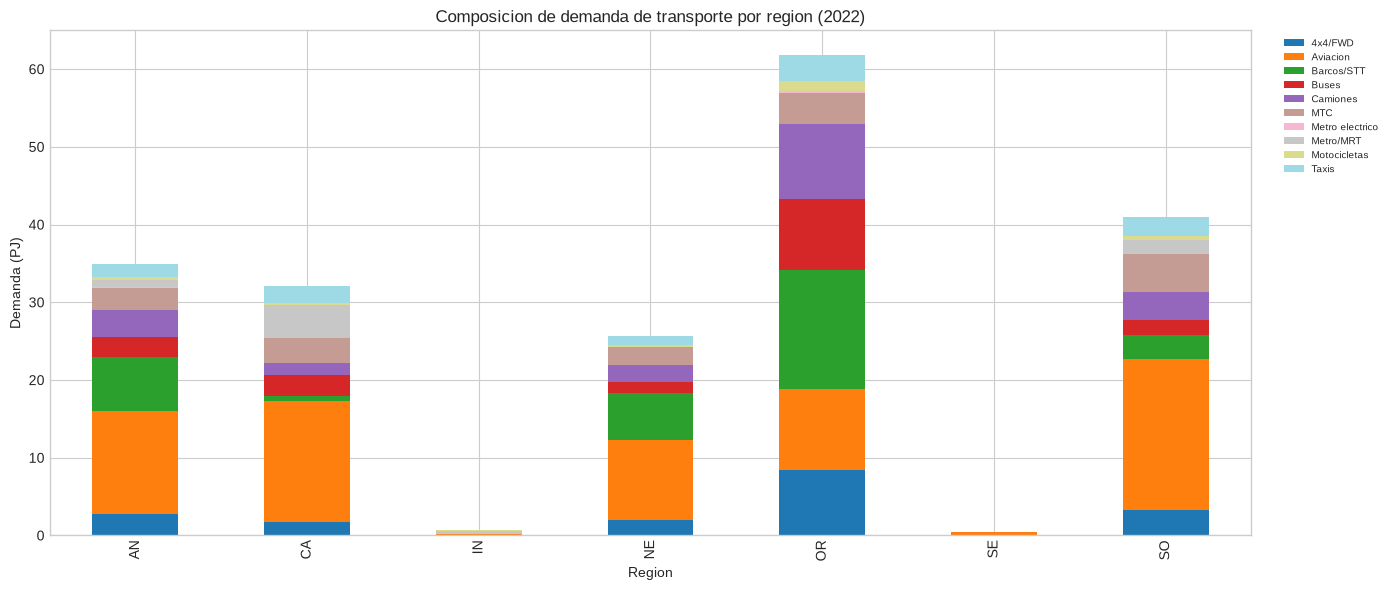

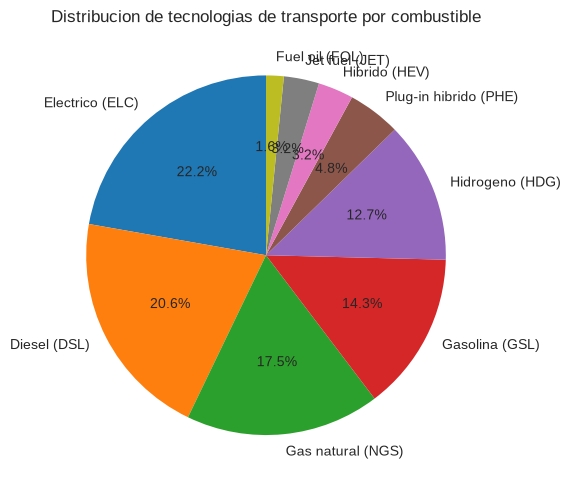

Excel transporte exportado: /home/jchavez/Documentos/UPME/Datos Simulacion/output/04_analisis_transporte.xlsx


In [19]:
# --- 5.4 Desglose por combustible y region ---
COMBUSTIBLES_TRA = {
    "DSL": "Diesel", "ELC": "Electrico", "GSL": "Gasolina", "HDG": "Hidrogeno",
    "NGS": "Gas natural", "FOL": "Fuel oil", "JET": "Jet fuel", "HEV": "Hibrido", "PHE": "Plug-in hibrido",
}

def extraer_combustible_tech(tech):
    if not tech or "DEMTRA" not in tech:
        return None
    base = tech.replace("DEMTRA", "")
    for comb in sorted(COMBUSTIBLES_TRA.keys(), key=len, reverse=True):
        if base.startswith(comb):
            return comb
    return base[:3] if len(base) >= 3 else None

display(Markdown("### 5.4 Desglose por combustible y region"))

# Tecnologias DEMTRA en nacional
tech_tra_nac = [t for t in nac_tra["TECHNOLOGY"].dropna().unique() if "DEMTRA" in str(t)]
combust_rows = []
for tech in sorted(tech_tra_nac):
    comb = extraer_combustible_tech(tech)
    combust_rows.append({"TECHNOLOGY": tech, "Combustible": comb, "Descripcion": COMBUSTIBLES_TRA.get(comb, comb)})
df_combust = pd.DataFrame(combust_rows)
combust_count = df_combust.groupby(["Combustible", "Descripcion"]).size().reset_index(name="Num_Tecnologias")
show_df(combust_count.sort_values("Num_Tecnologias", ascending=False), "Tecnologias de transporte por combustible (Nacional)")

# Demanda regional por modo y region (2022 y 2050)
reg_aad_tra = reg_tra[reg_tra["Parameter"] == "AccumulatedAnnualDemand"].copy()
reg_aad_tra["Region"] = reg_aad_tra["FUEL"].apply(lambda f: split_regional_name(f)[0])
reg_aad_tra["Modo"] = reg_aad_tra["FUEL"].apply(lambda f: split_regional_name(f)[1])
reg_aad_tra["Modo_Desc"] = reg_aad_tra["Modo"].map(MODOS_TRA)

demanda_regional = reg_aad_tra.groupby(["Region", "Modo", "Modo_Desc"])[["2022", "2050"]].sum().reset_index()
demanda_regional = demanda_regional.sort_values(["Region", "2022"], ascending=[True, False])

display(Markdown("**Demanda por region y modo (2022 y 2050):**"))
show_df(demanda_regional.head(25), max_rows=25)

# Grafica apilada: participacion por region en 2022
pivot_2022 = demanda_regional.pivot_table(index="Region", columns="Modo_Desc", values="2022", aggfunc="sum", fill_value=0)
pivot_2022 = pivot_2022.reindex(REGIONES).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot_2022.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("Demanda (PJ)")
ax.set_xlabel("Region")
ax.set_title("Composicion de demanda de transporte por region (2022)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

# Participacion porcentual por combustible (tecnologias)
if not df_combust.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    counts = df_combust["Combustible"].value_counts()
    labels = [f"{COMBUSTIBLES_TRA.get(c, c)} ({c})" for c in counts.index]
    ax.pie(counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
    ax.set_title("Distribucion de tecnologias de transporte por combustible")
    plt.tight_layout()
    plt.show()

# Exportar Excel de transporte
output_tra = OUTPUT_DIR / "04_analisis_transporte.xlsx"
with pd.ExcelWriter(output_tra, engine="openpyxl") as w:
    demanda_modo.to_excel(w, sheet_name="Demanda_Nacional", index=False)
    df_cobertura.to_excel(w, sheet_name="Cobertura_Regional", index=False)
    if not df_disc_tra.empty:
        df_disc_tra.to_excel(w, sheet_name="Discrepancias", index=False)
    demanda_regional.to_excel(w, sheet_name="Demanda_Regional", index=False)
    combust_count.to_excel(w, sheet_name="Combustibles", index=False)
print(f"Excel transporte exportado: {output_tra}")

---
## 6. Validacion profunda — Sector Industrial (IND*)

Validacion de los mismos 8 parametros que en 5.3, filtrando filas con **IND** en TECHNOLOGY o FUEL.


### 6.1 Analisis profundo: Regional vs Nacional (Industrial)

Validacion de **8 parametros** del sector industrial con emparejamiento por dimension correcta y reporte de variables sin equivalente en el otro archivo.

| Parametro | Dimension | Tipo |
|-----------|-----------|------|
| AccumulatedAnnualDemand | FUEL | aditivo |
| ResidualCapacity | TECHNOLOGY | aditivo |
| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |
| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |
| CapitalCost | TECHNOLOGY | no aditivo |
| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |
| InputActivityRatio | TECH+FUEL+MODE | no aditivo |
| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |

- Filas Nacional (IND*): **11,627** | Filas Regional (IND*): **4,812**

**Resultado global:** 6234 coincidencias | 2470 discrepancias | 2721 variables sin emparejar | **71.6% coincidencia**

**Resumen por parametro:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
AccumulatedAnnualDemand,INDIHT,INDIHT,2054,242.332471,296.135906,53.803434,aditivo
AccumulatedAnnualDemand,INDIHT,INDIHT,2053,233.081806,284.860035,51.778229,aditivo
AccumulatedAnnualDemand,INDIHT,INDIHT,2052,224.147406,273.967023,49.819617,aditivo
AccumulatedAnnualDemand,INDIHT,INDIHT,2051,215.745977,263.501859,47.755881,aditivo
AccumulatedAnnualDemand,INDIHT,INDIHT,2050,207.668030,253.451037,45.783007,aditivo
AccumulatedAnnualDemand,INDIHT,INDIHT,2049,199.900065,243.796567,43.896502,aditivo
AccumulatedAnnualDemand,INDIHT,INDIHT,2048,192.418101,234.507463,42.089362,aditivo
AccumulatedAnnualDemand,INDIHT,INDIHT,2047,185.211558,225.561912,40.350354,aditivo
AccumulatedAnnualDemand,INDIHT,INDIHT,2046,178.271228,216.950463,38.679235,aditivo
AccumulatedAnnualDemand,INDIHT,INDIHT,2045,171.633240,208.721097,37.087857,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
INDOTH_COA,Solo Nacional,FUEL
INDOTH_ELC,Solo Nacional,FUEL


**Comparacion 2050 (grafica):**

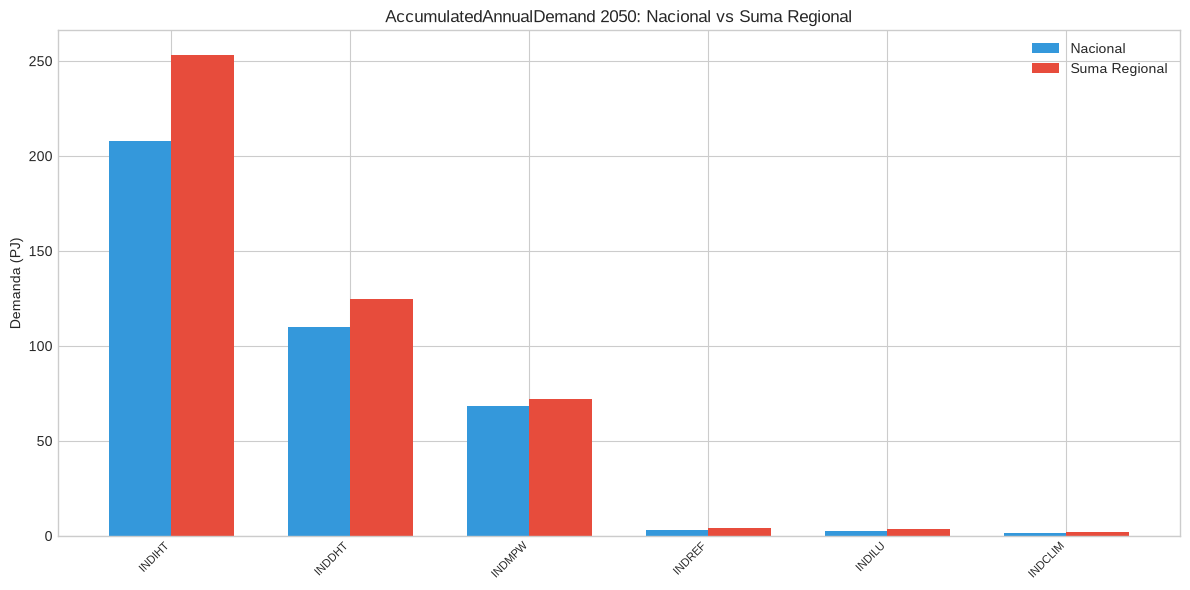

#### ResidualCapacity

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

865 coincidencias | 1277 discrepancias (63 modos/variables) | 8 sin emparejar | **40.4% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
ResidualCapacity,DEMINDNGSBOI_MID,DEMINDNGSBOI_MID,2054,0.090347,108.542946,108.452599,aditivo
ResidualCapacity,DEMINDNGSBOI_MID,DEMINDNGSBOI_MID,2053,0.113673,104.305237,104.191564,aditivo
ResidualCapacity,DEMINDNGSBOI_MID,DEMINDNGSBOI_MID,2052,0.139214,100.181936,100.042722,aditivo
ResidualCapacity,DEMINDNGSBOI_MID,DEMINDNGSBOI_MID,2051,0.166362,96.180049,96.013687,aditivo
ResidualCapacity,DEMINDNGSBOI_MID,DEMINDNGSBOI_MID,2050,0.194433,92.279822,92.085390,aditivo
ResidualCapacity,DEMINDBAGBOI_MID,DEMINDBAGBOI_MID,2054,0.000004,87.972112,87.972107,aditivo
ResidualCapacity,DEMINDNGSBOI_MID,DEMINDNGSBOI_MID,2049,0.222721,88.169049,87.946328,aditivo
ResidualCapacity,DEMINDCOAFUR_MID,DEMINDCOAFUR_MID,2054,0.272640,85.676778,85.404137,aditivo
ResidualCapacity,DEMINDBAGBOI_MID,DEMINDBAGBOI_MID,2053,0.000025,84.563688,84.563663,aditivo
ResidualCapacity,DEMINDNGSBOI_MID,DEMINDNGSBOI_MID,2048,0.250554,84.049889,83.799334,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMINDAUTBOI,Solo Nacional,TECHNOLOGY
DEMINDAUTFUR,Solo Nacional,TECHNOLOGY
DEMINDBAGBOI_HIG,Solo Nacional,TECHNOLOGY
DEMINDBAGFURCCS,Solo Nacional,TECHNOLOGY
DEMINDNGSFURCSS,Solo Nacional,TECHNOLOGY
DEMINDWASBOI_HIG,Solo Nacional,TECHNOLOGY
DEMINDWASFUR_HIG,Solo Nacional,TECHNOLOGY
MINDAM,Solo Nacional,TECHNOLOGY


**Comparacion 2050 (grafica):**

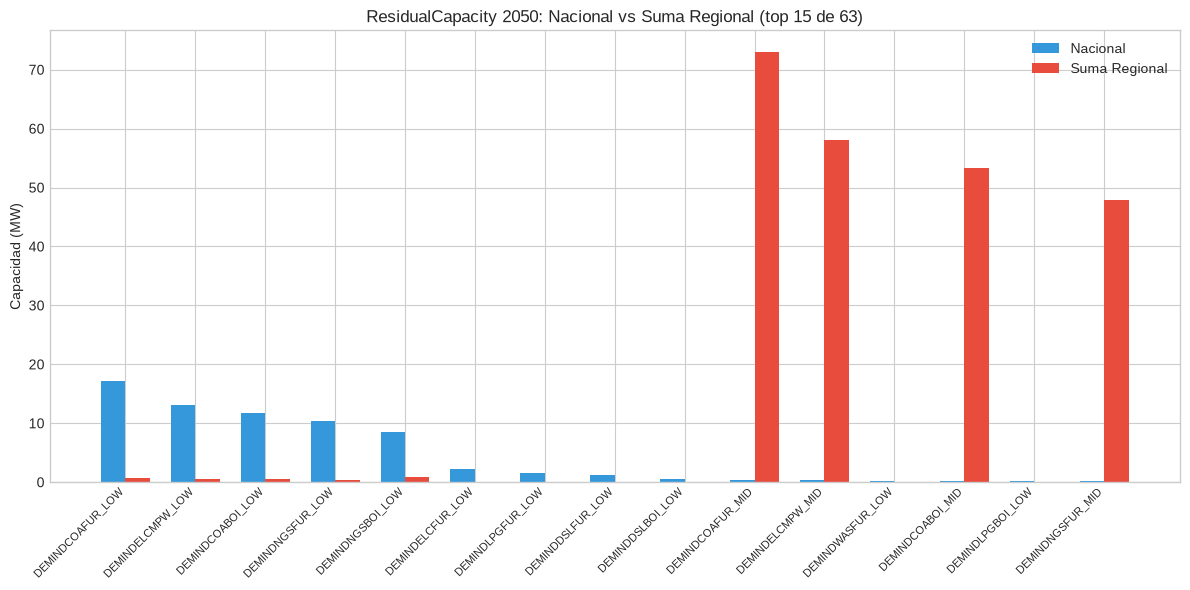

#### TotalAnnualMaxCapacityInvestment

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

66 coincidencias | 2 discrepancias (2 modos/variables) | 69 sin emparejar | **97.1% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
TotalAnnualMaxCapacityInvestment,DEMINDAUTBOI,DEMINDAUTBOI,2055,nan,0.000000,nan,aditivo
TotalAnnualMaxCapacityInvestment,DEMINDAUTFUR,DEMINDAUTFUR,2055,nan,0.000000,nan,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMINDBAGBOI_HIG,Solo Nacional,TECHNOLOGY
DEMINDBAGBOI_LOW,Solo Nacional,TECHNOLOGY
DEMINDBAGBOI_MID,Solo Nacional,TECHNOLOGY
DEMINDBAGFURCCS,Solo Nacional,TECHNOLOGY
DEMINDBAGFUR_HIG,Solo Nacional,TECHNOLOGY
DEMINDBAGFUR_LOW,Solo Nacional,TECHNOLOGY
DEMINDBAGFUR_MID,Solo Nacional,TECHNOLOGY
DEMINDBGSBOI_HIG,Solo Nacional,TECHNOLOGY
DEMINDBGSBOI_LOW,Solo Nacional,TECHNOLOGY
DEMINDBGSBOI_MID,Solo Nacional,TECHNOLOGY


**Comparacion 2050 (grafica):**

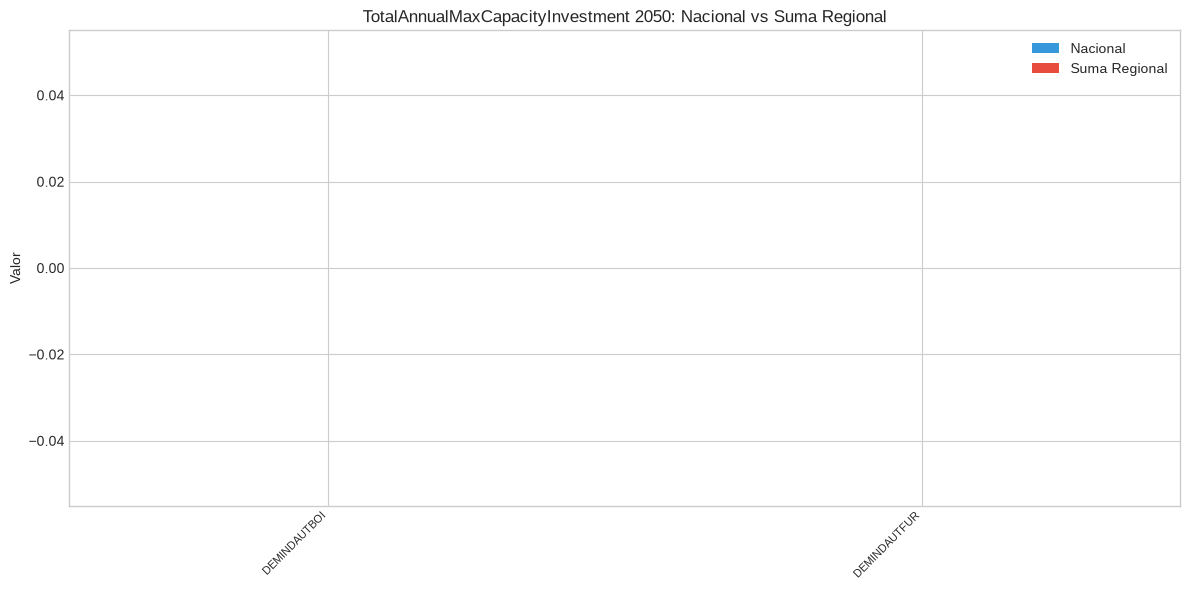

#### TotalTechnologyAnnualActivityUpperLimit

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

0 coincidencias | 68 discrepancias (2 modos/variables) | 69 sin emparejar | **0.0% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2022,99999.000000,499995.000000,399996.000000,aditivo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2023,99999.000000,499995.000000,399996.000000,aditivo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2024,99999.000000,499995.000000,399996.000000,aditivo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2025,99999.000000,499995.000000,399996.000000,aditivo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2026,99999.000000,499995.000000,399996.000000,aditivo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2027,99999.000000,499995.000000,399996.000000,aditivo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2028,99999.000000,499995.000000,399996.000000,aditivo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2029,99999.000000,499995.000000,399996.000000,aditivo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2030,99999.000000,499995.000000,399996.000000,aditivo
TotalTechnologyAnnualActivityUpperLimit,DEMINDAUTBOI,DEMINDAUTBOI,2031,99999.000000,499995.000000,399996.000000,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMINDBAGBOI_HIG,Solo Nacional,TECHNOLOGY
DEMINDBAGBOI_LOW,Solo Nacional,TECHNOLOGY
DEMINDBAGBOI_MID,Solo Nacional,TECHNOLOGY
DEMINDBAGFURCCS,Solo Nacional,TECHNOLOGY
DEMINDBAGFUR_HIG,Solo Nacional,TECHNOLOGY
DEMINDBAGFUR_LOW,Solo Nacional,TECHNOLOGY
DEMINDBAGFUR_MID,Solo Nacional,TECHNOLOGY
DEMINDBGSBOI_HIG,Solo Nacional,TECHNOLOGY
DEMINDBGSBOI_LOW,Solo Nacional,TECHNOLOGY
DEMINDBGSBOI_MID,Solo Nacional,TECHNOLOGY


**Comparacion 2050 (grafica):**

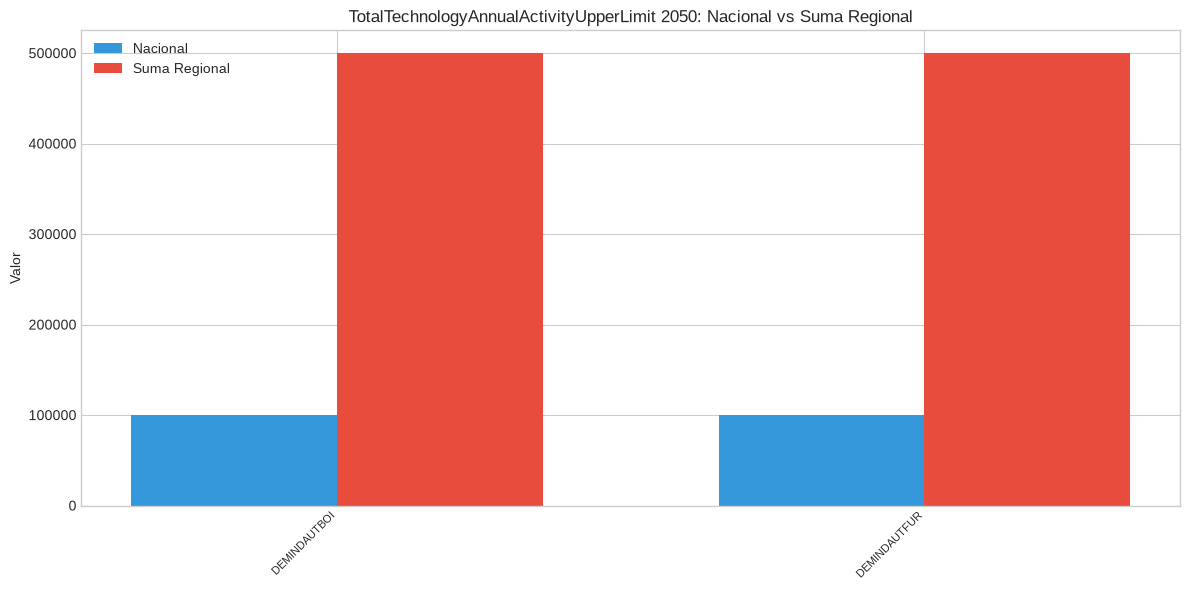

#### CapitalCost

Dimension: **TECHNOLOGY** | Tipo: **no_aditivo**

1947 coincidencias | 365 discrepancias (68 modos/variables) | 11 sin emparejar | **84.2% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
CapitalCost,DEMINDNGSFURCSS,DEMINDNGSFURCSS,2054,9999999.000000,99999.000000,-9900000.000000,no_aditivo
CapitalCost,DEMINDBAGFURCCS,DEMINDBAGFURCCS,2022,9999999.000000,99999.000000,-9900000.000000,no_aditivo
CapitalCost,DEMINDBAGFURCCS,DEMINDBAGFURCCS,2023,9999999.000000,99999.000000,-9900000.000000,no_aditivo
CapitalCost,DEMINDBAGFURCCS,DEMINDBAGFURCCS,2024,9999999.000000,99999.000000,-9900000.000000,no_aditivo
CapitalCost,DEMINDBAGFURCCS,DEMINDBAGFURCCS,2025,9999999.000000,99999.000000,-9900000.000000,no_aditivo
CapitalCost,DEMINDBAGFURCCS,DEMINDBAGFURCCS,2026,9999999.000000,99999.000000,-9900000.000000,no_aditivo
CapitalCost,DEMINDBAGFURCCS,DEMINDBAGFURCCS,2027,9999999.000000,99999.000000,-9900000.000000,no_aditivo
CapitalCost,DEMINDBAGFURCCS,DEMINDBAGFURCCS,2028,9999999.000000,99999.000000,-9900000.000000,no_aditivo
CapitalCost,DEMINDBAGFURCCS,DEMINDBAGFURCCS,2029,9999999.000000,99999.000000,-9900000.000000,no_aditivo
CapitalCost,DEMINDNGSFURCSS,DEMINDNGSFURCSS,2038,9999999.000000,99999.000000,-9900000.000000,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMINDAUTBOI,Solo Nacional,TECHNOLOGY
DEMINDAUTFUR,Solo Nacional,TECHNOLOGY
MINDAM,Solo Nacional,TECHNOLOGY
BACKSTOP_INDCLIM,Solo Regional,TECHNOLOGY
BACKSTOP_INDDHT,Solo Regional,TECHNOLOGY
BACKSTOP_INDIHT,Solo Regional,TECHNOLOGY
BACKSTOP_INDILU,Solo Regional,TECHNOLOGY
BACKSTOP_INDMPW,Solo Regional,TECHNOLOGY
BACKSTOP_INDOTH_COA,Solo Regional,TECHNOLOGY
BACKSTOP_INDOTH_ELC,Solo Regional,TECHNOLOGY


**Comparacion 2050 (grafica):**

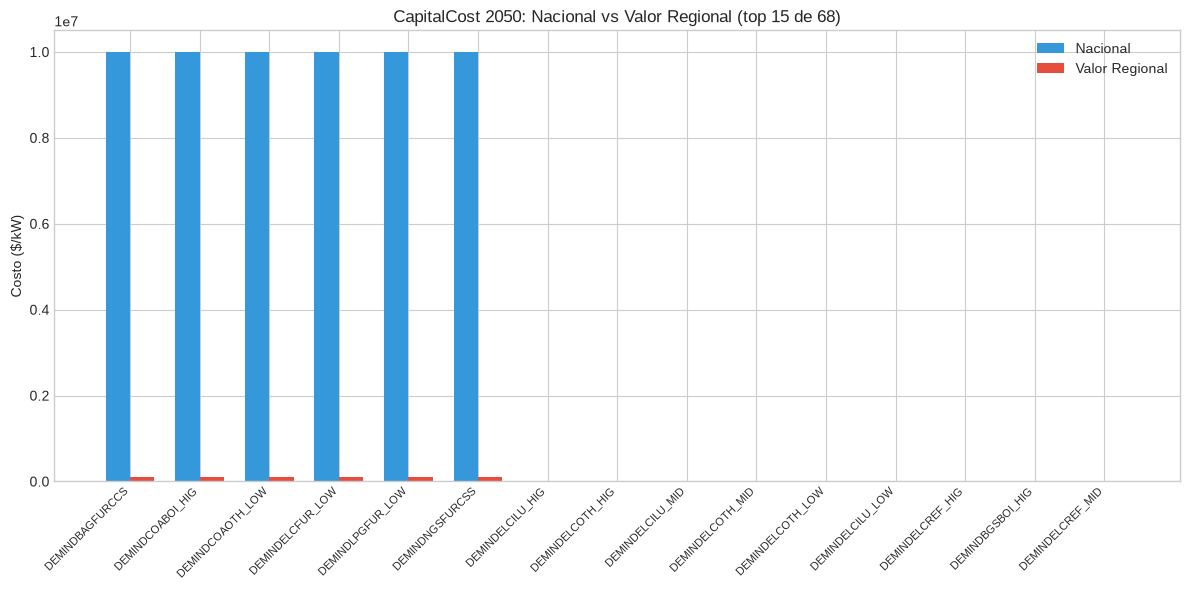

#### TotalTechnologyModelPeriodActivityUpperLimit

Dimension: **TECHNOLOGY** | Tipo: **no_aditivo**

0 coincidencias | 0 discrepancias (0 modos/variables) | 9 sin emparejar | **0% coincidencia**

_Sin discrepancias en comparaciones emparejadas._

**Variables sin emparejar:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
InputActivityRatio,DEMINDLPGBOI_MID|LPG002|1.0,DEMINDLPGBOI_MID,2046,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMINDLPGBOI_MID|LPG002|1.0,DEMINDLPGBOI_MID,2047,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMINDLPGBOI_MID|LPG002|1.0,DEMINDLPGBOI_MID,2049,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMINDLPGBOI_MID|LPG002|1.0,DEMINDLPGBOI_MID,2050,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMINDLPGBOI_MID|LPG002|1.0,DEMINDLPGBOI_MID,2051,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMINDLPGBOI_MID|LPG002|1.0,DEMINDLPGBOI_MID,2052,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMINDLPGBOI_MID|LPG002|1.0,DEMINDLPGBOI_MID,2053,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMINDLPGBOI_MID|LPG002|1.0,DEMINDLPGBOI_MID,2054,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMINDLPGBOI_MID|LPG002|1.0,DEMINDLPGBOI_MID,2055,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMINDDSLBOI_MID|DSL002|1.0,DEMINDDSLBOI_MID,2046,1.886792,2.616000,0.729208,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMINDELCAIR_HIG|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDELCAIR_LOW|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDELCAIR_MID|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDELCBOI_HIG|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDELCBOI_LOW|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDELCBOI_MID|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDELCFUR_HIG|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDELCFUR_LOW|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDELCFUR_MID|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDELCILU_HIG|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

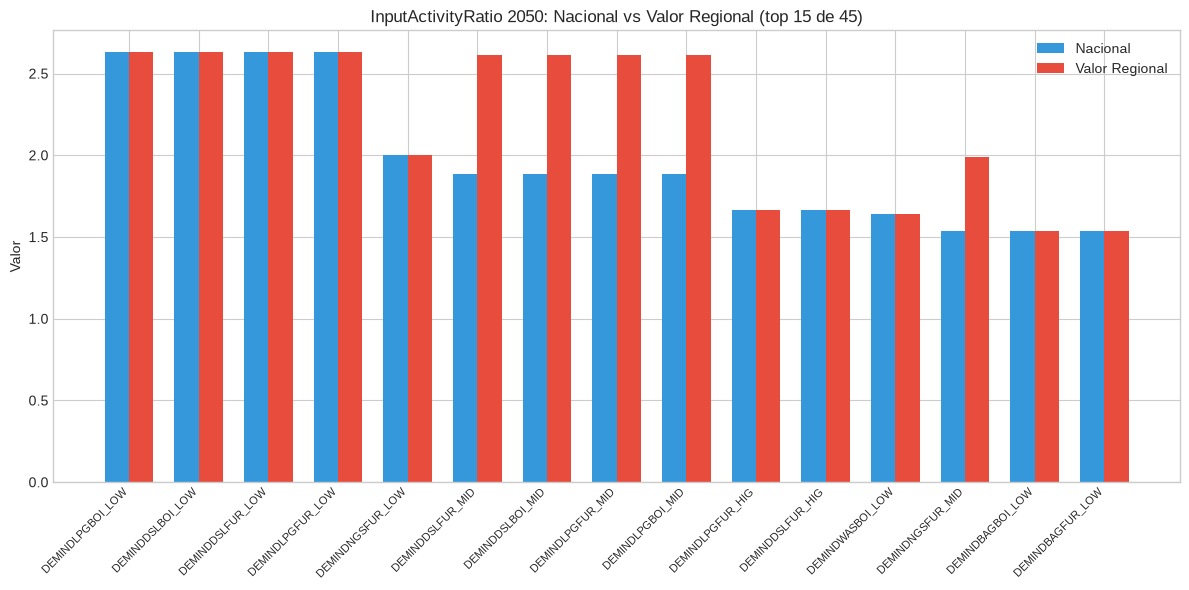

#### OutputActivityRatio

Dimension: **TECH+FUEL+MODE** | Tipo: **no_aditivo**

2310 coincidencias | 70 discrepancias (70 modos/variables) | 2507 sin emparejar | **97.1% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
OutputActivityRatio,DEMINDAUTBOI|INDIHT|1.0,DEMINDAUTBOI,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDAUTFUR|INDDHT|1.0,DEMINDAUTFUR,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGBOI_HIG|INDIHT|1.0,DEMINDBAGBOI_HIG,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGBOI_LOW|INDIHT|1.0,DEMINDBAGBOI_LOW,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGBOI_MID|INDIHT|1.0,DEMINDBAGBOI_MID,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGFURCCS|INDDHT|1.0,DEMINDBAGFURCCS,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGFUR_HIG|INDDHT|1.0,DEMINDBAGFUR_HIG,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGFUR_LOW|INDDHT|1.0,DEMINDBAGFUR_LOW,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGFUR_MID|INDDHT|1.0,DEMINDBAGFUR_MID,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBGSBOI_HIG|INDIHT|1.0,DEMINDBGSBOI_HIG,2055,nan,1.000000,nan,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMINDAUTBOI|AGFELC|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDAUTBOI|AGFHEA|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDAUTBOI|BAG|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDAUTBOI|BDL|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDAUTBOI|BET|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDAUTBOI|BGS|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDAUTBOI|COA|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDAUTBOI|COA002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDAUTBOI|CSP|1.0,Solo Nacional,TECH+FUEL+MODE
DEMINDAUTBOI|DAM|1.0,Solo Nacional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

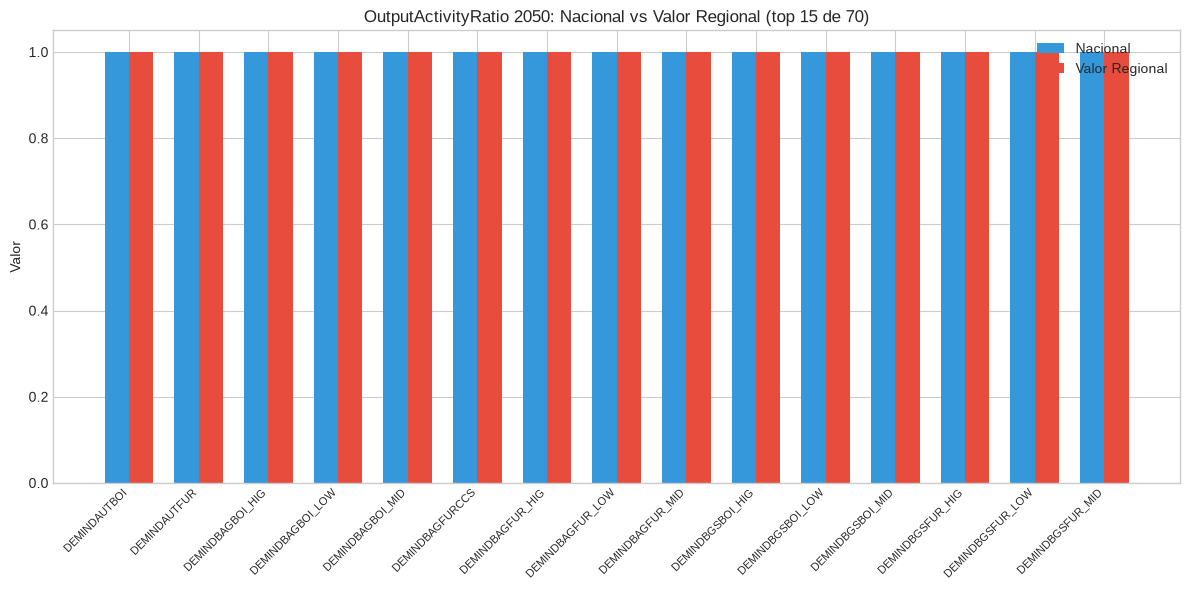

Excel validacion profunda exportado: /home/jchavez/Documentos/UPME/Datos Simulacion/output/06_validacion_profunda_IND.xlsx


In [20]:
# --- 6. Validacion profunda: Regional vs Nacional (Industrial) ---
display(Markdown("### 6.1 Analisis profundo: Regional vs Nacional (Industrial)"))
display(Markdown(
    "Validacion de **8 parametros** del sector industrial con emparejamiento por dimension correcta "
    "y reporte de variables sin equivalente en el otro archivo.\n\n"
    "| Parametro | Dimension | Tipo |\n"
    "|-----------|-----------|------|\n"
    "| AccumulatedAnnualDemand | FUEL | aditivo |\n"
    "| ResidualCapacity | TECHNOLOGY | aditivo |\n"
    "| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |\n"
    "| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |\n"
    "| CapitalCost | TECHNOLOGY | no aditivo |\n"
    "| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |\n"
    "| InputActivityRatio | TECH+FUEL+MODE | no aditivo |\n"
    "| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |"
))

PARAMS_IND = {
    "AccumulatedAnnualDemand": {"dim": "fuel", "tipo": "aditivo", "dim_label": "FUEL"},
    "ResidualCapacity": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalAnnualMaxCapacityInvestment": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyAnnualActivityUpperLimit": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "CapitalCost": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyModelPeriodActivityUpperLimit": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "InputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
    "OutputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
}


def is_ind(row):
    tech = normalize_text(row.get("TECHNOLOGY")) or ""
    fuel = normalize_text(row.get("FUEL")) or ""
    return ("IND" in tech) or ("IND" in fuel)

mask_nac_ind = df_nac.apply(is_ind, axis=1).astype(bool)
mask_reg_ind = df_reg.apply(is_ind, axis=1).astype(bool)
nac_ind = df_nac[mask_nac_ind].copy()
reg_ind = df_reg[mask_reg_ind].copy()
nac_fuels_ind = {normalize_text(f) for f in nac_ind["FUEL"].dropna().unique() if "IND" in str(f)}

display(Markdown(f"- Filas Nacional (IND*): **{len(nac_ind):,}** | Filas Regional (IND*): **{len(reg_ind):,}**"))

anos_validar = [c for c in get_value_cols(nac_ind) if c != TIME_INDEP_COL]
disc_ind_rows = []
coinc_ind_rows = []
sin_emparejar_ind_rows = []


def _fuel_base(val):
    _, base = split_regional_name(val)
    return base


def _tech_base(val):
    _, base = split_regional_name(val)
    return base


def _mode_base(val):
    return normalize_text(val)


def _make_tfm_key(row):
    return (_tech_base(row["TECHNOLOGY"]), _fuel_base(row["FUEL"]), _mode_base(row["MODE_OF_OPERATION"]))


for param, cfg in PARAMS_IND.items():
    dim = cfg["dim"]
    tipo = cfg["tipo"]
    nac_p = nac_ind[nac_ind["Parameter"] == param].copy()
    reg_p = reg_ind[reg_ind["Parameter"] == param].copy()

    if dim == "fuel":
        nac_vars = sorted(nac_fuels_ind)
        reg_vars = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_ind_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_ind_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for fuel in nac_vars:
            nac_rows = nac_p[nac_p["FUEL"].apply(_fuel_base) == fuel]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["FUEL"].apply(_fuel_base) == fuel]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_sum = reg_rows[anio].apply(safe_float).sum()
                diff = reg_sum - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": fuel,
                    "Descripcion": fuel,
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_sum,
                    "Diferencia": diff,
                    "Coincide": values_close(nac_val, reg_sum),
                    "Tipo": tipo,
                }
                (coinc_ind_rows if row["Coincide"] else disc_ind_rows).append(row)

    elif dim == "tech":
        nac_vars = sorted({_tech_base(t) for t in nac_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})
        reg_vars = sorted({_tech_base(t) for t in reg_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_ind_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_ind_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for tech in nac_vars:
            nac_rows = nac_p[nac_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                if tipo == "no_aditivo":
                    all_match = all(values_close(nac_val, v) for v in reg_vals)
                    reg_ref = reg_vals.iloc[0]
                    diff = reg_ref - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_ref,
                        "Diferencia": diff,
                        "Coincide": all_match,
                        "Tipo": tipo,
                        "Num_Regiones": len(reg_vals),
                    }
                else:
                    reg_sum = reg_vals.sum()
                    diff = reg_sum - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_sum,
                        "Diferencia": diff,
                        "Coincide": values_close(nac_val, reg_sum),
                        "Tipo": tipo,
                    }
                (coinc_ind_rows if row["Coincide"] else disc_ind_rows).append(row)

    elif dim == "tech_fuel_mode":
        nac_keys = {_make_tfm_key(r): r for _, r in nac_p.iterrows()}
        reg_keys = {}
        for _, r in reg_p.iterrows():
            key = _make_tfm_key(r)
            reg_keys.setdefault(key, []).append(r)

        nac_key_set = set(nac_keys)
        reg_key_set = set(reg_keys)

        for key in sorted(nac_key_set - reg_key_set):
            sin_emparejar_ind_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Nacional",
                "Dimension": cfg["dim_label"],
            })
        for key in sorted(reg_key_set - nac_key_set):
            sin_emparejar_ind_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Regional",
                "Dimension": cfg["dim_label"],
            })

        for key in sorted(nac_key_set & reg_key_set):
            nac_row = nac_keys[key]
            reg_rows = pd.DataFrame(reg_keys[key])
            tech, fuel, mode = key

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                all_match = all(values_close(nac_val, v) for v in reg_vals)
                reg_ref = reg_vals.iloc[0]
                diff = reg_ref - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": f"{tech}|{fuel}|{mode}",
                    "Descripcion": tech,
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_ref,
                    "Diferencia": diff,
                    "Coincide": all_match,
                    "Tipo": tipo,
                    "Num_Regiones": len(reg_vals),
                }
                (coinc_ind_rows if row["Coincide"] else disc_ind_rows).append(row)

# DataFrames de resultados
df_disc_ind = pd.DataFrame(disc_ind_rows)
df_coinc_ind = pd.DataFrame(coinc_ind_rows)
df_sin_emparejar_ind = pd.DataFrame(sin_emparejar_ind_rows)

if not df_disc_ind.empty:
    df_disc_ind["Abs_Diff"] = df_disc_ind["Diferencia"].abs()
    df_disc_ind["Suma_Regional"] = df_disc_ind["Valor_Regional"]


def _resumir_discrepancias(df_p_disc: pd.DataFrame, df_p_coinc: pd.DataFrame) -> pd.DataFrame:
    """Agrupa discrepancias por Parameter+Modo e indica cuantos anos fallan (o 'todos')."""
    if df_p_disc.empty:
        return pd.DataFrame()

    resumen_rows = []
    for (param, modo), group in df_p_disc.groupby(["Parameter", "Modo"], sort=True):
        disc_anios = {str(a) for a in group["Anio"].dropna().unique()}
        if not df_p_coinc.empty:
            coinc_group = df_p_coinc[
                (df_p_coinc["Parameter"] == param) & (df_p_coinc["Modo"] == modo)
            ]
            coinc_anios = {str(a) for a in coinc_group["Anio"].dropna().unique()}
            total_anios = len(disc_anios | coinc_anios)
        else:
            total_anios = len(disc_anios)

        n_disc_anios = len(disc_anios)
        anios_label = "todos" if n_disc_anios == total_anios and total_anios > 0 else str(n_disc_anios)

        resumen_rows.append({
            "Parameter": param,
            "Modo": modo,
            "Descripcion": group["Descripcion"].iloc[0],
            "Tipo": group["Tipo"].iloc[0] if "Tipo" in group.columns else "",
            "Anios_Discrepancia": anios_label,
            "Total_Anios": total_anios,
            "Max_Diferencia": group["Abs_Diff"].max(),
        })

    return pd.DataFrame(resumen_rows).sort_values("Max_Diferencia", ascending=False)


def _plot_comparacion_2050(
    df_p_disc: pd.DataFrame,
    df_p_coinc: pd.DataFrame,
    param: str,
    cfg: dict,
    max_bars: int = 15,
) -> None:
    """Grafica de barras 2050: Nacional vs Regional (suma o valor segun tipo)."""
    frames = [f for f in [df_p_disc, df_p_coinc] if not f.empty]
    if not frames:
        return

    all_data = pd.concat(frames, ignore_index=True)
    data_2050 = all_data[all_data["Anio"] == "2050"].copy()
    if data_2050.empty:
        return

    data_2050 = data_2050.drop_duplicates(subset=["Modo"], keep="first")
    n_total = len(data_2050)

    if not df_p_disc.empty:
        disc_2050 = df_p_disc[df_p_disc["Anio"] == "2050"].copy()
        if not disc_2050.empty:
            disc_2050["Abs_Diff"] = disc_2050["Diferencia"].abs()
            disc_modos = disc_2050.sort_values("Abs_Diff", ascending=False)["Modo"].tolist()
            priority = data_2050[data_2050["Modo"].isin(disc_modos)].set_index("Modo").loc[disc_modos].reset_index()
            rest = data_2050[~data_2050["Modo"].isin(disc_modos)]
            data_2050 = pd.concat([priority, rest], ignore_index=True)

    data_2050 = data_2050.sort_values("Nacional", ascending=False, na_position="last")
    data_plot = data_2050.head(max_bars)

    tipo = cfg["tipo"]
    reg_label = "Suma Regional" if tipo == "aditivo" else "Valor Regional"
    ylabels = {
        "AccumulatedAnnualDemand": "Demanda (PJ)",
        "ResidualCapacity": "Capacidad (MW)",
        "CapitalCost": "Costo ($/kW)",
    }
    ylabel = ylabels.get(param, "Valor")

    labels = []
    for _, row in data_plot.iterrows():
        modo = row["Modo"]
        if param == "AccumulatedAnnualDemand":
            labels.append(modo)
        else:
            desc = row.get("Descripcion", modo)
            text = str(desc if pd.notna(desc) else modo)
            labels.append(text if len(text) <= 28 else text[:25] + "...")

    fig_w = max(12, len(data_plot) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    x = np.arange(len(data_plot))
    w = 0.35
    ax.bar(x - w / 2, data_plot["Nacional"].fillna(0), w, label="Nacional", color="#3498db")
    ax.bar(x + w / 2, data_plot["Valor_Regional"].fillna(0), w, label=reg_label, color="#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    suffix = f" (top {len(data_plot)} de {n_total})" if n_total > max_bars else ""
    ax.set_title(f"{param} 2050: Nacional vs {reg_label}{suffix}")
    ax.legend()
    plt.tight_layout()
    plt.show()


cols_disc_resumen = ["Parameter", "Modo", "Descripcion", "Tipo", "Anios_Discrepancia", "Total_Anios", "Max_Diferencia"]
cols_disc = ["Parameter", "Modo", "Descripcion", "Anio", "Nacional", "Valor_Regional", "Diferencia", "Tipo"]

# --- Resumen global ---
n_coinc = len(coinc_ind_rows)
n_disc = len(disc_ind_rows)
n_sin = len(sin_emparejar_ind_rows)
pct_global = round(100 * n_coinc / (n_coinc + n_disc), 1) if (n_coinc + n_disc) > 0 else 100

display(Markdown(
    f"**Resultado global:** {n_coinc} coincidencias | {n_disc} discrepancias | "
    f"{n_sin} variables sin emparejar | **{pct_global}% coincidencia**"
))

resumen_param_rows = []
for param, cfg in PARAMS_IND.items():
    n_c = sum(1 for r in coinc_ind_rows if r["Parameter"] == param)
    n_d = sum(1 for r in disc_ind_rows if r["Parameter"] == param)
    n_s = sum(1 for r in sin_emparejar_ind_rows if r["Parameter"] == param)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)
    resumen_param_rows.append({
        "Parameter": param,
        "Dimension": cfg["dim_label"],
        "Tipo_Validacion": cfg["tipo"],
        "Coincidencias": n_c,
        "Discrepancias": n_d,
        "Sin_Emparejar": n_s,
        "Pct_Coincidencia": pct_p,
    })

df_resumen_param_ind = pd.DataFrame(resumen_param_rows)
display(Markdown("**Resumen por parametro:**"))
show_df(df_resumen_param_ind)

# Resumen global de discrepancias por Parameter + Modo
if not df_disc_ind.empty:
    df_disc_resumen_global = _resumir_discrepancias(df_disc_ind, df_coinc_ind)
    display(Markdown("**Resumen global de discrepancias (por variable):**"))
    display(Markdown(
        "Cada fila indica cuantos años tienen discrepancia para ese Parameter+Modo. "
        "Si falla en todos los años comparados, muestra **todos**."
    ))
    show_df(df_disc_resumen_global[cols_disc_resumen], max_rows=100)

# --- Reporte de FUELs renombrados (InputActivityRatio / OutputActivityRatio) ---
display(Markdown("#### FUELs sin equivalencia exacta (InputActivityRatio / OutputActivityRatio)"))
display(Markdown(
    "Combustibles que existen en un archivo pero no en el otro (sin mapeo manual). "
    "Esto explica parte de las variables sin emparejar."
))

for param_report in ["InputActivityRatio", "OutputActivityRatio"]:
    nac_p = nac_ind[nac_ind["Parameter"] == param_report]
    reg_p = reg_ind[reg_ind["Parameter"] == param_report]
    nac_fuels = sorted({_fuel_base(f) for f in nac_p["FUEL"].dropna().unique() if _fuel_base(f)})
    reg_fuels = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})
    solo_nac = sorted(set(nac_fuels) - set(reg_fuels))
    solo_reg = sorted(set(reg_fuels) - set(nac_fuels))
    comunes = sorted(set(nac_fuels) & set(reg_fuels))

    display(Markdown(f"**{param_report}** — {len(comunes)} FUELs en ambos | {len(solo_nac)} solo NAC | {len(solo_reg)} solo REG"))
    if solo_nac:
        display(Markdown(f"- Solo Nacional: `{', '.join(solo_nac)}`"))
    if solo_reg:
        display(Markdown(f"- Solo Regional: `{', '.join(solo_reg)}`"))

# --- Detalle por parametro ---
disc_resumen_all = []

for param, cfg in PARAMS_IND.items():
    display(Markdown(f"#### {param}"))
    display(Markdown(f"Dimension: **{cfg['dim_label']}** | Tipo: **{cfg['tipo']}**"))

    df_p_disc = df_disc_ind[df_disc_ind["Parameter"] == param] if not df_disc_ind.empty else pd.DataFrame()
    df_p_coinc = df_coinc_ind[df_coinc_ind["Parameter"] == param] if not df_coinc_ind.empty else pd.DataFrame()
    df_p_sin = df_sin_emparejar_ind[df_sin_emparejar_ind["Parameter"] == param] if not df_sin_emparejar_ind.empty else pd.DataFrame()

    n_c = len(df_p_coinc)
    n_d = len(df_p_disc)
    n_modos_disc = df_p_disc[["Parameter", "Modo"]].drop_duplicates().shape[0] if not df_p_disc.empty else 0
    n_s = len(df_p_sin)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)

    display(Markdown(
        f"{n_c} coincidencias | {n_d} discrepancias ({n_modos_disc} modos/variables) | "
        f"{n_s} sin emparejar | **{pct_p}% coincidencia**"
    ))

    if not df_p_disc.empty:
        df_p_disc_resumen = _resumir_discrepancias(df_p_disc, df_p_coinc)
        disc_resumen_all.append(df_p_disc_resumen)
        display(Markdown("**Discrepancias (resumen por variable):**"))
        display(Markdown(
            "Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años."
        ))
        show_df(df_p_disc_resumen[cols_disc_resumen], max_rows=50)

        display(Markdown("**Discrepancias (detalle por año):**"))
        show_df(df_p_disc.sort_values("Abs_Diff", ascending=False)[cols_disc], max_rows=50)
    else:
        display(Markdown("_Sin discrepancias en comparaciones emparejadas._"))

    if not df_p_sin.empty:
        display(Markdown("**Variables sin emparejar:**"))
        show_df(df_p_sin[["Variable", "Lado", "Dimension"]], max_rows=30)

    if not df_p_coinc.empty or not df_p_disc.empty:
        max_bars = 30 if param == "AccumulatedAnnualDemand" else 15
        display(Markdown(f"**Comparacion 2050 (grafica):**"))
        _plot_comparacion_2050(df_p_disc, df_p_coinc, param, cfg, max_bars=max_bars)
    elif df_p_sin.empty:
        display(Markdown("_Sin datos emparejados para graficar._"))

df_disc_resumen_ind = (
    pd.concat(disc_resumen_all, ignore_index=True)
    if disc_resumen_all
    else pd.DataFrame()
)

# Exportar resultados de validacion profunda
output_validacion_ind = OUTPUT_DIR / "06_validacion_profunda_IND.xlsx"
with pd.ExcelWriter(output_validacion_ind, engine="openpyxl") as writer:
    df_resumen_param_ind.to_excel(writer, sheet_name="Resumen", index=False)
    if not df_disc_resumen_ind.empty:
        df_disc_resumen_ind.to_excel(writer, sheet_name="Discrepancias_Resumen", index=False)
    if not df_disc_ind.empty:
        df_disc_ind.to_excel(writer, sheet_name="Discrepancias_Detalle", index=False)
    if not df_coinc_ind.empty:
        df_coinc_ind.to_excel(writer, sheet_name="Coincidencias", index=False)
    if not df_sin_emparejar_ind.empty:
        df_sin_emparejar_ind.to_excel(writer, sheet_name="Sin_Emparejar", index=False)
print(f"Excel validacion profunda exportado: {output_validacion_ind}")

validacion_profunda_ind = {
    "Sector": "IND",
    "Filas_Nacional": len(nac_ind),
    "Filas_Regional": len(reg_ind),
    "Coincidencias": n_coinc,
    "Discrepancias": n_disc,
    "Sin_Emparejar": n_sin,
    "Pct_Coincidencia": pct_global,
    "Excel": "06_validacion_profunda_IND.xlsx",
    "df_resumen_param": df_resumen_param_ind,
}


---
## 7. Validacion profunda — Sector Residencial (RES*)

Validacion de los mismos 8 parametros que en 5.3, filtrando filas con **RES** en TECHNOLOGY o FUEL.


### 7.1 Analisis profundo: Regional vs Nacional (Residencial)

Validacion de **8 parametros** del sector residencial con emparejamiento por dimension correcta y reporte de variables sin equivalente en el otro archivo.

| Parametro | Dimension | Tipo |
|-----------|-----------|------|
| AccumulatedAnnualDemand | FUEL | aditivo |
| ResidualCapacity | TECHNOLOGY | aditivo |
| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |
| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |
| CapitalCost | TECHNOLOGY | no aditivo |
| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |
| InputActivityRatio | TECH+FUEL+MODE | no aditivo |
| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |

- Filas Nacional (RES*): **21,389** | Filas Regional (RES*): **8,661**

**Resultado global:** 9384 coincidencias | 3230 discrepancias | 5018 variables sin emparejar | **74.4% coincidencia**

**Resumen por parametro:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2054,94.521061,66.313025,-28.208036,aditivo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2053,93.564075,65.646038,-27.918038,aditivo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2052,92.580070,64.959617,-27.620453,aditivo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2051,91.520287,64.254526,-27.265761,aditivo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2050,90.436825,63.531545,-26.905281,aditivo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2049,88.800149,62.796245,-26.003904,aditivo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2048,87.012665,62.037746,-24.974919,aditivo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2047,85.214914,61.259889,-23.955025,aditivo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2046,83.421516,60.472797,-22.948720,aditivo
AccumulatedAnnualDemand,RESDHT_URB,RESDHT_URB,2045,81.632765,59.676336,-21.956430,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
RESDHT_ZNI,Solo Nacional,FUEL
RESELC_ZNI,Solo Nacional,FUEL
RESCLIM,Solo Regional,FUEL
RESDHT,Solo Regional,FUEL
RESOTH,Solo Regional,FUEL
RESREF,Solo Regional,FUEL


**Comparacion 2050 (grafica):**

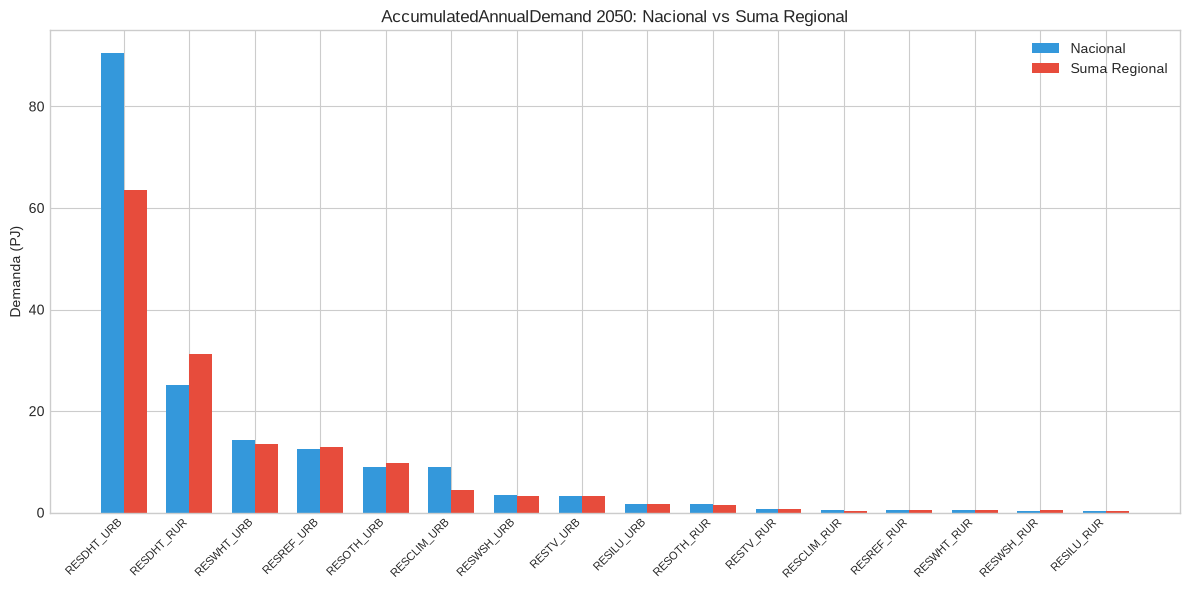

#### ResidualCapacity

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

1455 coincidencias | 1911 discrepancias (99 modos/variables) | 50 sin emparejar | **43.2% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2054,0.055931,56.560351,56.504420,aditivo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2053,0.064792,55.937673,55.872882,aditivo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2052,0.074750,55.279968,55.205218,aditivo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2051,0.085888,54.581323,54.495435,aditivo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2050,0.098281,53.833582,53.735302,aditivo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2049,0.111999,52.855913,52.743914,aditivo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2048,0.127106,51.753551,51.626445,aditivo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2047,0.143653,50.502165,50.358512,aditivo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2046,0.161680,49.077944,48.916265,aditivo
ResidualCapacity,DEMRESNGSCKN_MID_URB,DEMRESNGSCKN_MID_URB,2045,0.181210,47.444582,47.263373,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMRESBGSCKN_MID_RUR,Solo Nacional,TECHNOLOGY
DEMRESELCILU_INC_RUR,Solo Nacional,TECHNOLOGY
DEMRESELCILU_LFC_RUR,Solo Nacional,TECHNOLOGY
DEMRESELCOTH_HIG_RUR,Solo Nacional,TECHNOLOGY
DEMRESELCOTH_HIG_URB,Solo Nacional,TECHNOLOGY
DEMRESELCOTH_MID_RUR,Solo Nacional,TECHNOLOGY
DEMRESELCOTH_MID_URB,Solo Nacional,TECHNOLOGY
DEMRESNGSWHT_FOR_HIG_RUR,Solo Nacional,TECHNOLOGY
DEMRESNGSWHT_FOR_HIG_URB,Solo Nacional,TECHNOLOGY
DEMRESNGSWHT_FOR_LOW_RUR,Solo Nacional,TECHNOLOGY


**Comparacion 2050 (grafica):**

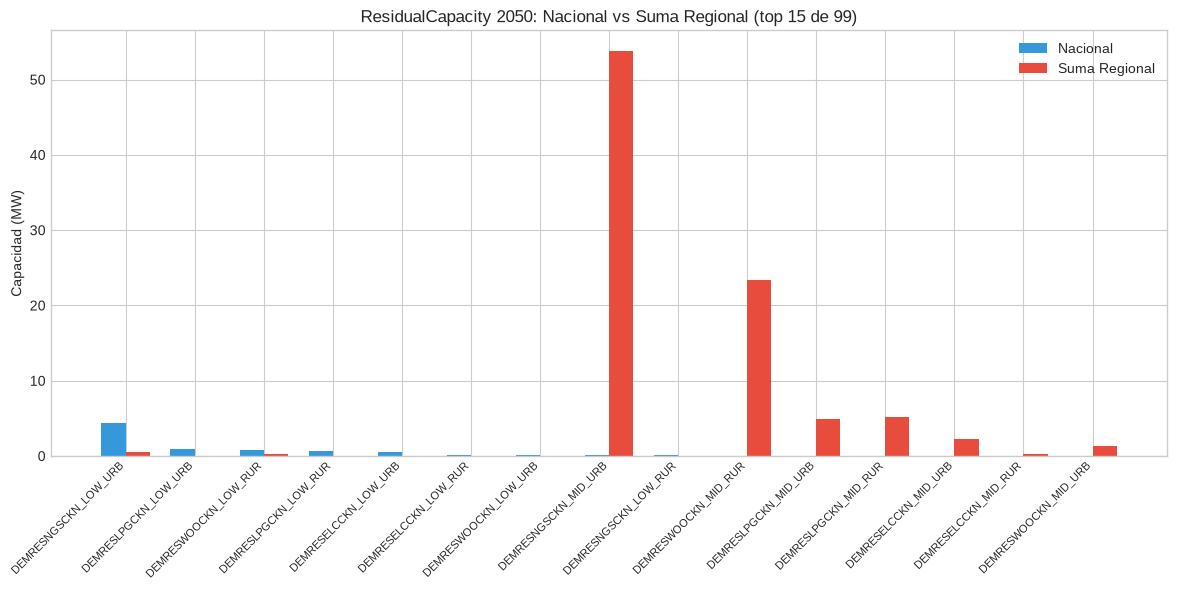

#### TotalAnnualMaxCapacityInvestment

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

0 coincidencias | 0 discrepancias (0 modos/variables) | 118 sin emparejar | **0% coincidencia**

_Sin discrepancias en comparaciones emparejadas._

**Variables sin emparejar:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2023,4.110000,18.570000,14.460000,no_aditivo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2024,4.110000,18.570000,14.460000,no_aditivo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2025,4.280000,18.570000,14.290000,no_aditivo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2026,4.450000,18.570000,14.120000,no_aditivo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2027,4.630000,18.570000,13.940000,no_aditivo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2028,4.820000,18.570000,13.750000,no_aditivo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2029,5.020000,18.570000,13.550000,no_aditivo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2030,5.220000,18.570000,13.350000,no_aditivo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2031,5.430000,18.570000,13.140000,no_aditivo
CapitalCost,DEMRESNGSWHT_FOR_LOW_RUR,DEMRESNGSWHT_FOR_LOW_RUR,2032,5.650000,18.570000,12.920000,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMRESZNIBGSCKN_MID,Solo Nacional,TECHNOLOGY
DEMRESZNIELCCKN_LOW,Solo Nacional,TECHNOLOGY
DEMRESZNIELC_LOW,Solo Nacional,TECHNOLOGY
DEMRESZNILPGCKN_MID,Solo Nacional,TECHNOLOGY
DEMRESZNIWOOCKN_LOW,Solo Nacional,TECHNOLOGY
BACKSTOP_RESCLIM,Solo Regional,TECHNOLOGY
BACKSTOP_RESCLIM_RUR,Solo Regional,TECHNOLOGY
BACKSTOP_RESCLIM_URB,Solo Regional,TECHNOLOGY
BACKSTOP_RESDHT,Solo Regional,TECHNOLOGY
BACKSTOP_RESDHT_RUR,Solo Regional,TECHNOLOGY


**Comparacion 2050 (grafica):**

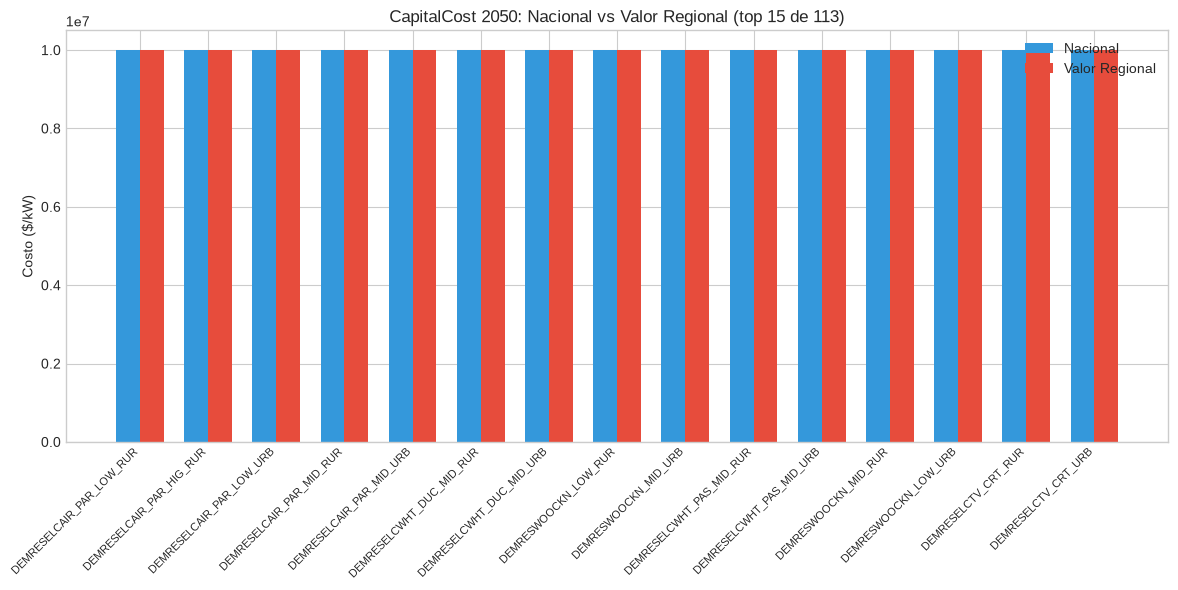

#### TotalTechnologyModelPeriodActivityUpperLimit

Dimension: **TECHNOLOGY** | Tipo: **no_aditivo**

0 coincidencias | 0 discrepancias (0 modos/variables) | 56 sin emparejar | **0% coincidencia**

_Sin discrepancias en comparaciones emparejadas._

**Variables sin emparejar:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
InputActivityRatio,DEMRESNGSCKN_MID_URB|NGS002|1.0,DEMRESNGSCKN_MID_URB,2041,1.818182,1.958000,0.139818,no_aditivo
InputActivityRatio,DEMRESNGSCKN_MID_URB|NGS002|1.0,DEMRESNGSCKN_MID_URB,2040,1.818182,1.958000,0.139818,no_aditivo
InputActivityRatio,DEMRESNGSCKN_MID_URB|NGS002|1.0,DEMRESNGSCKN_MID_URB,2039,1.818182,1.958000,0.139818,no_aditivo
InputActivityRatio,DEMRESNGSCKN_MID_URB|NGS002|1.0,DEMRESNGSCKN_MID_URB,2038,1.818182,1.958000,0.139818,no_aditivo
InputActivityRatio,DEMRESNGSCKN_MID_URB|NGS002|1.0,DEMRESNGSCKN_MID_URB,2037,1.818182,1.958000,0.139818,no_aditivo
InputActivityRatio,DEMRESNGSCKN_MID_URB|NGS002|1.0,DEMRESNGSCKN_MID_URB,2036,1.818182,1.958000,0.139818,no_aditivo
InputActivityRatio,DEMRESNGSCKN_MID_RUR|NGS002|1.0,DEMRESNGSCKN_MID_RUR,2035,1.818182,1.958000,0.139818,no_aditivo
InputActivityRatio,DEMRESNGSCKN_MID_RUR|NGS002|1.0,DEMRESNGSCKN_MID_RUR,2036,1.818182,1.958000,0.139818,no_aditivo
InputActivityRatio,DEMRESNGSCKN_MID_RUR|NGS002|1.0,DEMRESNGSCKN_MID_RUR,2037,1.818182,1.958000,0.139818,no_aditivo
InputActivityRatio,DEMRESNGSCKN_MID_RUR|NGS002|1.0,DEMRESNGSCKN_MID_RUR,2038,1.818182,1.958000,0.139818,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMRESELCAIR_PAR_HIG_RUR|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCAIR_PAR_LOW_RUR|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCAIR_PAR_LOW_URB|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCAIR_PAR_MID_RUR|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCAIR_PAR_MID_URB|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCAIR_POR_HIG_RUR|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCAIR_POR_HIG_URB|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCAIR_POR_LOW_RUR|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCAIR_POR_LOW_URB|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMRESELCAIR_POR_MID_RUR|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

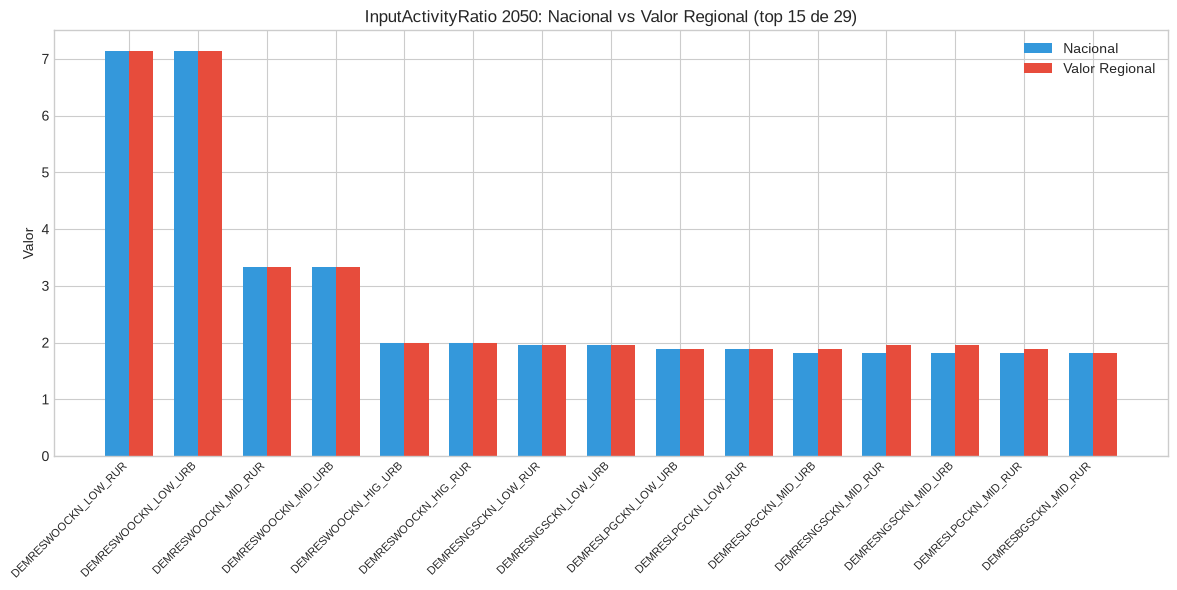

#### OutputActivityRatio

Dimension: **TECH+FUEL+MODE** | Tipo: **no_aditivo**

3762 coincidencias | 114 discrepancias (114 modos/variables) | 4414 sin emparejar | **97.1% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
OutputActivityRatio,DEMRESBGSCKN_MID_RUR|RESDHT_RUR|1.0,DEMRESBGSCKN_MID_RUR,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMRESELCAIR_PAR_HIG_RUR|RESCLIM_RUR|1.0,DEMRESELCAIR_PAR_HIG_RUR,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMRESELCAIR_PAR_LOW_RUR|RESCLIM_RUR|1.0,DEMRESELCAIR_PAR_LOW_RUR,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMRESELCAIR_PAR_LOW_URB|RESCLIM_URB|1.0,DEMRESELCAIR_PAR_LOW_URB,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMRESELCAIR_PAR_MID_RUR|RESCLIM_RUR|1.0,DEMRESELCAIR_PAR_MID_RUR,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMRESELCAIR_PAR_MID_URB|RESCLIM_URB|1.0,DEMRESELCAIR_PAR_MID_URB,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMRESELCAIR_POR_HIG_RUR|RESCLIM_RUR|1.0,DEMRESELCAIR_POR_HIG_RUR,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMRESELCAIR_POR_HIG_URB|RESCLIM_URB|1.0,DEMRESELCAIR_POR_HIG_URB,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMRESELCAIR_POR_LOW_RUR|RESCLIM_RUR|1.0,DEMRESELCAIR_POR_LOW_RUR,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMRESELCAIR_POR_LOW_URB|RESCLIM_URB|1.0,DEMRESELCAIR_POR_LOW_URB,2055,nan,1.000000,nan,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
BACKSTOP_1|RESDHT_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_1|RESELC_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_2|RESDHT_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_2|RESELC_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE
BBGDST|RESDHT_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE
BBGDST|RESELC_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE
DEMAGFELC|RESDHT_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE
DEMAGFELC|RESELC_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE
DEMCOQDSL|RESDHT_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE
DEMCOQDSL|RESELC_ZNI|1.0,Solo Nacional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

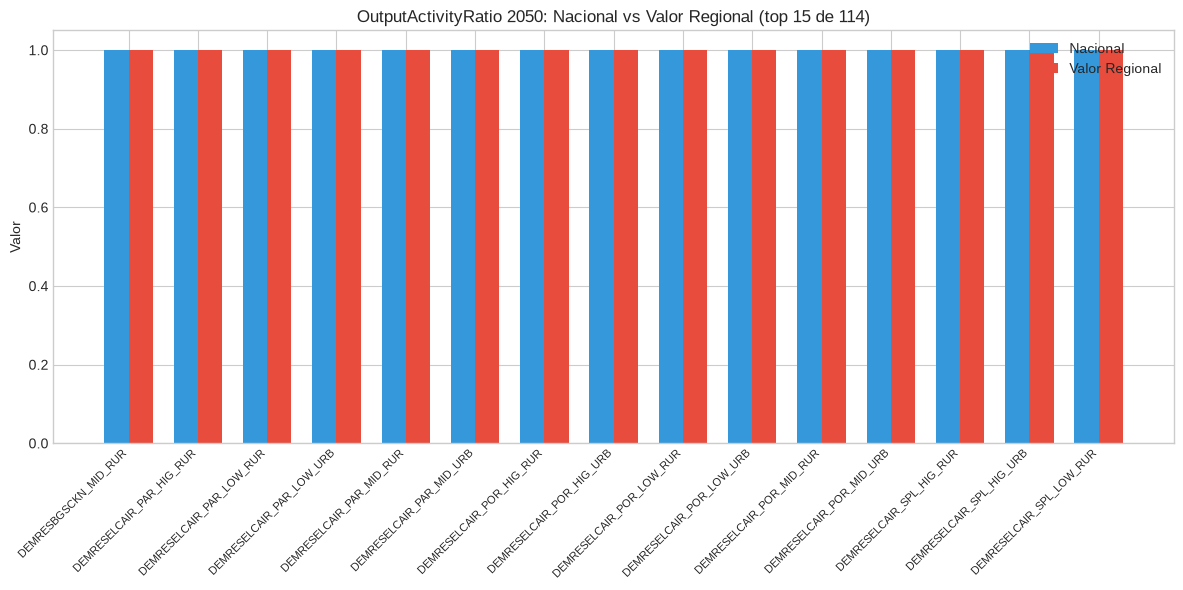

Excel validacion profunda exportado: /home/jchavez/Documentos/UPME/Datos Simulacion/output/07_validacion_profunda_RES.xlsx


In [21]:
# --- 7. Validacion profunda: Regional vs Nacional (Residencial) ---
display(Markdown("### 7.1 Analisis profundo: Regional vs Nacional (Residencial)"))
display(Markdown(
    "Validacion de **8 parametros** del sector residencial con emparejamiento por dimension correcta "
    "y reporte de variables sin equivalente en el otro archivo.\n\n"
    "| Parametro | Dimension | Tipo |\n"
    "|-----------|-----------|------|\n"
    "| AccumulatedAnnualDemand | FUEL | aditivo |\n"
    "| ResidualCapacity | TECHNOLOGY | aditivo |\n"
    "| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |\n"
    "| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |\n"
    "| CapitalCost | TECHNOLOGY | no aditivo |\n"
    "| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |\n"
    "| InputActivityRatio | TECH+FUEL+MODE | no aditivo |\n"
    "| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |"
))

PARAMS_RES = {
    "AccumulatedAnnualDemand": {"dim": "fuel", "tipo": "aditivo", "dim_label": "FUEL"},
    "ResidualCapacity": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalAnnualMaxCapacityInvestment": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyAnnualActivityUpperLimit": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "CapitalCost": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyModelPeriodActivityUpperLimit": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "InputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
    "OutputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
}


def is_res(row):
    tech = normalize_text(row.get("TECHNOLOGY")) or ""
    fuel = normalize_text(row.get("FUEL")) or ""
    return ("RES" in tech) or ("RES" in fuel)

mask_nac_res = df_nac.apply(is_res, axis=1).astype(bool)
mask_reg_res = df_reg.apply(is_res, axis=1).astype(bool)
nac_res = df_nac[mask_nac_res].copy()
reg_res = df_reg[mask_reg_res].copy()
nac_fuels_res = {normalize_text(f) for f in nac_res["FUEL"].dropna().unique() if "RES" in str(f)}

display(Markdown(f"- Filas Nacional (RES*): **{len(nac_res):,}** | Filas Regional (RES*): **{len(reg_res):,}**"))

anos_validar = [c for c in get_value_cols(nac_res) if c != TIME_INDEP_COL]
disc_res_rows = []
coinc_res_rows = []
sin_emparejar_res_rows = []


def _fuel_base(val):
    _, base = split_regional_name(val)
    return base


def _tech_base(val):
    _, base = split_regional_name(val)
    return base


def _mode_base(val):
    return normalize_text(val)


def _make_tfm_key(row):
    return (_tech_base(row["TECHNOLOGY"]), _fuel_base(row["FUEL"]), _mode_base(row["MODE_OF_OPERATION"]))


for param, cfg in PARAMS_RES.items():
    dim = cfg["dim"]
    tipo = cfg["tipo"]
    nac_p = nac_res[nac_res["Parameter"] == param].copy()
    reg_p = reg_res[reg_res["Parameter"] == param].copy()

    if dim == "fuel":
        nac_vars = sorted(nac_fuels_res)
        reg_vars = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_res_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_res_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for fuel in nac_vars:
            nac_rows = nac_p[nac_p["FUEL"].apply(_fuel_base) == fuel]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["FUEL"].apply(_fuel_base) == fuel]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_sum = reg_rows[anio].apply(safe_float).sum()
                diff = reg_sum - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": fuel,
                    "Descripcion": fuel,
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_sum,
                    "Diferencia": diff,
                    "Coincide": values_close(nac_val, reg_sum),
                    "Tipo": tipo,
                }
                (coinc_res_rows if row["Coincide"] else disc_res_rows).append(row)

    elif dim == "tech":
        nac_vars = sorted({_tech_base(t) for t in nac_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})
        reg_vars = sorted({_tech_base(t) for t in reg_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_res_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_res_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for tech in nac_vars:
            nac_rows = nac_p[nac_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                if tipo == "no_aditivo":
                    all_match = all(values_close(nac_val, v) for v in reg_vals)
                    reg_ref = reg_vals.iloc[0]
                    diff = reg_ref - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_ref,
                        "Diferencia": diff,
                        "Coincide": all_match,
                        "Tipo": tipo,
                        "Num_Regiones": len(reg_vals),
                    }
                else:
                    reg_sum = reg_vals.sum()
                    diff = reg_sum - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_sum,
                        "Diferencia": diff,
                        "Coincide": values_close(nac_val, reg_sum),
                        "Tipo": tipo,
                    }
                (coinc_res_rows if row["Coincide"] else disc_res_rows).append(row)

    elif dim == "tech_fuel_mode":
        nac_keys = {_make_tfm_key(r): r for _, r in nac_p.iterrows()}
        reg_keys = {}
        for _, r in reg_p.iterrows():
            key = _make_tfm_key(r)
            reg_keys.setdefault(key, []).append(r)

        nac_key_set = set(nac_keys)
        reg_key_set = set(reg_keys)

        for key in sorted(nac_key_set - reg_key_set):
            sin_emparejar_res_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Nacional",
                "Dimension": cfg["dim_label"],
            })
        for key in sorted(reg_key_set - nac_key_set):
            sin_emparejar_res_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Regional",
                "Dimension": cfg["dim_label"],
            })

        for key in sorted(nac_key_set & reg_key_set):
            nac_row = nac_keys[key]
            reg_rows = pd.DataFrame(reg_keys[key])
            tech, fuel, mode = key

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                all_match = all(values_close(nac_val, v) for v in reg_vals)
                reg_ref = reg_vals.iloc[0]
                diff = reg_ref - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": f"{tech}|{fuel}|{mode}",
                    "Descripcion": tech,
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_ref,
                    "Diferencia": diff,
                    "Coincide": all_match,
                    "Tipo": tipo,
                    "Num_Regiones": len(reg_vals),
                }
                (coinc_res_rows if row["Coincide"] else disc_res_rows).append(row)

# DataFrames de resultados
df_disc_res = pd.DataFrame(disc_res_rows)
df_coinc_res = pd.DataFrame(coinc_res_rows)
df_sin_emparejar_res = pd.DataFrame(sin_emparejar_res_rows)

if not df_disc_res.empty:
    df_disc_res["Abs_Diff"] = df_disc_res["Diferencia"].abs()
    df_disc_res["Suma_Regional"] = df_disc_res["Valor_Regional"]


def _resumir_discrepancias(df_p_disc: pd.DataFrame, df_p_coinc: pd.DataFrame) -> pd.DataFrame:
    """Agrupa discrepancias por Parameter+Modo e indica cuantos anos fallan (o 'todos')."""
    if df_p_disc.empty:
        return pd.DataFrame()

    resumen_rows = []
    for (param, modo), group in df_p_disc.groupby(["Parameter", "Modo"], sort=True):
        disc_anios = {str(a) for a in group["Anio"].dropna().unique()}
        if not df_p_coinc.empty:
            coinc_group = df_p_coinc[
                (df_p_coinc["Parameter"] == param) & (df_p_coinc["Modo"] == modo)
            ]
            coinc_anios = {str(a) for a in coinc_group["Anio"].dropna().unique()}
            total_anios = len(disc_anios | coinc_anios)
        else:
            total_anios = len(disc_anios)

        n_disc_anios = len(disc_anios)
        anios_label = "todos" if n_disc_anios == total_anios and total_anios > 0 else str(n_disc_anios)

        resumen_rows.append({
            "Parameter": param,
            "Modo": modo,
            "Descripcion": group["Descripcion"].iloc[0],
            "Tipo": group["Tipo"].iloc[0] if "Tipo" in group.columns else "",
            "Anios_Discrepancia": anios_label,
            "Total_Anios": total_anios,
            "Max_Diferencia": group["Abs_Diff"].max(),
        })

    return pd.DataFrame(resumen_rows).sort_values("Max_Diferencia", ascending=False)


def _plot_comparacion_2050(
    df_p_disc: pd.DataFrame,
    df_p_coinc: pd.DataFrame,
    param: str,
    cfg: dict,
    max_bars: int = 15,
) -> None:
    """Grafica de barras 2050: Nacional vs Regional (suma o valor segun tipo)."""
    frames = [f for f in [df_p_disc, df_p_coinc] if not f.empty]
    if not frames:
        return

    all_data = pd.concat(frames, ignore_index=True)
    data_2050 = all_data[all_data["Anio"] == "2050"].copy()
    if data_2050.empty:
        return

    data_2050 = data_2050.drop_duplicates(subset=["Modo"], keep="first")
    n_total = len(data_2050)

    if not df_p_disc.empty:
        disc_2050 = df_p_disc[df_p_disc["Anio"] == "2050"].copy()
        if not disc_2050.empty:
            disc_2050["Abs_Diff"] = disc_2050["Diferencia"].abs()
            disc_modos = disc_2050.sort_values("Abs_Diff", ascending=False)["Modo"].tolist()
            priority = data_2050[data_2050["Modo"].isin(disc_modos)].set_index("Modo").loc[disc_modos].reset_index()
            rest = data_2050[~data_2050["Modo"].isin(disc_modos)]
            data_2050 = pd.concat([priority, rest], ignore_index=True)

    data_2050 = data_2050.sort_values("Nacional", ascending=False, na_position="last")
    data_plot = data_2050.head(max_bars)

    tipo = cfg["tipo"]
    reg_label = "Suma Regional" if tipo == "aditivo" else "Valor Regional"
    ylabels = {
        "AccumulatedAnnualDemand": "Demanda (PJ)",
        "ResidualCapacity": "Capacidad (MW)",
        "CapitalCost": "Costo ($/kW)",
    }
    ylabel = ylabels.get(param, "Valor")

    labels = []
    for _, row in data_plot.iterrows():
        modo = row["Modo"]
        if param == "AccumulatedAnnualDemand":
            labels.append(modo)
        else:
            desc = row.get("Descripcion", modo)
            text = str(desc if pd.notna(desc) else modo)
            labels.append(text if len(text) <= 28 else text[:25] + "...")

    fig_w = max(12, len(data_plot) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    x = np.arange(len(data_plot))
    w = 0.35
    ax.bar(x - w / 2, data_plot["Nacional"].fillna(0), w, label="Nacional", color="#3498db")
    ax.bar(x + w / 2, data_plot["Valor_Regional"].fillna(0), w, label=reg_label, color="#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    suffix = f" (top {len(data_plot)} de {n_total})" if n_total > max_bars else ""
    ax.set_title(f"{param} 2050: Nacional vs {reg_label}{suffix}")
    ax.legend()
    plt.tight_layout()
    plt.show()


cols_disc_resumen = ["Parameter", "Modo", "Descripcion", "Tipo", "Anios_Discrepancia", "Total_Anios", "Max_Diferencia"]
cols_disc = ["Parameter", "Modo", "Descripcion", "Anio", "Nacional", "Valor_Regional", "Diferencia", "Tipo"]

# --- Resumen global ---
n_coinc = len(coinc_res_rows)
n_disc = len(disc_res_rows)
n_sin = len(sin_emparejar_res_rows)
pct_global = round(100 * n_coinc / (n_coinc + n_disc), 1) if (n_coinc + n_disc) > 0 else 100

display(Markdown(
    f"**Resultado global:** {n_coinc} coincidencias | {n_disc} discrepancias | "
    f"{n_sin} variables sin emparejar | **{pct_global}% coincidencia**"
))

resumen_param_rows = []
for param, cfg in PARAMS_RES.items():
    n_c = sum(1 for r in coinc_res_rows if r["Parameter"] == param)
    n_d = sum(1 for r in disc_res_rows if r["Parameter"] == param)
    n_s = sum(1 for r in sin_emparejar_res_rows if r["Parameter"] == param)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)
    resumen_param_rows.append({
        "Parameter": param,
        "Dimension": cfg["dim_label"],
        "Tipo_Validacion": cfg["tipo"],
        "Coincidencias": n_c,
        "Discrepancias": n_d,
        "Sin_Emparejar": n_s,
        "Pct_Coincidencia": pct_p,
    })

df_resumen_param_res = pd.DataFrame(resumen_param_rows)
display(Markdown("**Resumen por parametro:**"))
show_df(df_resumen_param_res)

# Resumen global de discrepancias por Parameter + Modo
if not df_disc_res.empty:
    df_disc_resumen_global = _resumir_discrepancias(df_disc_res, df_coinc_res)
    display(Markdown("**Resumen global de discrepancias (por variable):**"))
    display(Markdown(
        "Cada fila indica cuantos años tienen discrepancia para ese Parameter+Modo. "
        "Si falla en todos los años comparados, muestra **todos**."
    ))
    show_df(df_disc_resumen_global[cols_disc_resumen], max_rows=100)

# --- Reporte de FUELs renombrados (InputActivityRatio / OutputActivityRatio) ---
display(Markdown("#### FUELs sin equivalencia exacta (InputActivityRatio / OutputActivityRatio)"))
display(Markdown(
    "Combustibles que existen en un archivo pero no en el otro (sin mapeo manual). "
    "Esto explica parte de las variables sin emparejar."
))

for param_report in ["InputActivityRatio", "OutputActivityRatio"]:
    nac_p = nac_res[nac_res["Parameter"] == param_report]
    reg_p = reg_res[reg_res["Parameter"] == param_report]
    nac_fuels = sorted({_fuel_base(f) for f in nac_p["FUEL"].dropna().unique() if _fuel_base(f)})
    reg_fuels = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})
    solo_nac = sorted(set(nac_fuels) - set(reg_fuels))
    solo_reg = sorted(set(reg_fuels) - set(nac_fuels))
    comunes = sorted(set(nac_fuels) & set(reg_fuels))

    display(Markdown(f"**{param_report}** — {len(comunes)} FUELs en ambos | {len(solo_nac)} solo NAC | {len(solo_reg)} solo REG"))
    if solo_nac:
        display(Markdown(f"- Solo Nacional: `{', '.join(solo_nac)}`"))
    if solo_reg:
        display(Markdown(f"- Solo Regional: `{', '.join(solo_reg)}`"))

# --- Detalle por parametro ---
disc_resumen_all = []

for param, cfg in PARAMS_RES.items():
    display(Markdown(f"#### {param}"))
    display(Markdown(f"Dimension: **{cfg['dim_label']}** | Tipo: **{cfg['tipo']}**"))

    df_p_disc = df_disc_res[df_disc_res["Parameter"] == param] if not df_disc_res.empty else pd.DataFrame()
    df_p_coinc = df_coinc_res[df_coinc_res["Parameter"] == param] if not df_coinc_res.empty else pd.DataFrame()
    df_p_sin = df_sin_emparejar_res[df_sin_emparejar_res["Parameter"] == param] if not df_sin_emparejar_res.empty else pd.DataFrame()

    n_c = len(df_p_coinc)
    n_d = len(df_p_disc)
    n_modos_disc = df_p_disc[["Parameter", "Modo"]].drop_duplicates().shape[0] if not df_p_disc.empty else 0
    n_s = len(df_p_sin)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)

    display(Markdown(
        f"{n_c} coincidencias | {n_d} discrepancias ({n_modos_disc} modos/variables) | "
        f"{n_s} sin emparejar | **{pct_p}% coincidencia**"
    ))

    if not df_p_disc.empty:
        df_p_disc_resumen = _resumir_discrepancias(df_p_disc, df_p_coinc)
        disc_resumen_all.append(df_p_disc_resumen)
        display(Markdown("**Discrepancias (resumen por variable):**"))
        display(Markdown(
            "Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años."
        ))
        show_df(df_p_disc_resumen[cols_disc_resumen], max_rows=50)

        display(Markdown("**Discrepancias (detalle por año):**"))
        show_df(df_p_disc.sort_values("Abs_Diff", ascending=False)[cols_disc], max_rows=50)
    else:
        display(Markdown("_Sin discrepancias en comparaciones emparejadas._"))

    if not df_p_sin.empty:
        display(Markdown("**Variables sin emparejar:**"))
        show_df(df_p_sin[["Variable", "Lado", "Dimension"]], max_rows=30)

    if not df_p_coinc.empty or not df_p_disc.empty:
        max_bars = 30 if param == "AccumulatedAnnualDemand" else 15
        display(Markdown(f"**Comparacion 2050 (grafica):**"))
        _plot_comparacion_2050(df_p_disc, df_p_coinc, param, cfg, max_bars=max_bars)
    elif df_p_sin.empty:
        display(Markdown("_Sin datos emparejados para graficar._"))

df_disc_resumen_res = (
    pd.concat(disc_resumen_all, ignore_index=True)
    if disc_resumen_all
    else pd.DataFrame()
)

# Exportar resultados de validacion profunda
output_validacion_res = OUTPUT_DIR / "07_validacion_profunda_RES.xlsx"
with pd.ExcelWriter(output_validacion_res, engine="openpyxl") as writer:
    df_resumen_param_res.to_excel(writer, sheet_name="Resumen", index=False)
    if not df_disc_resumen_res.empty:
        df_disc_resumen_res.to_excel(writer, sheet_name="Discrepancias_Resumen", index=False)
    if not df_disc_res.empty:
        df_disc_res.to_excel(writer, sheet_name="Discrepancias_Detalle", index=False)
    if not df_coinc_res.empty:
        df_coinc_res.to_excel(writer, sheet_name="Coincidencias", index=False)
    if not df_sin_emparejar_res.empty:
        df_sin_emparejar_res.to_excel(writer, sheet_name="Sin_Emparejar", index=False)
print(f"Excel validacion profunda exportado: {output_validacion_res}")

validacion_profunda_res = {
    "Sector": "RES",
    "Filas_Nacional": len(nac_res),
    "Filas_Regional": len(reg_res),
    "Coincidencias": n_coinc,
    "Discrepancias": n_disc,
    "Sin_Emparejar": n_sin,
    "Pct_Coincidencia": pct_global,
    "Excel": "07_validacion_profunda_RES.xlsx",
    "df_resumen_param": df_resumen_param_res,
}


---
## 8. Validacion profunda — Sector Terciario (TER*)

Validacion de los mismos 8 parametros que en 5.3, filtrando filas con **TER** en TECHNOLOGY o FUEL.


### 8.1 Analisis profundo: Regional vs Nacional (Terciario)

Validacion de **8 parametros** del sector terciario con emparejamiento por dimension correcta y reporte de variables sin equivalente en el otro archivo.

| Parametro | Dimension | Tipo |
|-----------|-----------|------|
| AccumulatedAnnualDemand | FUEL | aditivo |
| ResidualCapacity | TECHNOLOGY | aditivo |
| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |
| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |
| CapitalCost | TECHNOLOGY | no aditivo |
| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |
| InputActivityRatio | TECH+FUEL+MODE | no aditivo |
| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |

- Filas Nacional (TER*): **8,604** | Filas Regional (TER*): **3,814**

**Resultado global:** 4328 coincidencias | 602 discrepancias | 2740 variables sin emparejar | **87.8% coincidencia**

**Resumen por parametro:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
AccumulatedAnnualDemand,TERCLIM_CEN,TERCLIM_CEN,2055,nan,40.287000,nan,aditivo
AccumulatedAnnualDemand,TERCLIM_FAN,TERCLIM_FAN,2055,nan,1.305000,nan,aditivo
AccumulatedAnnualDemand,TERCLIM_SPL,TERCLIM_SPL,2055,nan,4.430000,nan,aditivo
AccumulatedAnnualDemand,TERDHT,TERDHT,2055,nan,50.939000,nan,aditivo
AccumulatedAnnualDemand,TERIHT,TERIHT,2055,nan,3.549000,nan,aditivo
AccumulatedAnnualDemand,TERILU,TERILU,2055,nan,5.047000,nan,aditivo
AccumulatedAnnualDemand,TERMPW,TERMPW,2055,nan,4.623000,nan,aditivo
AccumulatedAnnualDemand,TEROTH,TEROTH,2055,nan,25.418000,nan,aditivo
AccumulatedAnnualDemand,TERREF_AUC,TERREF_AUC,2055,nan,3.123000,nan,aditivo
AccumulatedAnnualDemand,TERREF_CEN,TERREF_CEN,2055,nan,4.958000,nan,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
TERDATA,Solo Nacional,FUEL


**Comparacion 2050 (grafica):**

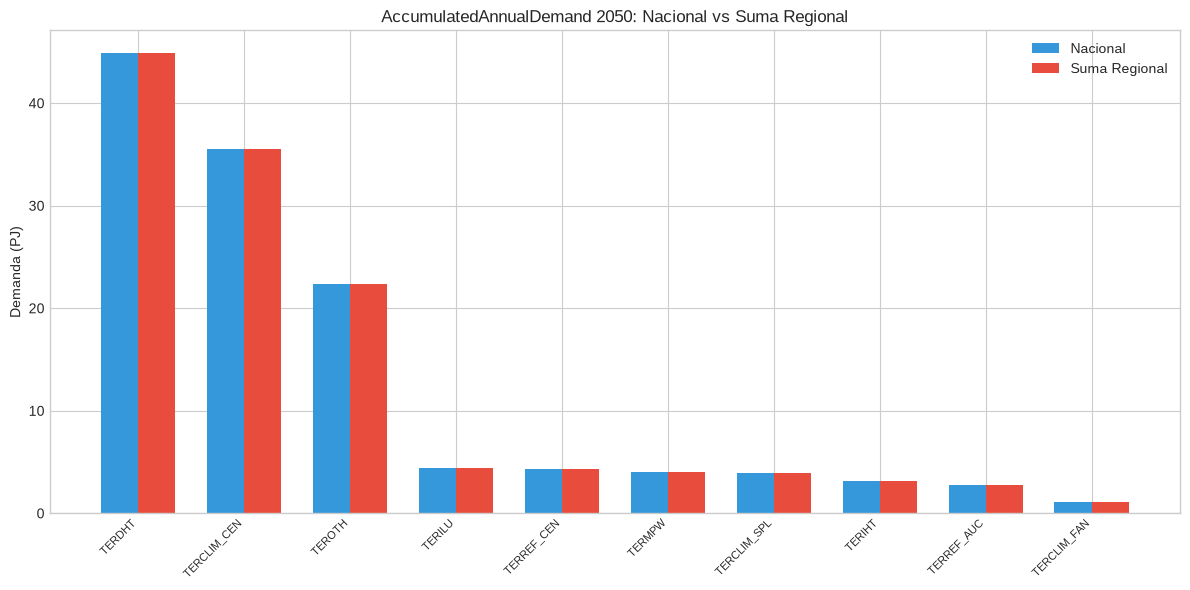

#### ResidualCapacity

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

1386 coincidencias | 76 discrepancias (43 modos/variables) | 0 sin emparejar | **94.8% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

Parameter,Modo,Descripcion,Tipo,Anios_Discrepancia,Total_Anios,Max_Diferencia
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,aditivo,todos,34,16.049887
ResidualCapacity,DEMTERBGSCKN_HIG,DEMTERBGSCKN_HIG,aditivo,1,34,nan
ResidualCapacity,DEMTERBGSCKN_LOW,DEMTERBGSCKN_LOW,aditivo,1,34,nan
ResidualCapacity,DEMTERBGSCKN_MID,DEMTERBGSCKN_MID,aditivo,1,34,nan
ResidualCapacity,DEMTERELCACL_HIG,DEMTERELCACL_HIG,aditivo,1,34,nan
ResidualCapacity,DEMTERELCACL_LOW,DEMTERELCACL_LOW,aditivo,1,34,nan
ResidualCapacity,DEMTERELCACL_MID,DEMTERELCACL_MID,aditivo,1,34,nan
ResidualCapacity,DEMTERELCAIR_CEN_HIG,DEMTERELCAIR_CEN_HIG,aditivo,1,34,nan
ResidualCapacity,DEMTERELCAIR_CEN_LOW,DEMTERELCAIR_CEN_LOW,aditivo,1,34,nan
ResidualCapacity,DEMTERELCAIR_CEN_MID,DEMTERELCAIR_CEN_MID,aditivo,1,34,nan


**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2027,16.049887,0.000000,-16.049887,aditivo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2026,16.052959,0.005003,-16.047956,aditivo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2028,16.043923,0.000000,-16.043923,aditivo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2029,16.033389,0.000000,-16.033389,aditivo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2030,16.016058,0.000000,-16.016058,aditivo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2031,15.989090,0.000000,-15.989090,aditivo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2032,15.948969,0.000000,-15.948969,aditivo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2033,15.891459,0.000000,-15.891459,aditivo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2034,15.811575,0.000000,-15.811575,aditivo
ResidualCapacity,DEMTERNGSCKN_LOW,DEMTERNGSCKN_LOW,2035,15.703587,0.000000,-15.703587,aditivo


**Comparacion 2050 (grafica):**

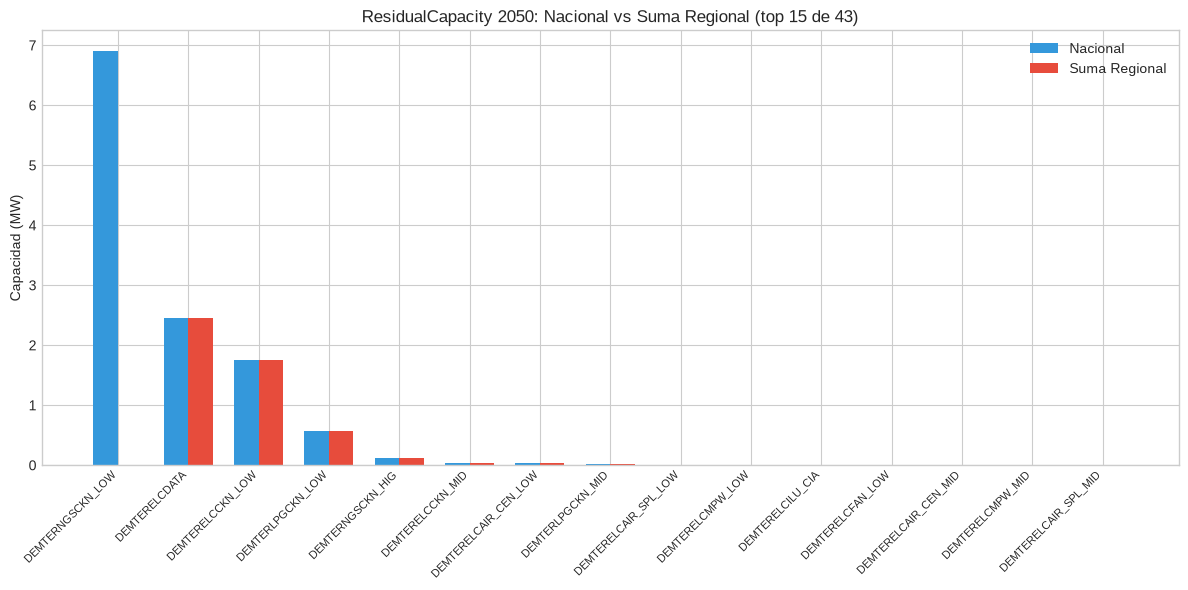

#### TotalAnnualMaxCapacityInvestment

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

0 coincidencias | 0 discrepancias (0 modos/variables) | 43 sin emparejar | **0% coincidencia**

_Sin discrepancias en comparaciones emparejadas._

**Variables sin emparejar:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
CapitalCost,DEMTERBGSCKN_MID,DEMTERBGSCKN_MID,2054,0.000000,50.000000,50.000000,no_aditivo
CapitalCost,DEMTERBGSCKN_MID,DEMTERBGSCKN_MID,2053,0.000000,50.000000,50.000000,no_aditivo
CapitalCost,DEMTERBGSCKN_MID,DEMTERBGSCKN_MID,2052,0.000000,50.000000,50.000000,no_aditivo
CapitalCost,DEMTERBGSCKN_HIG,DEMTERBGSCKN_HIG,2053,0.000000,50.000000,50.000000,no_aditivo
CapitalCost,DEMTERBGSCKN_HIG,DEMTERBGSCKN_HIG,2052,0.000000,50.000000,50.000000,no_aditivo
CapitalCost,DEMTERBGSCKN_HIG,DEMTERBGSCKN_HIG,2051,0.000000,50.000000,50.000000,no_aditivo
CapitalCost,DEMTERBGSCKN_HIG,DEMTERBGSCKN_HIG,2050,0.000000,50.000000,50.000000,no_aditivo
CapitalCost,DEMTERBGSCKN_HIG,DEMTERBGSCKN_HIG,2049,0.000000,50.000000,50.000000,no_aditivo
CapitalCost,DEMTERBGSCKN_HIG,DEMTERBGSCKN_HIG,2048,0.000000,50.000000,50.000000,no_aditivo
CapitalCost,DEMTERBGSCKN_HIG,DEMTERBGSCKN_HIG,2047,0.000000,50.000000,50.000000,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMTERELCILU_CIA,Solo Nacional,TECHNOLOGY
DEMTERELCILU_HAL,Solo Nacional,TECHNOLOGY
BACKSTOP_TERCLIM_CEN,Solo Regional,TECHNOLOGY
BACKSTOP_TERCLIM_FAN,Solo Regional,TECHNOLOGY
BACKSTOP_TERCLIM_SPL,Solo Regional,TECHNOLOGY
BACKSTOP_TERDHT,Solo Regional,TECHNOLOGY
BACKSTOP_TERIHT,Solo Regional,TECHNOLOGY
BACKSTOP_TERILU,Solo Regional,TECHNOLOGY
BACKSTOP_TERMPW,Solo Regional,TECHNOLOGY
BACKSTOP_TEROTH,Solo Regional,TECHNOLOGY


**Comparacion 2050 (grafica):**

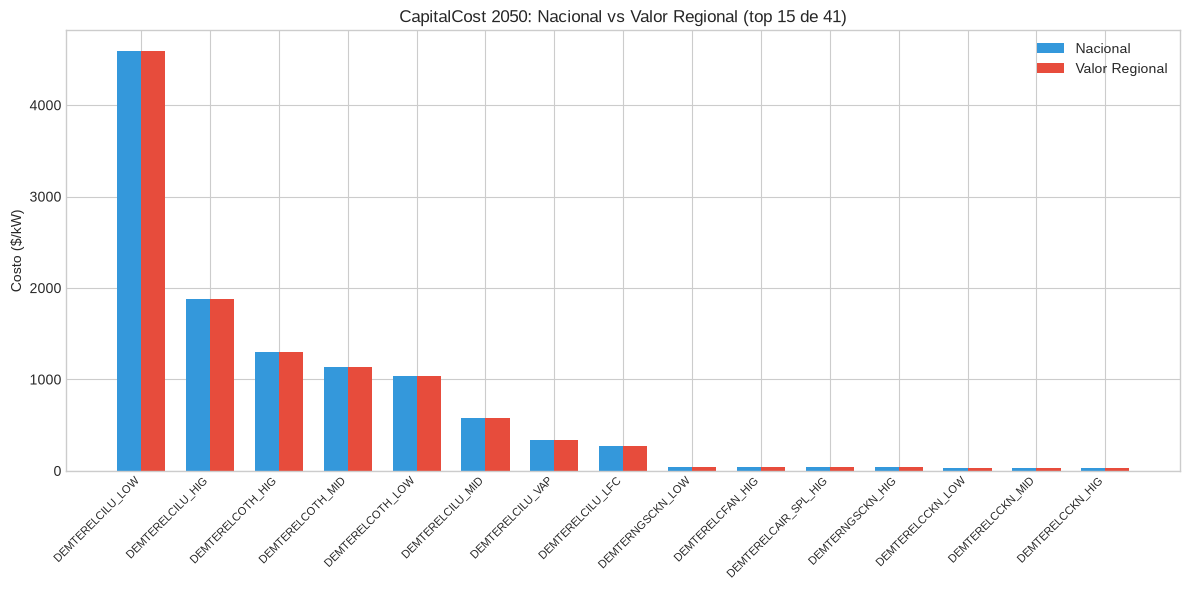

#### TotalTechnologyModelPeriodActivityUpperLimit

Dimension: **TECHNOLOGY** | Tipo: **no_aditivo**

0 coincidencias | 0 discrepancias (0 modos/variables) | 11 sin emparejar | **0% coincidencia**

_Sin discrepancias en comparaciones emparejadas._

**Variables sin emparejar:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2053,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2055,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2052,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2051,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2046,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2045,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2047,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2054,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2050,1.886792,2.616000,0.729208,no_aditivo
InputActivityRatio,DEMTERLPGCKN_MID|LPG002|1.0,DEMTERLPGCKN_MID,2049,1.886792,2.616000,0.729208,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMTERELCACL_HIG|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTERELCACL_LOW|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTERELCACL_MID|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTERELCAIR_CEN_HIG|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTERELCAIR_CEN_LOW|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTERELCAIR_CEN_MID|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTERELCAIR_SPL_HIG|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTERELCAIR_SPL_LOW|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTERELCAIR_SPL_MID|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMTERELCCKN_HIG|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

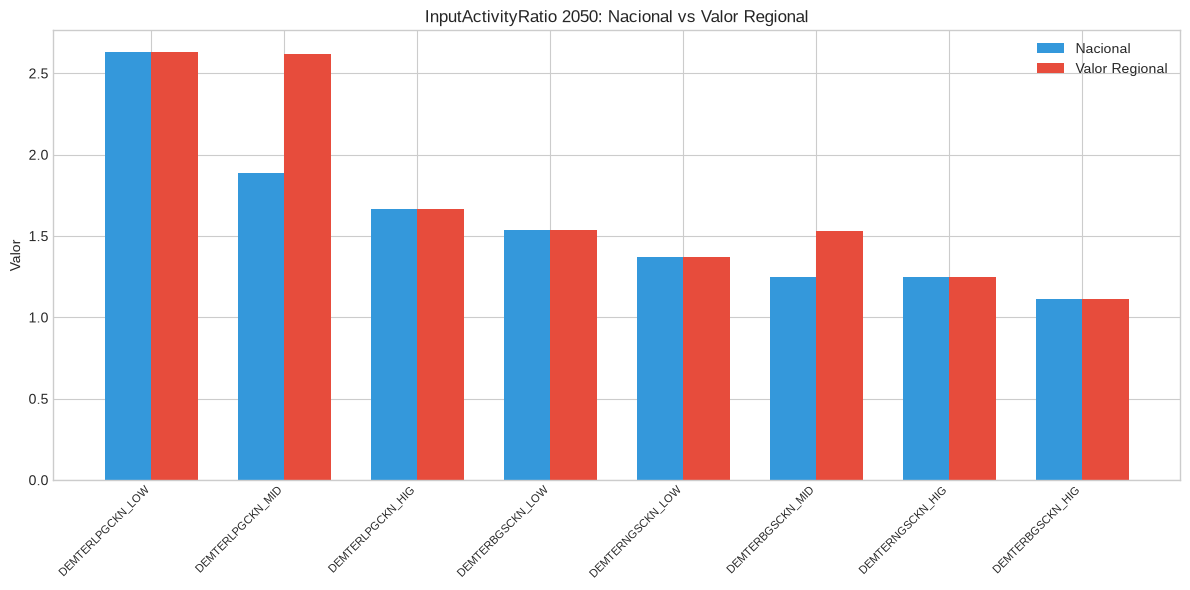

#### OutputActivityRatio

Dimension: **TECH+FUEL+MODE** | Tipo: **no_aditivo**

1419 coincidencias | 43 discrepancias (43 modos/variables) | 2558 sin emparejar | **97.1% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
OutputActivityRatio,DEMTERBGSCKN_HIG|TERDHT|1.0,DEMTERBGSCKN_HIG,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTERBGSCKN_LOW|TERDHT|1.0,DEMTERBGSCKN_LOW,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTERBGSCKN_MID|TERDHT|1.0,DEMTERBGSCKN_MID,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTERELCACL_HIG|TERIHT|1.0,DEMTERELCACL_HIG,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTERELCACL_LOW|TERIHT|1.0,DEMTERELCACL_LOW,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTERELCACL_MID|TERIHT|1.0,DEMTERELCACL_MID,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTERELCAIR_CEN_HIG|TERCLIM_CEN|1.0,DEMTERELCAIR_CEN_HIG,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTERELCAIR_CEN_LOW|TERCLIM_CEN|1.0,DEMTERELCAIR_CEN_LOW,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTERELCAIR_CEN_MID|TERCLIM_CEN|1.0,DEMTERELCAIR_CEN_MID,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMTERELCAIR_SPL_HIG|TERCLIM_SPL|1.0,DEMTERELCAIR_SPL_HIG,2055,nan,1.000000,nan,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
BACKSTOP_1|TERDHT|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_1|TERIHT|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_1|TERILU|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_1|TERMPW|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_1|TEROTH|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_2|TERDHT|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_2|TERIHT|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_2|TERILU|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_2|TERMPW|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_2|TEROTH|1.0,Solo Nacional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

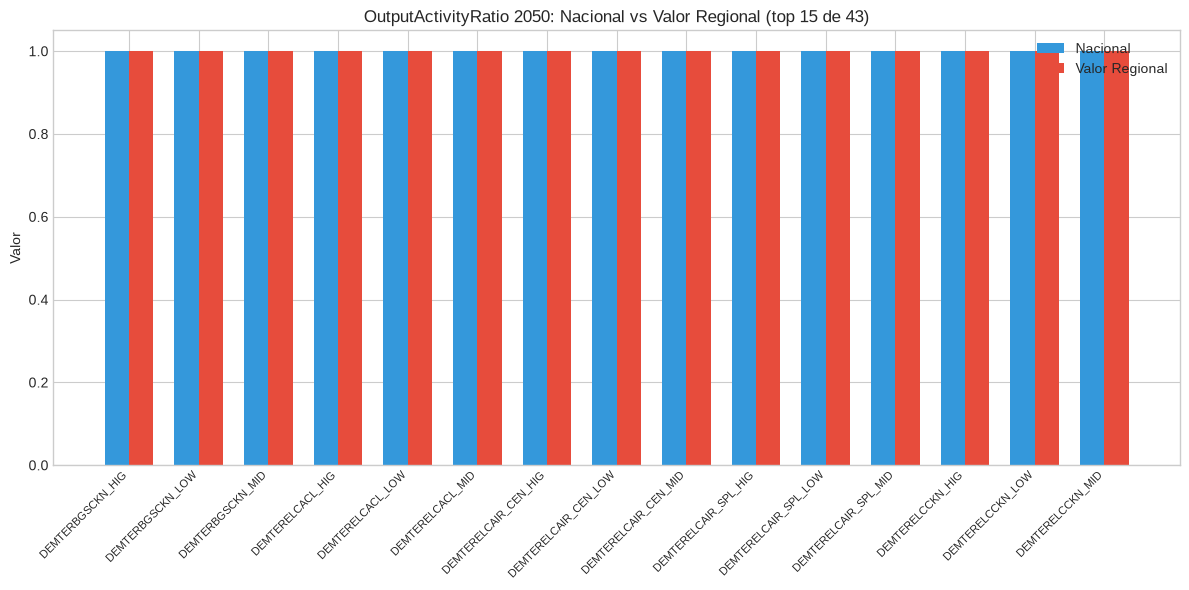

Excel validacion profunda exportado: /home/jchavez/Documentos/UPME/Datos Simulacion/output/08_validacion_profunda_TER.xlsx


In [22]:
# --- 8. Validacion profunda: Regional vs Nacional (Terciario) ---
display(Markdown("### 8.1 Analisis profundo: Regional vs Nacional (Terciario)"))
display(Markdown(
    "Validacion de **8 parametros** del sector terciario con emparejamiento por dimension correcta "
    "y reporte de variables sin equivalente en el otro archivo.\n\n"
    "| Parametro | Dimension | Tipo |\n"
    "|-----------|-----------|------|\n"
    "| AccumulatedAnnualDemand | FUEL | aditivo |\n"
    "| ResidualCapacity | TECHNOLOGY | aditivo |\n"
    "| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |\n"
    "| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |\n"
    "| CapitalCost | TECHNOLOGY | no aditivo |\n"
    "| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |\n"
    "| InputActivityRatio | TECH+FUEL+MODE | no aditivo |\n"
    "| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |"
))

PARAMS_TER = {
    "AccumulatedAnnualDemand": {"dim": "fuel", "tipo": "aditivo", "dim_label": "FUEL"},
    "ResidualCapacity": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalAnnualMaxCapacityInvestment": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyAnnualActivityUpperLimit": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "CapitalCost": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyModelPeriodActivityUpperLimit": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "InputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
    "OutputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
}


def is_ter(row):
    tech = normalize_text(row.get("TECHNOLOGY")) or ""
    fuel = normalize_text(row.get("FUEL")) or ""
    return ("TER" in tech) or ("TER" in fuel)

mask_nac_ter = df_nac.apply(is_ter, axis=1).astype(bool)
mask_reg_ter = df_reg.apply(is_ter, axis=1).astype(bool)
nac_ter = df_nac[mask_nac_ter].copy()
reg_ter = df_reg[mask_reg_ter].copy()
nac_fuels_ter = {normalize_text(f) for f in nac_ter["FUEL"].dropna().unique() if "TER" in str(f)}

display(Markdown(f"- Filas Nacional (TER*): **{len(nac_ter):,}** | Filas Regional (TER*): **{len(reg_ter):,}**"))

anos_validar = [c for c in get_value_cols(nac_ter) if c != TIME_INDEP_COL]
disc_ter_rows = []
coinc_ter_rows = []
sin_emparejar_ter_rows = []


def _fuel_base(val):
    _, base = split_regional_name(val)
    return base


def _tech_base(val):
    _, base = split_regional_name(val)
    return base


def _mode_base(val):
    return normalize_text(val)


def _make_tfm_key(row):
    return (_tech_base(row["TECHNOLOGY"]), _fuel_base(row["FUEL"]), _mode_base(row["MODE_OF_OPERATION"]))


for param, cfg in PARAMS_TER.items():
    dim = cfg["dim"]
    tipo = cfg["tipo"]
    nac_p = nac_ter[nac_ter["Parameter"] == param].copy()
    reg_p = reg_ter[reg_ter["Parameter"] == param].copy()

    if dim == "fuel":
        nac_vars = sorted(nac_fuels_ter)
        reg_vars = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_ter_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_ter_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for fuel in nac_vars:
            nac_rows = nac_p[nac_p["FUEL"].apply(_fuel_base) == fuel]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["FUEL"].apply(_fuel_base) == fuel]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_sum = reg_rows[anio].apply(safe_float).sum()
                diff = reg_sum - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": fuel,
                    "Descripcion": fuel,
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_sum,
                    "Diferencia": diff,
                    "Coincide": values_close(nac_val, reg_sum),
                    "Tipo": tipo,
                }
                (coinc_ter_rows if row["Coincide"] else disc_ter_rows).append(row)

    elif dim == "tech":
        nac_vars = sorted({_tech_base(t) for t in nac_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})
        reg_vars = sorted({_tech_base(t) for t in reg_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_ter_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_ter_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for tech in nac_vars:
            nac_rows = nac_p[nac_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                if tipo == "no_aditivo":
                    all_match = all(values_close(nac_val, v) for v in reg_vals)
                    reg_ref = reg_vals.iloc[0]
                    diff = reg_ref - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_ref,
                        "Diferencia": diff,
                        "Coincide": all_match,
                        "Tipo": tipo,
                        "Num_Regiones": len(reg_vals),
                    }
                else:
                    reg_sum = reg_vals.sum()
                    diff = reg_sum - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_sum,
                        "Diferencia": diff,
                        "Coincide": values_close(nac_val, reg_sum),
                        "Tipo": tipo,
                    }
                (coinc_ter_rows if row["Coincide"] else disc_ter_rows).append(row)

    elif dim == "tech_fuel_mode":
        nac_keys = {_make_tfm_key(r): r for _, r in nac_p.iterrows()}
        reg_keys = {}
        for _, r in reg_p.iterrows():
            key = _make_tfm_key(r)
            reg_keys.setdefault(key, []).append(r)

        nac_key_set = set(nac_keys)
        reg_key_set = set(reg_keys)

        for key in sorted(nac_key_set - reg_key_set):
            sin_emparejar_ter_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Nacional",
                "Dimension": cfg["dim_label"],
            })
        for key in sorted(reg_key_set - nac_key_set):
            sin_emparejar_ter_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Regional",
                "Dimension": cfg["dim_label"],
            })

        for key in sorted(nac_key_set & reg_key_set):
            nac_row = nac_keys[key]
            reg_rows = pd.DataFrame(reg_keys[key])
            tech, fuel, mode = key

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                all_match = all(values_close(nac_val, v) for v in reg_vals)
                reg_ref = reg_vals.iloc[0]
                diff = reg_ref - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": f"{tech}|{fuel}|{mode}",
                    "Descripcion": tech,
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_ref,
                    "Diferencia": diff,
                    "Coincide": all_match,
                    "Tipo": tipo,
                    "Num_Regiones": len(reg_vals),
                }
                (coinc_ter_rows if row["Coincide"] else disc_ter_rows).append(row)

# DataFrames de resultados
df_disc_ter = pd.DataFrame(disc_ter_rows)
df_coinc_ter = pd.DataFrame(coinc_ter_rows)
df_sin_emparejar_ter = pd.DataFrame(sin_emparejar_ter_rows)

if not df_disc_ter.empty:
    df_disc_ter["Abs_Diff"] = df_disc_ter["Diferencia"].abs()
    df_disc_ter["Suma_Regional"] = df_disc_ter["Valor_Regional"]


def _resumir_discrepancias(df_p_disc: pd.DataFrame, df_p_coinc: pd.DataFrame) -> pd.DataFrame:
    """Agrupa discrepancias por Parameter+Modo e indica cuantos anos fallan (o 'todos')."""
    if df_p_disc.empty:
        return pd.DataFrame()

    resumen_rows = []
    for (param, modo), group in df_p_disc.groupby(["Parameter", "Modo"], sort=True):
        disc_anios = {str(a) for a in group["Anio"].dropna().unique()}
        if not df_p_coinc.empty:
            coinc_group = df_p_coinc[
                (df_p_coinc["Parameter"] == param) & (df_p_coinc["Modo"] == modo)
            ]
            coinc_anios = {str(a) for a in coinc_group["Anio"].dropna().unique()}
            total_anios = len(disc_anios | coinc_anios)
        else:
            total_anios = len(disc_anios)

        n_disc_anios = len(disc_anios)
        anios_label = "todos" if n_disc_anios == total_anios and total_anios > 0 else str(n_disc_anios)

        resumen_rows.append({
            "Parameter": param,
            "Modo": modo,
            "Descripcion": group["Descripcion"].iloc[0],
            "Tipo": group["Tipo"].iloc[0] if "Tipo" in group.columns else "",
            "Anios_Discrepancia": anios_label,
            "Total_Anios": total_anios,
            "Max_Diferencia": group["Abs_Diff"].max(),
        })

    return pd.DataFrame(resumen_rows).sort_values("Max_Diferencia", ascending=False)


def _plot_comparacion_2050(
    df_p_disc: pd.DataFrame,
    df_p_coinc: pd.DataFrame,
    param: str,
    cfg: dict,
    max_bars: int = 15,
) -> None:
    """Grafica de barras 2050: Nacional vs Regional (suma o valor segun tipo)."""
    frames = [f for f in [df_p_disc, df_p_coinc] if not f.empty]
    if not frames:
        return

    all_data = pd.concat(frames, ignore_index=True)
    data_2050 = all_data[all_data["Anio"] == "2050"].copy()
    if data_2050.empty:
        return

    data_2050 = data_2050.drop_duplicates(subset=["Modo"], keep="first")
    n_total = len(data_2050)

    if not df_p_disc.empty:
        disc_2050 = df_p_disc[df_p_disc["Anio"] == "2050"].copy()
        if not disc_2050.empty:
            disc_2050["Abs_Diff"] = disc_2050["Diferencia"].abs()
            disc_modos = disc_2050.sort_values("Abs_Diff", ascending=False)["Modo"].tolist()
            priority = data_2050[data_2050["Modo"].isin(disc_modos)].set_index("Modo").loc[disc_modos].reset_index()
            rest = data_2050[~data_2050["Modo"].isin(disc_modos)]
            data_2050 = pd.concat([priority, rest], ignore_index=True)

    data_2050 = data_2050.sort_values("Nacional", ascending=False, na_position="last")
    data_plot = data_2050.head(max_bars)

    tipo = cfg["tipo"]
    reg_label = "Suma Regional" if tipo == "aditivo" else "Valor Regional"
    ylabels = {
        "AccumulatedAnnualDemand": "Demanda (PJ)",
        "ResidualCapacity": "Capacidad (MW)",
        "CapitalCost": "Costo ($/kW)",
    }
    ylabel = ylabels.get(param, "Valor")

    labels = []
    for _, row in data_plot.iterrows():
        modo = row["Modo"]
        if param == "AccumulatedAnnualDemand":
            labels.append(modo)
        else:
            desc = row.get("Descripcion", modo)
            text = str(desc if pd.notna(desc) else modo)
            labels.append(text if len(text) <= 28 else text[:25] + "...")

    fig_w = max(12, len(data_plot) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    x = np.arange(len(data_plot))
    w = 0.35
    ax.bar(x - w / 2, data_plot["Nacional"].fillna(0), w, label="Nacional", color="#3498db")
    ax.bar(x + w / 2, data_plot["Valor_Regional"].fillna(0), w, label=reg_label, color="#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    suffix = f" (top {len(data_plot)} de {n_total})" if n_total > max_bars else ""
    ax.set_title(f"{param} 2050: Nacional vs {reg_label}{suffix}")
    ax.legend()
    plt.tight_layout()
    plt.show()


cols_disc_resumen = ["Parameter", "Modo", "Descripcion", "Tipo", "Anios_Discrepancia", "Total_Anios", "Max_Diferencia"]
cols_disc = ["Parameter", "Modo", "Descripcion", "Anio", "Nacional", "Valor_Regional", "Diferencia", "Tipo"]

# --- Resumen global ---
n_coinc = len(coinc_ter_rows)
n_disc = len(disc_ter_rows)
n_sin = len(sin_emparejar_ter_rows)
pct_global = round(100 * n_coinc / (n_coinc + n_disc), 1) if (n_coinc + n_disc) > 0 else 100

display(Markdown(
    f"**Resultado global:** {n_coinc} coincidencias | {n_disc} discrepancias | "
    f"{n_sin} variables sin emparejar | **{pct_global}% coincidencia**"
))

resumen_param_rows = []
for param, cfg in PARAMS_TER.items():
    n_c = sum(1 for r in coinc_ter_rows if r["Parameter"] == param)
    n_d = sum(1 for r in disc_ter_rows if r["Parameter"] == param)
    n_s = sum(1 for r in sin_emparejar_ter_rows if r["Parameter"] == param)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)
    resumen_param_rows.append({
        "Parameter": param,
        "Dimension": cfg["dim_label"],
        "Tipo_Validacion": cfg["tipo"],
        "Coincidencias": n_c,
        "Discrepancias": n_d,
        "Sin_Emparejar": n_s,
        "Pct_Coincidencia": pct_p,
    })

df_resumen_param_ter = pd.DataFrame(resumen_param_rows)
display(Markdown("**Resumen por parametro:**"))
show_df(df_resumen_param_ter)

# Resumen global de discrepancias por Parameter + Modo
if not df_disc_ter.empty:
    df_disc_resumen_global = _resumir_discrepancias(df_disc_ter, df_coinc_ter)
    display(Markdown("**Resumen global de discrepancias (por variable):**"))
    display(Markdown(
        "Cada fila indica cuantos años tienen discrepancia para ese Parameter+Modo. "
        "Si falla en todos los años comparados, muestra **todos**."
    ))
    show_df(df_disc_resumen_global[cols_disc_resumen], max_rows=100)

# --- Reporte de FUELs renombrados (InputActivityRatio / OutputActivityRatio) ---
display(Markdown("#### FUELs sin equivalencia exacta (InputActivityRatio / OutputActivityRatio)"))
display(Markdown(
    "Combustibles que existen en un archivo pero no en el otro (sin mapeo manual). "
    "Esto explica parte de las variables sin emparejar."
))

for param_report in ["InputActivityRatio", "OutputActivityRatio"]:
    nac_p = nac_ter[nac_ter["Parameter"] == param_report]
    reg_p = reg_ter[reg_ter["Parameter"] == param_report]
    nac_fuels = sorted({_fuel_base(f) for f in nac_p["FUEL"].dropna().unique() if _fuel_base(f)})
    reg_fuels = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})
    solo_nac = sorted(set(nac_fuels) - set(reg_fuels))
    solo_reg = sorted(set(reg_fuels) - set(nac_fuels))
    comunes = sorted(set(nac_fuels) & set(reg_fuels))

    display(Markdown(f"**{param_report}** — {len(comunes)} FUELs en ambos | {len(solo_nac)} solo NAC | {len(solo_reg)} solo REG"))
    if solo_nac:
        display(Markdown(f"- Solo Nacional: `{', '.join(solo_nac)}`"))
    if solo_reg:
        display(Markdown(f"- Solo Regional: `{', '.join(solo_reg)}`"))

# --- Detalle por parametro ---
disc_resumen_all = []

for param, cfg in PARAMS_TER.items():
    display(Markdown(f"#### {param}"))
    display(Markdown(f"Dimension: **{cfg['dim_label']}** | Tipo: **{cfg['tipo']}**"))

    df_p_disc = df_disc_ter[df_disc_ter["Parameter"] == param] if not df_disc_ter.empty else pd.DataFrame()
    df_p_coinc = df_coinc_ter[df_coinc_ter["Parameter"] == param] if not df_coinc_ter.empty else pd.DataFrame()
    df_p_sin = df_sin_emparejar_ter[df_sin_emparejar_ter["Parameter"] == param] if not df_sin_emparejar_ter.empty else pd.DataFrame()

    n_c = len(df_p_coinc)
    n_d = len(df_p_disc)
    n_modos_disc = df_p_disc[["Parameter", "Modo"]].drop_duplicates().shape[0] if not df_p_disc.empty else 0
    n_s = len(df_p_sin)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)

    display(Markdown(
        f"{n_c} coincidencias | {n_d} discrepancias ({n_modos_disc} modos/variables) | "
        f"{n_s} sin emparejar | **{pct_p}% coincidencia**"
    ))

    if not df_p_disc.empty:
        df_p_disc_resumen = _resumir_discrepancias(df_p_disc, df_p_coinc)
        disc_resumen_all.append(df_p_disc_resumen)
        display(Markdown("**Discrepancias (resumen por variable):**"))
        display(Markdown(
            "Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años."
        ))
        show_df(df_p_disc_resumen[cols_disc_resumen], max_rows=50)

        display(Markdown("**Discrepancias (detalle por año):**"))
        show_df(df_p_disc.sort_values("Abs_Diff", ascending=False)[cols_disc], max_rows=50)
    else:
        display(Markdown("_Sin discrepancias en comparaciones emparejadas._"))

    if not df_p_sin.empty:
        display(Markdown("**Variables sin emparejar:**"))
        show_df(df_p_sin[["Variable", "Lado", "Dimension"]], max_rows=30)

    if not df_p_coinc.empty or not df_p_disc.empty:
        max_bars = 30 if param == "AccumulatedAnnualDemand" else 15
        display(Markdown(f"**Comparacion 2050 (grafica):**"))
        _plot_comparacion_2050(df_p_disc, df_p_coinc, param, cfg, max_bars=max_bars)
    elif df_p_sin.empty:
        display(Markdown("_Sin datos emparejados para graficar._"))

df_disc_resumen_ter = (
    pd.concat(disc_resumen_all, ignore_index=True)
    if disc_resumen_all
    else pd.DataFrame()
)

# Exportar resultados de validacion profunda
output_validacion_ter = OUTPUT_DIR / "08_validacion_profunda_TER.xlsx"
with pd.ExcelWriter(output_validacion_ter, engine="openpyxl") as writer:
    df_resumen_param_ter.to_excel(writer, sheet_name="Resumen", index=False)
    if not df_disc_resumen_ter.empty:
        df_disc_resumen_ter.to_excel(writer, sheet_name="Discrepancias_Resumen", index=False)
    if not df_disc_ter.empty:
        df_disc_ter.to_excel(writer, sheet_name="Discrepancias_Detalle", index=False)
    if not df_coinc_ter.empty:
        df_coinc_ter.to_excel(writer, sheet_name="Coincidencias", index=False)
    if not df_sin_emparejar_ter.empty:
        df_sin_emparejar_ter.to_excel(writer, sheet_name="Sin_Emparejar", index=False)
print(f"Excel validacion profunda exportado: {output_validacion_ter}")

validacion_profunda_ter = {
    "Sector": "TER",
    "Filas_Nacional": len(nac_ter),
    "Filas_Regional": len(reg_ter),
    "Coincidencias": n_coinc,
    "Discrepancias": n_disc,
    "Sin_Emparejar": n_sin,
    "Pct_Coincidencia": pct_global,
    "Excel": "08_validacion_profunda_TER.xlsx",
    "df_resumen_param": df_resumen_param_ter,
}


---
## 9. Validacion profunda — Sector Agroforestal (AGF*)

Validacion de los mismos 8 parametros que en 5.3, filtrando filas con **AGF** en TECHNOLOGY o FUEL.


### 9.1 Analisis profundo: Regional vs Nacional (Agroforestal)

Validacion de **8 parametros** del sector agroforestal con emparejamiento por dimension correcta y reporte de variables sin equivalente en el otro archivo.

| Parametro | Dimension | Tipo |
|-----------|-----------|------|
| AccumulatedAnnualDemand | FUEL | aditivo |
| ResidualCapacity | TECHNOLOGY | aditivo |
| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |
| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |
| CapitalCost | TECHNOLOGY | no aditivo |
| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |
| InputActivityRatio | TECH+FUEL+MODE | no aditivo |
| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |

- Filas Nacional (AGF*): **2,089** | Filas Regional (AGF*): **641**

**Resultado global:** 936 coincidencias | 220 discrepancias | 757 variables sin emparejar | **81.0% coincidencia**

**Resumen por parametro:**

...

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

Parameter,Modo,Descripcion,Tipo,Anios_Discrepancia,Total_Anios,Max_Diferencia
AccumulatedAnnualDemand,AGFHEA,AGFHEA,aditivo,1,34,4.386540
AccumulatedAnnualDemand,AGFELC,AGFELC,aditivo,1,34,0.334984


**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
AccumulatedAnnualDemand,AGFHEA,AGFHEA,2055,121.905725,117.519185,-4.386540,aditivo
AccumulatedAnnualDemand,AGFELC,AGFELC,2055,9.309501,8.974517,-0.334984,aditivo


**Comparacion 2050 (grafica):**

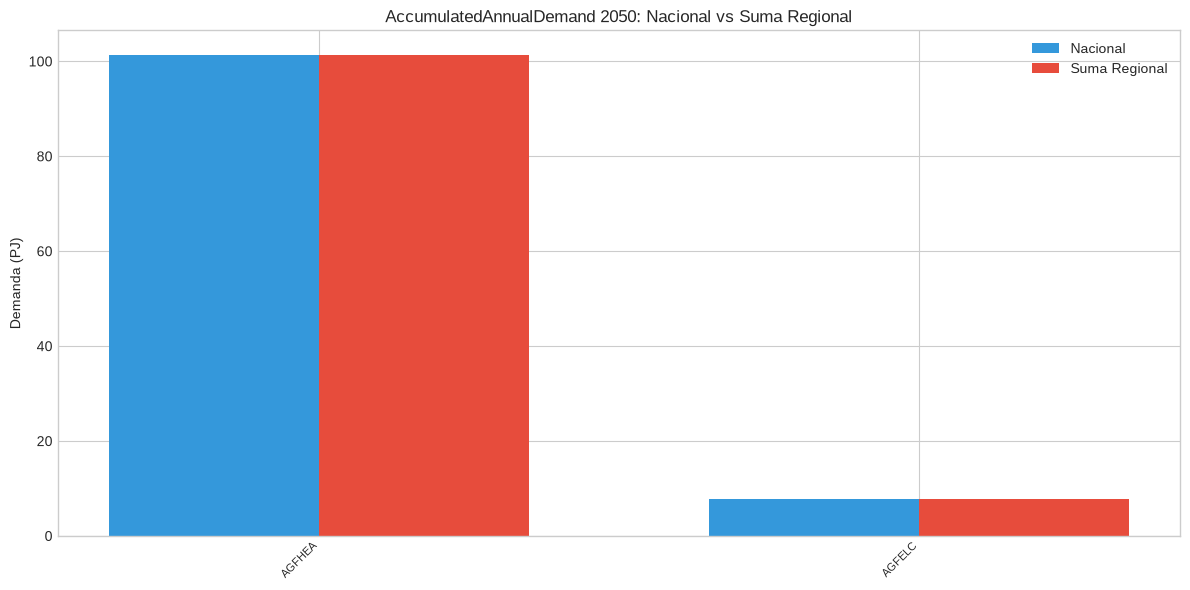

#### ResidualCapacity

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

202 coincidencias | 70 discrepancias (8 modos/variables) | 1 sin emparejar | **74.3% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
ResidualCapacity,DEMAGFDSL,DEMAGFDSL,2055,64.187646,0.000000,-64.187646,aditivo
ResidualCapacity,DEMAGFWOO,DEMAGFWOO,2055,39.864604,0.000000,-39.864604,aditivo
ResidualCapacity,DEMAGFGSL,DEMAGFGSL,2055,17.446969,0.000000,-17.446969,aditivo
ResidualCapacity,DEMAGFELC,DEMAGFELC,2055,9.309501,0.000000,-9.309501,aditivo
ResidualCapacity,DEMINDBAGFUR_MID,DEMINDBAGFUR_MID,2054,0.000000,4.252811,4.252811,aditivo
ResidualCapacity,DEMINDBAGFUR_MID,DEMINDBAGFUR_MID,2053,0.000001,4.088039,4.088038,aditivo
ResidualCapacity,DEMINDBAGFUR_MID,DEMINDBAGFUR_MID,2052,0.000005,3.927564,3.927559,aditivo
ResidualCapacity,DEMINDBAGFUR_MID,DEMINDBAGFUR_MID,2051,0.000021,3.771681,3.771660,aditivo
ResidualCapacity,DEMINDBAGFUR_MID,DEMINDBAGFUR_MID,2050,0.000069,3.619847,3.619778,aditivo
ResidualCapacity,DEMINDBAGFUR_MID,DEMINDBAGFUR_MID,2049,0.000194,3.459811,3.459617,aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMINDBAGFURCCS,Solo Nacional,TECHNOLOGY


**Comparacion 2050 (grafica):**

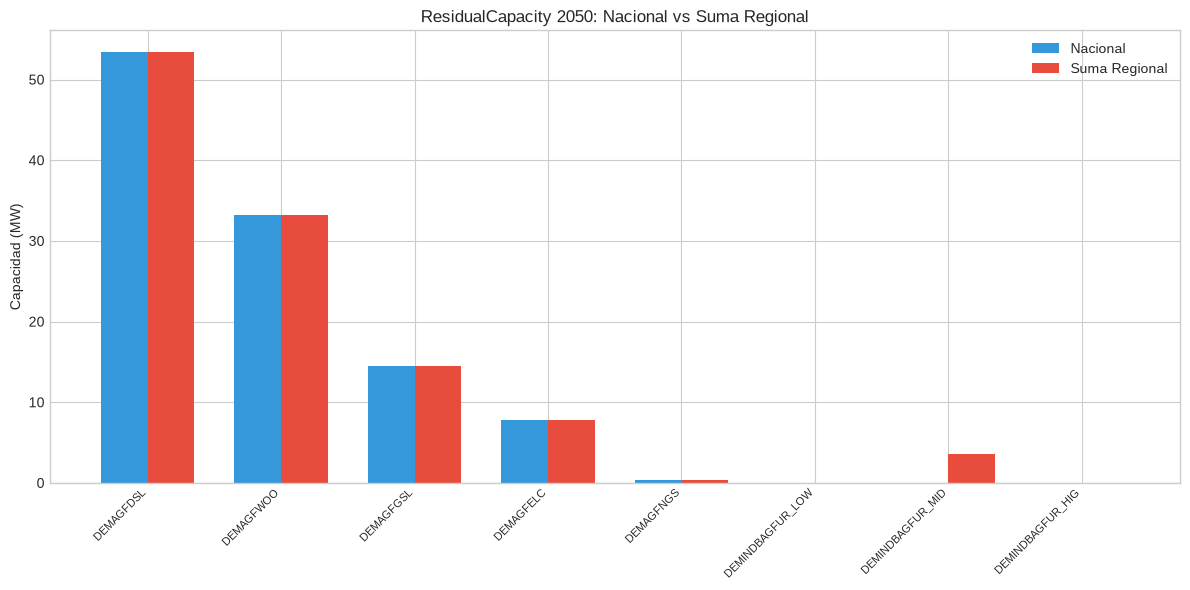

#### TotalAnnualMaxCapacityInvestment

Dimension: **TECHNOLOGY** | Tipo: **aditivo**

0 coincidencias | 0 discrepancias (0 modos/variables) | 9 sin emparejar | **0% coincidencia**

_Sin discrepancias en comparaciones emparejadas._

**Variables sin emparejar:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
CapitalCost,DEMAGFELC,DEMAGFELC,2022,9999999.000000,0.002000,-9999998.998000,no_aditivo
CapitalCost,DEMAGFELC,DEMAGFELC,2023,9999999.000000,0.002000,-9999998.998000,no_aditivo
CapitalCost,DEMAGFELC,DEMAGFELC,2024,9999999.000000,0.002000,-9999998.998000,no_aditivo
CapitalCost,DEMAGFELC,DEMAGFELC,2025,9999999.000000,0.002000,-9999998.998000,no_aditivo
CapitalCost,DEMAGFELC,DEMAGFELC,2026,9999999.000000,0.002000,-9999998.998000,no_aditivo
CapitalCost,DEMAGFELC,DEMAGFELC,2027,9999999.000000,0.002000,-9999998.998000,no_aditivo
CapitalCost,DEMAGFELC,DEMAGFELC,2028,9999999.000000,0.002000,-9999998.998000,no_aditivo
CapitalCost,DEMAGFELC,DEMAGFELC,2029,9999999.000000,0.002000,-9999998.998000,no_aditivo
CapitalCost,DEMAGFELC,DEMAGFELC,2030,9999999.000000,0.002000,-9999998.998000,no_aditivo
CapitalCost,DEMAGFELC,DEMAGFELC,2031,9999999.000000,0.002000,-9999998.998000,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
BACKSTOP_AGFELC,Solo Regional,TECHNOLOGY
BACKSTOP_AGFHEA,Solo Regional,TECHNOLOGY


**Comparacion 2050 (grafica):**

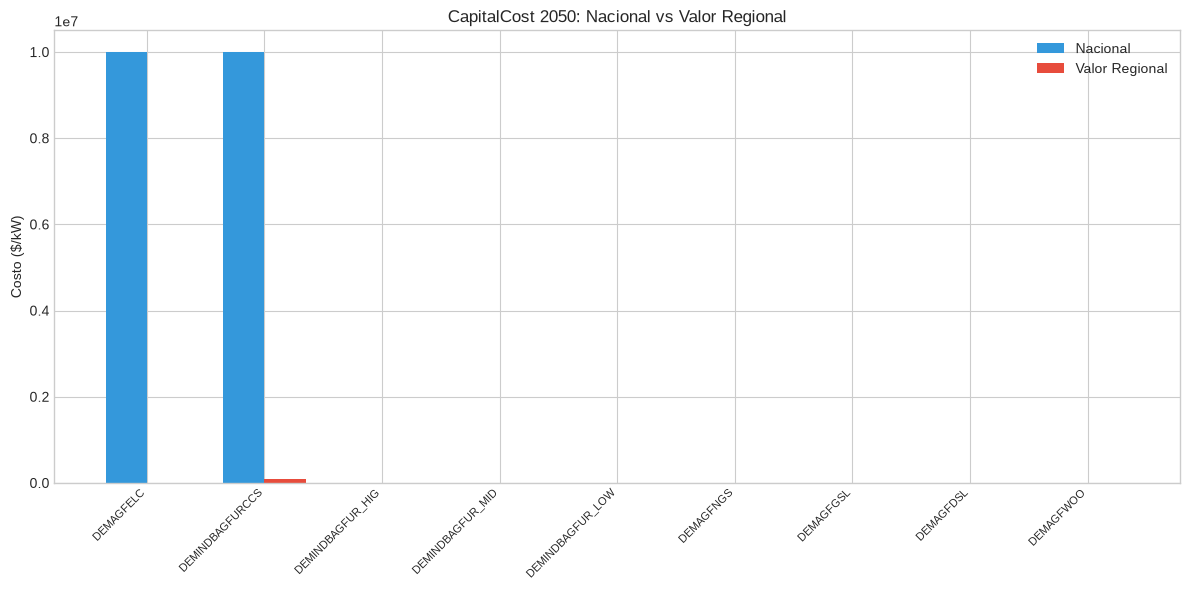

#### TotalTechnologyModelPeriodActivityUpperLimit

Dimension: **TECHNOLOGY** | Tipo: **no_aditivo**

0 coincidencias | 0 discrepancias (0 modos/variables) | 2 sin emparejar | **0% coincidencia**

_Sin discrepancias en comparaciones emparejadas._

**Variables sin emparejar:**

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2046,1.250000,1.533000,0.283000,no_aditivo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2045,1.250000,1.533000,0.283000,no_aditivo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2047,1.250000,1.533000,0.283000,no_aditivo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2054,1.250000,1.533000,0.283000,no_aditivo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2053,1.250000,1.533000,0.283000,no_aditivo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2055,1.250000,1.533000,0.283000,no_aditivo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2052,1.250000,1.533000,0.283000,no_aditivo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2051,1.250000,1.533000,0.283000,no_aditivo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2050,1.250000,1.533000,0.283000,no_aditivo
InputActivityRatio,DEMINDBAGFUR_MID|BAG|1.0,DEMINDBAGFUR_MID,2049,1.250000,1.533000,0.283000,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
DEMAGFDSL|DSL|1.0,Solo Nacional,TECH+FUEL+MODE
DEMAGFELC|ELC002|1.0,Solo Nacional,TECH+FUEL+MODE
DEMAGFGSL|GSL|1.0,Solo Nacional,TECH+FUEL+MODE
DEMAGFDSL|DSL002|1.0,Solo Regional,TECH+FUEL+MODE
DEMAGFELC|ELC003|1.0,Solo Regional,TECH+FUEL+MODE
DEMAGFGSL|GSL002|1.0,Solo Regional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

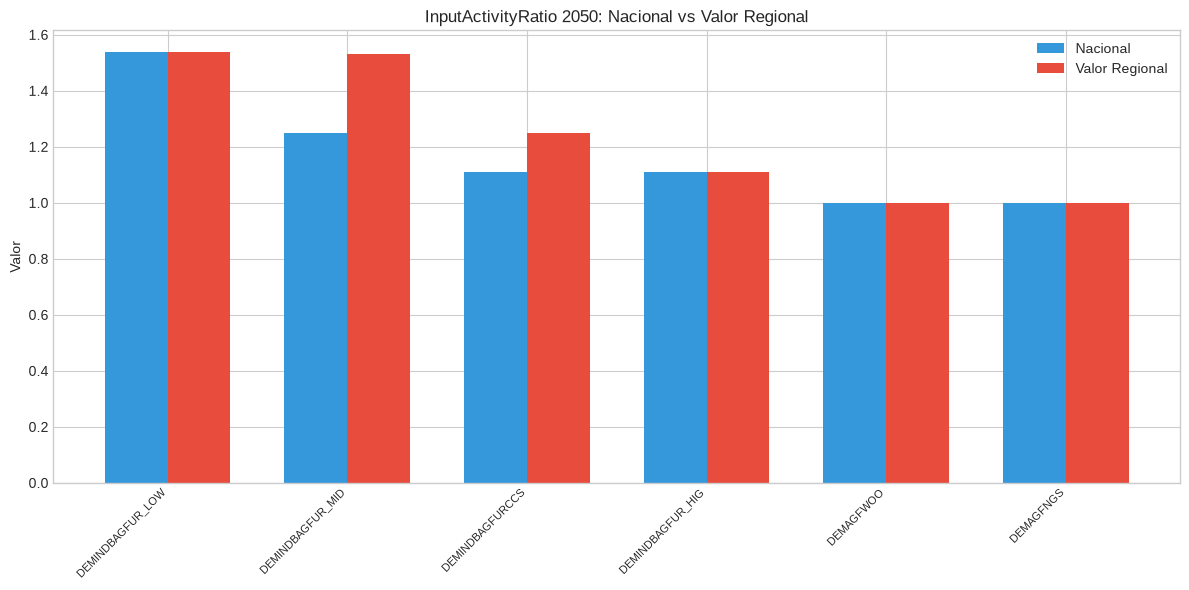

#### OutputActivityRatio

Dimension: **TECH+FUEL+MODE** | Tipo: **no_aditivo**

297 coincidencias | 9 discrepancias (9 modos/variables) | 728 sin emparejar | **97.1% coincidencia**

**Discrepancias (resumen por variable):**

Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años.

...

**Discrepancias (detalle por año):**

Parameter,Modo,Descripcion,Anio,Nacional,Valor_Regional,Diferencia,Tipo
OutputActivityRatio,DEMAGFDSL|AGFHEA|1.0,DEMAGFDSL,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMAGFELC|AGFELC|1.0,DEMAGFELC,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMAGFGSL|AGFHEA|1.0,DEMAGFGSL,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMAGFNGS|AGFHEA|1.0,DEMAGFNGS,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMAGFWOO|AGFHEA|1.0,DEMAGFWOO,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGFURCCS|INDDHT|1.0,DEMINDBAGFURCCS,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGFUR_HIG|INDDHT|1.0,DEMINDBAGFUR_HIG,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGFUR_LOW|INDDHT|1.0,DEMINDBAGFUR_LOW,2055,nan,1.000000,nan,no_aditivo
OutputActivityRatio,DEMINDBAGFUR_MID|INDDHT|1.0,DEMINDBAGFUR_MID,2055,nan,1.000000,nan,no_aditivo


**Variables sin emparejar:**

Variable,Lado,Dimension
BACKSTOP_1|AGFELC|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_1|AGFHEA|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_2|AGFELC|1.0,Solo Nacional,TECH+FUEL+MODE
BACKSTOP_2|AGFHEA|1.0,Solo Nacional,TECH+FUEL+MODE
BBGDST|AGFELC|1.0,Solo Nacional,TECH+FUEL+MODE
BBGDST|AGFHEA|1.0,Solo Nacional,TECH+FUEL+MODE
DEMAGFELC|AGFHEA|1.0,Solo Nacional,TECH+FUEL+MODE
DEMAGFELC|BAG|1.0,Solo Nacional,TECH+FUEL+MODE
DEMAGFELC|BDL|1.0,Solo Nacional,TECH+FUEL+MODE
DEMAGFELC|BET|1.0,Solo Nacional,TECH+FUEL+MODE


**Comparacion 2050 (grafica):**

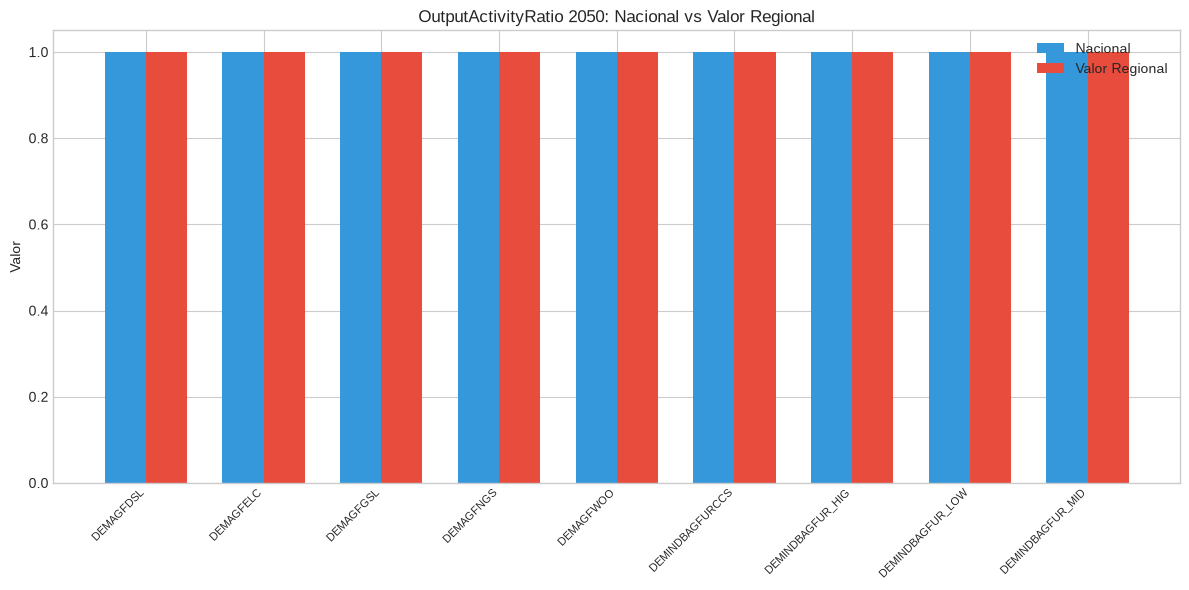

Excel validacion profunda exportado: /home/jchavez/Documentos/UPME/Datos Simulacion/output/09_validacion_profunda_AGF.xlsx


In [23]:
# --- 9. Validacion profunda: Regional vs Nacional (Agroforestal) ---
display(Markdown("### 9.1 Analisis profundo: Regional vs Nacional (Agroforestal)"))
display(Markdown(
    "Validacion de **8 parametros** del sector agroforestal con emparejamiento por dimension correcta "
    "y reporte de variables sin equivalente en el otro archivo.\n\n"
    "| Parametro | Dimension | Tipo |\n"
    "|-----------|-----------|------|\n"
    "| AccumulatedAnnualDemand | FUEL | aditivo |\n"
    "| ResidualCapacity | TECHNOLOGY | aditivo |\n"
    "| TotalAnnualMaxCapacityInvestment | TECHNOLOGY | aditivo |\n"
    "| TotalTechnologyAnnualActivityUpperLimit | TECHNOLOGY | aditivo |\n"
    "| CapitalCost | TECHNOLOGY | no aditivo |\n"
    "| TotalTechnologyModelPeriodActivityUpperLimit | TECHNOLOGY | no aditivo |\n"
    "| InputActivityRatio | TECH+FUEL+MODE | no aditivo |\n"
    "| OutputActivityRatio | TECH+FUEL+MODE | no aditivo |"
))

PARAMS_AGF = {
    "AccumulatedAnnualDemand": {"dim": "fuel", "tipo": "aditivo", "dim_label": "FUEL"},
    "ResidualCapacity": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalAnnualMaxCapacityInvestment": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyAnnualActivityUpperLimit": {"dim": "tech", "tipo": "aditivo", "dim_label": "TECHNOLOGY"},
    "CapitalCost": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "TotalTechnologyModelPeriodActivityUpperLimit": {"dim": "tech", "tipo": "no_aditivo", "dim_label": "TECHNOLOGY"},
    "InputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
    "OutputActivityRatio": {"dim": "tech_fuel_mode", "tipo": "no_aditivo", "dim_label": "TECH+FUEL+MODE"},
}


def is_agf(row):
    tech = normalize_text(row.get("TECHNOLOGY")) or ""
    fuel = normalize_text(row.get("FUEL")) or ""
    return ("AGF" in tech) or ("AGF" in fuel)

mask_nac_agf = df_nac.apply(is_agf, axis=1).astype(bool)
mask_reg_agf = df_reg.apply(is_agf, axis=1).astype(bool)
nac_agf = df_nac[mask_nac_agf].copy()
reg_agf = df_reg[mask_reg_agf].copy()
nac_fuels_agf = {normalize_text(f) for f in nac_agf["FUEL"].dropna().unique() if "AGF" in str(f)}

display(Markdown(f"- Filas Nacional (AGF*): **{len(nac_agf):,}** | Filas Regional (AGF*): **{len(reg_agf):,}**"))

anos_validar = [c for c in get_value_cols(nac_agf) if c != TIME_INDEP_COL]
disc_agf_rows = []
coinc_agf_rows = []
sin_emparejar_agf_rows = []


def _fuel_base(val):
    _, base = split_regional_name(val)
    return base


def _tech_base(val):
    _, base = split_regional_name(val)
    return base


def _mode_base(val):
    return normalize_text(val)


def _make_tfm_key(row):
    return (_tech_base(row["TECHNOLOGY"]), _fuel_base(row["FUEL"]), _mode_base(row["MODE_OF_OPERATION"]))


for param, cfg in PARAMS_AGF.items():
    dim = cfg["dim"]
    tipo = cfg["tipo"]
    nac_p = nac_agf[nac_agf["Parameter"] == param].copy()
    reg_p = reg_agf[reg_agf["Parameter"] == param].copy()

    if dim == "fuel":
        nac_vars = sorted(nac_fuels_agf)
        reg_vars = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_agf_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_agf_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for fuel in nac_vars:
            nac_rows = nac_p[nac_p["FUEL"].apply(_fuel_base) == fuel]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["FUEL"].apply(_fuel_base) == fuel]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_sum = reg_rows[anio].apply(safe_float).sum()
                diff = reg_sum - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": fuel,
                    "Descripcion": fuel,
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_sum,
                    "Diferencia": diff,
                    "Coincide": values_close(nac_val, reg_sum),
                    "Tipo": tipo,
                }
                (coinc_agf_rows if row["Coincide"] else disc_agf_rows).append(row)

    elif dim == "tech":
        nac_vars = sorted({_tech_base(t) for t in nac_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})
        reg_vars = sorted({_tech_base(t) for t in reg_p["TECHNOLOGY"].dropna().unique() if _tech_base(t)})

        for var in nac_vars:
            if var not in reg_vars:
                sin_emparejar_agf_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Nacional", "Dimension": cfg["dim_label"],
                })
        for var in reg_vars:
            if var not in nac_vars:
                sin_emparejar_agf_rows.append({
                    "Parameter": param, "Variable": var, "Lado": "Solo Regional", "Dimension": cfg["dim_label"],
                })

        for tech in nac_vars:
            nac_rows = nac_p[nac_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if nac_rows.empty:
                continue
            nac_row = nac_rows.iloc[0]
            reg_rows = reg_p[reg_p["TECHNOLOGY"].apply(_tech_base) == tech]
            if reg_rows.empty:
                continue

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                if tipo == "no_aditivo":
                    all_match = all(values_close(nac_val, v) for v in reg_vals)
                    reg_ref = reg_vals.iloc[0]
                    diff = reg_ref - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_ref,
                        "Diferencia": diff,
                        "Coincide": all_match,
                        "Tipo": tipo,
                        "Num_Regiones": len(reg_vals),
                    }
                else:
                    reg_sum = reg_vals.sum()
                    diff = reg_sum - nac_val if nac_val is not None else None
                    row = {
                        "Parameter": param,
                        "Modo": tech,
                        "Descripcion": tech,
                        "Anio": anio,
                        "Nacional": nac_val,
                        "Valor_Regional": reg_sum,
                        "Diferencia": diff,
                        "Coincide": values_close(nac_val, reg_sum),
                        "Tipo": tipo,
                    }
                (coinc_agf_rows if row["Coincide"] else disc_agf_rows).append(row)

    elif dim == "tech_fuel_mode":
        nac_keys = {_make_tfm_key(r): r for _, r in nac_p.iterrows()}
        reg_keys = {}
        for _, r in reg_p.iterrows():
            key = _make_tfm_key(r)
            reg_keys.setdefault(key, []).append(r)

        nac_key_set = set(nac_keys)
        reg_key_set = set(reg_keys)

        for key in sorted(nac_key_set - reg_key_set):
            sin_emparejar_agf_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Nacional",
                "Dimension": cfg["dim_label"],
            })
        for key in sorted(reg_key_set - nac_key_set):
            sin_emparejar_agf_rows.append({
                "Parameter": param,
                "Variable": f"{key[0]}|{key[1]}|{key[2]}",
                "Lado": "Solo Regional",
                "Dimension": cfg["dim_label"],
            })

        for key in sorted(nac_key_set & reg_key_set):
            nac_row = nac_keys[key]
            reg_rows = pd.DataFrame(reg_keys[key])
            tech, fuel, mode = key

            for anio in anos_validar:
                nac_val = safe_float(nac_row[anio])
                reg_vals = reg_rows[anio].apply(safe_float).dropna()
                if reg_vals.empty:
                    continue

                all_match = all(values_close(nac_val, v) for v in reg_vals)
                reg_ref = reg_vals.iloc[0]
                diff = reg_ref - nac_val if nac_val is not None else None
                row = {
                    "Parameter": param,
                    "Modo": f"{tech}|{fuel}|{mode}",
                    "Descripcion": tech,
                    "Anio": anio,
                    "Nacional": nac_val,
                    "Valor_Regional": reg_ref,
                    "Diferencia": diff,
                    "Coincide": all_match,
                    "Tipo": tipo,
                    "Num_Regiones": len(reg_vals),
                }
                (coinc_agf_rows if row["Coincide"] else disc_agf_rows).append(row)

# DataFrames de resultados
df_disc_agf = pd.DataFrame(disc_agf_rows)
df_coinc_agf = pd.DataFrame(coinc_agf_rows)
df_sin_emparejar_agf = pd.DataFrame(sin_emparejar_agf_rows)

if not df_disc_agf.empty:
    df_disc_agf["Abs_Diff"] = df_disc_agf["Diferencia"].abs()
    df_disc_agf["Suma_Regional"] = df_disc_agf["Valor_Regional"]


def _resumir_discrepancias(df_p_disc: pd.DataFrame, df_p_coinc: pd.DataFrame) -> pd.DataFrame:
    """Agrupa discrepancias por Parameter+Modo e indica cuantos anos fallan (o 'todos')."""
    if df_p_disc.empty:
        return pd.DataFrame()

    resumen_rows = []
    for (param, modo), group in df_p_disc.groupby(["Parameter", "Modo"], sort=True):
        disc_anios = {str(a) for a in group["Anio"].dropna().unique()}
        if not df_p_coinc.empty:
            coinc_group = df_p_coinc[
                (df_p_coinc["Parameter"] == param) & (df_p_coinc["Modo"] == modo)
            ]
            coinc_anios = {str(a) for a in coinc_group["Anio"].dropna().unique()}
            total_anios = len(disc_anios | coinc_anios)
        else:
            total_anios = len(disc_anios)

        n_disc_anios = len(disc_anios)
        anios_label = "todos" if n_disc_anios == total_anios and total_anios > 0 else str(n_disc_anios)

        resumen_rows.append({
            "Parameter": param,
            "Modo": modo,
            "Descripcion": group["Descripcion"].iloc[0],
            "Tipo": group["Tipo"].iloc[0] if "Tipo" in group.columns else "",
            "Anios_Discrepancia": anios_label,
            "Total_Anios": total_anios,
            "Max_Diferencia": group["Abs_Diff"].max(),
        })

    return pd.DataFrame(resumen_rows).sort_values("Max_Diferencia", ascending=False)


def _plot_comparacion_2050(
    df_p_disc: pd.DataFrame,
    df_p_coinc: pd.DataFrame,
    param: str,
    cfg: dict,
    max_bars: int = 15,
) -> None:
    """Grafica de barras 2050: Nacional vs Regional (suma o valor segun tipo)."""
    frames = [f for f in [df_p_disc, df_p_coinc] if not f.empty]
    if not frames:
        return

    all_data = pd.concat(frames, ignore_index=True)
    data_2050 = all_data[all_data["Anio"] == "2050"].copy()
    if data_2050.empty:
        return

    data_2050 = data_2050.drop_duplicates(subset=["Modo"], keep="first")
    n_total = len(data_2050)

    if not df_p_disc.empty:
        disc_2050 = df_p_disc[df_p_disc["Anio"] == "2050"].copy()
        if not disc_2050.empty:
            disc_2050["Abs_Diff"] = disc_2050["Diferencia"].abs()
            disc_modos = disc_2050.sort_values("Abs_Diff", ascending=False)["Modo"].tolist()
            priority = data_2050[data_2050["Modo"].isin(disc_modos)].set_index("Modo").loc[disc_modos].reset_index()
            rest = data_2050[~data_2050["Modo"].isin(disc_modos)]
            data_2050 = pd.concat([priority, rest], ignore_index=True)

    data_2050 = data_2050.sort_values("Nacional", ascending=False, na_position="last")
    data_plot = data_2050.head(max_bars)

    tipo = cfg["tipo"]
    reg_label = "Suma Regional" if tipo == "aditivo" else "Valor Regional"
    ylabels = {
        "AccumulatedAnnualDemand": "Demanda (PJ)",
        "ResidualCapacity": "Capacidad (MW)",
        "CapitalCost": "Costo ($/kW)",
    }
    ylabel = ylabels.get(param, "Valor")

    labels = []
    for _, row in data_plot.iterrows():
        modo = row["Modo"]
        if param == "AccumulatedAnnualDemand":
            labels.append(modo)
        else:
            desc = row.get("Descripcion", modo)
            text = str(desc if pd.notna(desc) else modo)
            labels.append(text if len(text) <= 28 else text[:25] + "...")

    fig_w = max(12, len(data_plot) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    x = np.arange(len(data_plot))
    w = 0.35
    ax.bar(x - w / 2, data_plot["Nacional"].fillna(0), w, label="Nacional", color="#3498db")
    ax.bar(x + w / 2, data_plot["Valor_Regional"].fillna(0), w, label=reg_label, color="#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    suffix = f" (top {len(data_plot)} de {n_total})" if n_total > max_bars else ""
    ax.set_title(f"{param} 2050: Nacional vs {reg_label}{suffix}")
    ax.legend()
    plt.tight_layout()
    plt.show()


cols_disc_resumen = ["Parameter", "Modo", "Descripcion", "Tipo", "Anios_Discrepancia", "Total_Anios", "Max_Diferencia"]
cols_disc = ["Parameter", "Modo", "Descripcion", "Anio", "Nacional", "Valor_Regional", "Diferencia", "Tipo"]

# --- Resumen global ---
n_coinc = len(coinc_agf_rows)
n_disc = len(disc_agf_rows)
n_sin = len(sin_emparejar_agf_rows)
pct_global = round(100 * n_coinc / (n_coinc + n_disc), 1) if (n_coinc + n_disc) > 0 else 100

display(Markdown(
    f"**Resultado global:** {n_coinc} coincidencias | {n_disc} discrepancias | "
    f"{n_sin} variables sin emparejar | **{pct_global}% coincidencia**"
))

resumen_param_rows = []
for param, cfg in PARAMS_AGF.items():
    n_c = sum(1 for r in coinc_agf_rows if r["Parameter"] == param)
    n_d = sum(1 for r in disc_agf_rows if r["Parameter"] == param)
    n_s = sum(1 for r in sin_emparejar_agf_rows if r["Parameter"] == param)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)
    resumen_param_rows.append({
        "Parameter": param,
        "Dimension": cfg["dim_label"],
        "Tipo_Validacion": cfg["tipo"],
        "Coincidencias": n_c,
        "Discrepancias": n_d,
        "Sin_Emparejar": n_s,
        "Pct_Coincidencia": pct_p,
    })

df_resumen_param_agf = pd.DataFrame(resumen_param_rows)
display(Markdown("**Resumen por parametro:**"))
show_df(df_resumen_param_agf)

# Resumen global de discrepancias por Parameter + Modo
if not df_disc_agf.empty:
    df_disc_resumen_global = _resumir_discrepancias(df_disc_agf, df_coinc_agf)
    display(Markdown("**Resumen global de discrepancias (por variable):**"))
    display(Markdown(
        "Cada fila indica cuantos años tienen discrepancia para ese Parameter+Modo. "
        "Si falla en todos los años comparados, muestra **todos**."
    ))
    show_df(df_disc_resumen_global[cols_disc_resumen], max_rows=100)

# --- Reporte de FUELs renombrados (InputActivityRatio / OutputActivityRatio) ---
display(Markdown("#### FUELs sin equivalencia exacta (InputActivityRatio / OutputActivityRatio)"))
display(Markdown(
    "Combustibles que existen en un archivo pero no en el otro (sin mapeo manual). "
    "Esto explica parte de las variables sin emparejar."
))

for param_report in ["InputActivityRatio", "OutputActivityRatio"]:
    nac_p = nac_agf[nac_agf["Parameter"] == param_report]
    reg_p = reg_agf[reg_agf["Parameter"] == param_report]
    nac_fuels = sorted({_fuel_base(f) for f in nac_p["FUEL"].dropna().unique() if _fuel_base(f)})
    reg_fuels = sorted({_fuel_base(f) for f in reg_p["FUEL"].dropna().unique() if _fuel_base(f)})
    solo_nac = sorted(set(nac_fuels) - set(reg_fuels))
    solo_reg = sorted(set(reg_fuels) - set(nac_fuels))
    comunes = sorted(set(nac_fuels) & set(reg_fuels))

    display(Markdown(f"**{param_report}** — {len(comunes)} FUELs en ambos | {len(solo_nac)} solo NAC | {len(solo_reg)} solo REG"))
    if solo_nac:
        display(Markdown(f"- Solo Nacional: `{', '.join(solo_nac)}`"))
    if solo_reg:
        display(Markdown(f"- Solo Regional: `{', '.join(solo_reg)}`"))

# --- Detalle por parametro ---
disc_resumen_all = []

for param, cfg in PARAMS_AGF.items():
    display(Markdown(f"#### {param}"))
    display(Markdown(f"Dimension: **{cfg['dim_label']}** | Tipo: **{cfg['tipo']}**"))

    df_p_disc = df_disc_agf[df_disc_agf["Parameter"] == param] if not df_disc_agf.empty else pd.DataFrame()
    df_p_coinc = df_coinc_agf[df_coinc_agf["Parameter"] == param] if not df_coinc_agf.empty else pd.DataFrame()
    df_p_sin = df_sin_emparejar_agf[df_sin_emparejar_agf["Parameter"] == param] if not df_sin_emparejar_agf.empty else pd.DataFrame()

    n_c = len(df_p_coinc)
    n_d = len(df_p_disc)
    n_modos_disc = df_p_disc[["Parameter", "Modo"]].drop_duplicates().shape[0] if not df_p_disc.empty else 0
    n_s = len(df_p_sin)
    total = n_c + n_d
    pct_p = round(100 * n_c / total, 1) if total > 0 else (100 if n_s == 0 else 0)

    display(Markdown(
        f"{n_c} coincidencias | {n_d} discrepancias ({n_modos_disc} modos/variables) | "
        f"{n_s} sin emparejar | **{pct_p}% coincidencia**"
    ))

    if not df_p_disc.empty:
        df_p_disc_resumen = _resumir_discrepancias(df_p_disc, df_p_coinc)
        disc_resumen_all.append(df_p_disc_resumen)
        display(Markdown("**Discrepancias (resumen por variable):**"))
        display(Markdown(
            "Columna `Anios_Discrepancia`: numero de años con diferencia, o **todos** si falla en todos los años."
        ))
        show_df(df_p_disc_resumen[cols_disc_resumen], max_rows=50)

        display(Markdown("**Discrepancias (detalle por año):**"))
        show_df(df_p_disc.sort_values("Abs_Diff", ascending=False)[cols_disc], max_rows=50)
    else:
        display(Markdown("_Sin discrepancias en comparaciones emparejadas._"))

    if not df_p_sin.empty:
        display(Markdown("**Variables sin emparejar:**"))
        show_df(df_p_sin[["Variable", "Lado", "Dimension"]], max_rows=30)

    if not df_p_coinc.empty or not df_p_disc.empty:
        max_bars = 30 if param == "AccumulatedAnnualDemand" else 15
        display(Markdown(f"**Comparacion 2050 (grafica):**"))
        _plot_comparacion_2050(df_p_disc, df_p_coinc, param, cfg, max_bars=max_bars)
    elif df_p_sin.empty:
        display(Markdown("_Sin datos emparejados para graficar._"))

df_disc_resumen_agf = (
    pd.concat(disc_resumen_all, ignore_index=True)
    if disc_resumen_all
    else pd.DataFrame()
)

# Exportar resultados de validacion profunda
output_validacion_agf = OUTPUT_DIR / "09_validacion_profunda_AGF.xlsx"
with pd.ExcelWriter(output_validacion_agf, engine="openpyxl") as writer:
    df_resumen_param_agf.to_excel(writer, sheet_name="Resumen", index=False)
    if not df_disc_resumen_agf.empty:
        df_disc_resumen_agf.to_excel(writer, sheet_name="Discrepancias_Resumen", index=False)
    if not df_disc_agf.empty:
        df_disc_agf.to_excel(writer, sheet_name="Discrepancias_Detalle", index=False)
    if not df_coinc_agf.empty:
        df_coinc_agf.to_excel(writer, sheet_name="Coincidencias", index=False)
    if not df_sin_emparejar_agf.empty:
        df_sin_emparejar_agf.to_excel(writer, sheet_name="Sin_Emparejar", index=False)
print(f"Excel validacion profunda exportado: {output_validacion_agf}")

validacion_profunda_agf = {
    "Sector": "AGF",
    "Filas_Nacional": len(nac_agf),
    "Filas_Regional": len(reg_agf),
    "Coincidencias": n_coinc,
    "Discrepancias": n_disc,
    "Sin_Emparejar": n_sin,
    "Pct_Coincidencia": pct_global,
    "Excel": "09_validacion_profunda_AGF.xlsx",
    "df_resumen_param": df_resumen_param_agf,
}


---
## 10. Conclusiones y Recomendaciones

### Hallazgos principales

1. **Parametros:** El nacional tiene 14 parametros exclusivos (restricciones agregadas, comercio, margenes de reserva). El regional tiene 1 exclusivo (`DiscountRateIdv`).

2. **Variables:** Existen diferencias significativas en nombres de TECHNOLOGY y FUEL. El regional desagrega por region con prefijos y renombra algunos combustibles.

3. **Sumas:** Los parametros aditivos como `ResidualCapacity` y `AccumulatedAnnualDemand` muestran discrepancias que requieren revision. Los no aditivos como `CapitalCost` y `AvailabilityFactor` tienen alta coincidencia.

4. **Transporte (TRA):** Ver seccion 5.3 y tabla consolidada de validacion profunda abajo.

5. **Industrial (IND):** Ver seccion 6 y tabla consolidada.

6. **Residencial (RES):** Ver seccion 7 y tabla consolidada.

7. **Terciario (TER):** Ver seccion 8 y tabla consolidada.

8. **Agroforestal (AGF):** Ver seccion 9 y tabla consolidada.

### Recomendaciones

- Revisar las hojas **Sin_Emparejo** del Excel exportado para mapear manualmente renombramientos (`ELC` -> `ELC001`, etc.)
- Validar manualmente `CapacityFactor` cuya estructura difiere entre archivos
- Para parametros con baja `% Coincidencia`, revisar si la desagregacion regional es correcta
- Revisar modos/variables con discrepancias en los Excel de validacion profunda por sector (`05` a `09_validacion_profunda_*.xlsx`)
- Considerar crear una tabla de mapeo FUEL/TECHNOLOGY nacional <-> regional para automatizar futuras validaciones


In [24]:
# Resumen ejecutivo final
total_coinc = df_resumen["Coincidencias"].sum()
total_disc = df_resumen["Discrepancias_Aditivas"].sum() + df_resumen["Discrepancias_No_Aditivas"].sum()
pct_global = round(100 * total_coinc / (total_coinc + total_disc), 2) if (total_coinc + total_disc) > 0 else 100

display(Markdown(f"""
### Resumen ejecutivo (validacion global secciones 1-4)

| Metrica | Valor |
|---------|-------|
| Parametros en comun | {len(common)} |
| Parametros solo nacional | {len(only_nac)} |
| Parametros solo regional | {len(only_reg)} |
| Claves emparejadas | {len(matched_keys)} |
| Claves sin emparejar (nacional) | {len(unmatched_nac)} |
| Claves sin emparejar (regional) | {len(unmatched_reg)} |
| Comparaciones exitosas | {total_coinc:,} |
| Discrepancias encontradas | {total_disc:,} |
| **% coincidencia global** | **{pct_global}%** |
"""))

# --- Tabla consolidada validacion profunda por sector (secciones 5-9) ---
sectores_validacion = []
for key in ["tra", "ind", "res", "ter", "agf"]:
    var = f"validacion_profunda_{key}"
    if var in globals():
        v = globals()[var]
        sectores_validacion.append({
            "Sector": v["Sector"],
            "Filas_Nacional": v["Filas_Nacional"],
            "Filas_Regional": v["Filas_Regional"],
            "Coincidencias": v["Coincidencias"],
            "Discrepancias": v["Discrepancias"],
            "Sin_Emparejar": v["Sin_Emparejar"],
            "Pct_Coincidencia": v["Pct_Coincidencia"],
            "Excel": v["Excel"],
        })

if sectores_validacion:
    df_validacion_sectores = pd.DataFrame(sectores_validacion)
    display(Markdown("### Validacion profunda por sector (8 parametros)"))
    show_df(df_validacion_sectores)

    display(Markdown("**Parametros con mas discrepancias por sector:**"))
    for key in ["tra", "ind", "res", "ter", "agf"]:
        var = f"validacion_profunda_{key}"
        if var not in globals():
            continue
        df_p = globals()[var]["df_resumen_param"]
        if df_p.empty:
            continue
        top = df_p.sort_values("Discrepancias", ascending=False).head(3)
        lines = ", ".join(
            f"{r.Parameter} ({int(r.Discrepancias)} disc.)" for _, r in top.iterrows() if r.Discrepancias > 0
        )
        sector = globals()[var]["Sector"]
        if lines:
            display(Markdown(f"- **{sector}:** {lines}"))
        else:
            display(Markdown(f"- **{sector}:** sin discrepancias en comparaciones emparejadas"))

display(Markdown("""
**Archivos Excel exportados en `output/`:**
- 01_comparacion_parametros.xlsx
- 02_comparacion_variables.xlsx
- 03_validacion_sumas.xlsx
- 04_analisis_transporte.xlsx
- 05_validacion_profunda_transporte.xlsx
- 06_validacion_profunda_IND.xlsx
- 07_validacion_profunda_RES.xlsx
- 08_validacion_profunda_TER.xlsx
- 09_validacion_profunda_AGF.xlsx
"""))


NameError: name 'matched_keys' is not defined